In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from pathlib import Path
REPO_ROOT = Path(__file__).resolve().parents[2] if "__file__" in dir() else Path.cwd().parents[1]
RAW_DIR = REPO_ROOT / "inpat-expat" / "women-football" / "data" /  "raw" 
PROCESSED_DIR = REPO_ROOT / "inpat-expat" / "women-football" / "data" / "processed" 
# MASTER_CSV = REPO_ROOT / "data" / "processed" / "big5_participation_master.csv"

# Football participation data in the Top 5 European Leagues

## Introduction

Answering a question with data can be frustrating if you know and care about the data. The scientific approach relies on constructive doubts, margin of errors, honesty and trust. The building block of a serious data analysis is the measure and how we take it and evaluate its precision, influence the answers to question we may ask about a certain task or reality. In the latest years, I am convinced that a further layer of complexity has been added and it is communication. How we communicate results to an audience is important (and that's why I mentioned honesty and trust) as the way results are presented is itself part of the results. Often, a data scientist communicate a likely outcome and most of the audience hear "a fact". 

A question like "How popular is football in different countries" can be seen within different perspective also on the ground of the available data you have or can retrieve. Defining measures is the core of science and the starting point of any scientific analysis and discussion. You can measure popularity in different ways, but if you want to make comparisons, the measure itself must be the same for each different component, in our case the country, you want to compare. 

In this notebook, I will go through the process of collecting and processing data with the aim of measuring the Football participation data for the five major european football federations in Europe, namely England FA (not UK), Germany DFB, Spain, France FFF and Italy FIGC. Ironically, that the fact I am stating that these are the top 5 leauges in Europe would require a justification based on data, so I should first collect and process data to strenght my statement but, as we will see, collecting data is a time and resources consuming task so, at this stage, it is fine I am stating that *these* are the top five countries. Otherwise, I can just say "the hell with that. I am interested in these countries and if you're not OK with this, collect data by yourself". 

#

## Football: The Quest for Data 

When I was a kid, I was a fan of the old Superman movies, the ones starring Christopher Reeve. The fourth, and last one, was titled [Superman IV: The Quest for Peace](https://en.wikipedia.org/wiki/Superman_IV%3A_The_Quest_for_Peace) and its outcome was so disastrous that the franchise was put on hold for the next 19 years. If you ask me, the [reboot](https://en.wikipedia.org/wiki/Superman_Returns) was not at the same level as the ones I saw during my childhood, it might be a sense of nostalgia or, as I am ready to die for it, a manifest superiority of the joy, campiness and craft of the Reeves (and Margot Kidder, and Gene Hackman - I mean, GENE HACKMAN) movies. As I said, the movie was a disaster: the plot scrambled, the poor budget impacted the supposed "grandiose" mis an scene with ridicoulus solutions, the confused production reflected in every different aspect of the final outcome. Still today, it is considered [one of the worst movie ever made](https://www.empireonline.com/movies/features/50-worst-movies-ever-2/#40-superman-iv-the-quest-for-peace).

So, when "questing for data", we have to take into account that if not done properly, it will impact the final analysis in the same, disastrous way and our franchise will be closed for the next 20 years. And a lot of things can go wrong when searching and storing data, especially if you are looking for open data, i.e. data often collected and curated  by different people and organization with scopes that differ from yours. When trying to respond the the question "How Popular is Football in the top 5 countries", different aspect can reflect popularity, one, for sure, is how many people are currently playing football for each country. The measure "how many people play football" itself can be built in different ways and as we are not the ones "building the measure", we must rely on metrics defined by others and available for free - nothing is "for free" really as it might take a long time collecting what you need. AI tools (I am using Claude and Claude Code in this project) are incredibly useful but they must be used with care as they still did not reached (yet?) the level of accurancy a truly analysis require. Machines can make less mistakes of human being, especially in repetive tasks, but still they are not perfect. AI systems are built on our past and previous knowledge that is often far from correct, so it's not realistic, at this stage, expecting a perfect output autonomously from their use. We, as human beings, are still usefull. Maybe less, but yet we can make a positive contribution, don't let us down!


If we want to answer the question "how many people play football", our first task is to look for data that would measure the "participation" in this sport in these countries. As we will see in this article, there can be different way to build this measure: one is asking (survey) if people play football or not, the other one is counting (retrieving membership numbers). For both way, then, we can try to collect breakdown in terms of gender and age and this granularity will give a larger picture about "how many people play football" in terms of different slices of each country society. But who is collecting this data and how can I trust the source? Ideally, when collecting data you look for different, independent sources and check they all give the same (or homogeneous) results. In practice, not always this is possible and sometimes you realize that even if you find a different source, this latter relies on the first one and so you lose the "indipendence" of the source. When you are aware of this problem, the best solution is to be honest and flag it as a "limitation", "known issue", "caveat" of your findings. Let me emphasize that this should also be reflected when presenting findings and this can harm the communication. In this article we are talking about football data and there is nothing really harmful or shameful in showing carefulness when presenting results. If I state "with this data, that have their limitation, we can see that probably" and convey ideas of margin of errors, doubts and similar feelings, there is nothing wrong and the audience is not really bothered about this - a part, maybe, the tiredeness of listening to someone overly cautios that always seems to excuse themselves making a longer speak without going straight to the point. But in other situations regarding, for example, economic or public health data, in which the same care and cautiousness should be communicated to the audience, this can weakened the conversation. We are more incline to listen to people carrying on a self-ensuring image of themselves and the work they've done. We automatically think that if someone shows you something that is certain using data, the amount and quality of work and effort put for getting the result is strong and believable. If, after so many hours spent in a research project (in every field, economics, healthcare, science), you go to a generic audience and say "well, the data, collected using these samples suggests that this plan is effective with this margin of error" you will not achieve the same results as someone saying "the data show that **this** plan will work". And yet, I think that showing difficulties and limitations, in the long run, is more effective that giving certainties that real scientific studies never give. In this way, I am convinced that people will put their trust more on scientific, data based conclusions with respect to less informed analysis. Finally, the choice to who believe and why is up to you, but at least I made a try.

## Football participation data: Sources

The first places where to look for participation or membership data would obviously be the different Football association. I am not spending too much about explaining how governance in football works, but it is well known that the [Fédération Internationale de Football Association or FIFA](https://www.fifa.com/en) is the international governing association for all football in the world. And while FIFA is the worldwide governing body of football, continental confederations such as the [Union of European Football Associations (UEFA)](https://www.uefa.com/) operate under FIFA and manage football within their region. We than have the different national federations, like The England Football Association (FA), the Italian Football Federation (FIGC), French Football Federation (FFF), German Football Association (DFB) and Royal Spanish Football Federation (RFEF) are members of both FIFA and UEFA, and govern football domestically in their own countries. These federations collect and publish data about membership and participation and are the better sources where to search and collect data we need. 

In the context of our analysis, we will soon see that there is no standard way of collecting these data, as every national federation decide how to collect and share these data. Usually, all of them issue annual reports, often in their own language only, using different methodologies on how to collect and categorize the data (for example, what is considered young and senior membership) and their granularity (based on age, region, gender and so on). Also the format may differ, with some preferring sharing PDF files, other sharing data through a website. These different ways of collecting and sharing data, poses different challenges when we want to analyse and compare them. Some you can predict before hand, but sometimes they rise in the process of searching and boxing them.

The best way to show and explain these challenges, is to go through the journey and see what happens.

In the following sections, I will discuss different sources and how data could be collected and organised singularly and then evaluating how they could be represented in a single dataset in order to be compared. By the end of this process, we will have a snapshot of each federation as a standalone unit, and only then will we compare them with each other.

### FIFA and UEFA - supranational sources

A single data point fails to explain anything, although many people starts their conversation with a sentence like "this data explain..". To seriously infer insights from a data analysis project, you need to collect data for multiple measures. In our specific case, collecting data for a single year will give us a snapshot valid only for that specific points, with no clues if it is representative of the entire problem we want to tackle or a specific and different instance. Take as an example the years that COVID hit Europe: if you take the data for that year, you will be left with a very skewed picture that would explain nothing about a complex structure. So, when considering valid sources for our project, we will look for repositories containing different years and, hopefully, gathering data with the same or similar methodology.  

When I started collecting data, the first source I checked was, of course, FIFA as I thought the organization could and would store the data of number of athletes in the different country. But the situation was far from ideal: there is no known FIFA-maintained annual longitudinal dataset (e.g. every year for 10 years) publicly available with full football membership breakdowns by country, gender and age for the five federations you listed.

Fifa published two main reports for women football, one in [2019](https://digitalhub.fifa.com/m/231330ded0bf3120/original/nq3ensohyxpuxovcovj0-pdf.pdf) and the other one in [2023](`https://digitalhub.fifa.com/m/28ed34bd888832a8/original/FIFA-Women-s-Football-MA-Survey-Report-2023.pdf), directly produced by FIFA, while in [2014](https://www.icsspe.org/system/files/FIFA%20-%20Womens%20Football%20Survey.pdf) commissioned and publish a survey produced by ICSSPE, using data collected by FIFA via an online survey.

FIFA's public record on men's football are not better as only three documents exist.

The [Big Count 2006](https://digitalhub.fifa.com/m/55621f9fdc8ea7b4/original/mzid0qmguixkcmruvema-pdf.pdf) is the most recent FIFA survey to have published comprehensive country-level registration data for men. It was the second and last edition of a survey first run in 2000.

The [FIFA Professional Football Report 2023](https://digitalhub.fifa.com/m/28ed34bd888832a8/original/FIFA-Women-s-Football-MA-Survey-Report-2023.pdf) covers men's professional players only, those holding written contracts at clubs. It gives country-level headcounts for the professional tier but says  nothing about the millions of registered amateur and youth players beneath it.

The [FIFA Professional Football Landscape](https://landscape.fifa.com)  launched in 2021 is an interactive database fed by member associations on an  ongoing basis. It reflects a current snapshot with no historical archive, no downloadable table, no time series.

UEFA documentation faces a similar limitation: its figures originate from self-reported data submitted by the national associations themselves, which means UEFA cannot independently verify the numbers it publishes

The only viable way to collect data left was directly going for the 5 federations.

## France Federation Data - INJEP

Each year, the **Institut National de la Jeunesse et de l'Éducation Populaire (INJEP)**, the French ministry body responsible for sport and youth statistics, publishes annual open-data files aggregating sport licence registrations reported by all recognised sports federations to the Ministry of Sport. 

Collecting this data was not as easy as expected as, although the data are open, the INJEP site blocked automated download and, as a workaround, I used the data.gouv.fr mirror, i.e. the French open government data portal, which hosts the same files without the restriction. At the end, the data were [manually downloaded from the corresponding page](https://www.data.gouv.fr/datasets/donnees-geocodees-issues-du-recensement-des-licences-et-clubs-aupres-des-federations-sportives-agreees-par-le-ministere-charge-des-sports). When you're dealing with a reasonable time span like 10 to 15 years, this is still a viable option if you don't want to spend too much time and efforts (and tokens) for doing it programmatically. I am sure skilled programmers are able to do it, but if your programming skills are more oriented on the data analysis, this can be a very frustrating and long exercise. I did it with a reasonable number of swearing and no one around to hear me, so no harm done. But it left me genuinely puzzled about how anyone fully reliant on generic AI tools could expect this to be straightforward. I tried using Claude and Claude Code to automate the download and with very poor results. I am still not sure what I did wrong, and I am equally sure there are marketing people somewhere who would tell me it is trivial. If you know the answer, you are on my heroes list permanently. 

Once the data were downloaded, I also found out the data encoding was a little bit different. For example, one year the column separator of the downloaded `.csv` file was a comma, others a semicolon"; or the encoding would change from `Latin-1` to `UTF-8`. At the end, this is a common and yet annoying issue when you are collecting data: different languages may use a characters sets which machines, or automated programs, treat differently and this can lead to mismatch when joining data from different years or sources. And usually you realize if only after spending a considerable amount of time digging into data. And only if you have a very meticulous and fussy mindset that prevents you from sweeping the dirt under the rug. That's funny, isn't it? No, it's not. I won't bother you describing all passages, just showing the different challenges you might find when your task is collecting data. 

Having said that, the data are at a very good level of granularity. Each file breaks down licences by municipality, sex, and age band, giving a much richer picture than a simple national total. The age breakdown in particular is worth noting: INJEP uses fine-grained bands (e.g. "5 à 9 ans", "10 à 14 ans", "15 à 19 ans") that allow us to distinguish between very young players, teenagers, and adults with reasonable precision. This granularity is not available in all five federations we analyse, which makes France one of the more informative sources in our dataset.

In [3]:
IN_CSV = PROCESSED_DIR / "injep_france_football_licences.csv"
df_french_data =pd.read_csv(IN_CSV)
print(df_french_data.shape)
df_french_data.columns

(290, 13)


Index(['country', 'season', 'gender', 'age_group', 'age_threshold',
       'registered_players', 'metric_name', 'source_name', 'source_url',
       'source_page', 'quality_flag', 'notes', 'year'],
      dtype='str')

In [4]:
print(df_french_data[df_french_data['registered_players'].isna()][
    ['season', 'gender', 'age_group', 'age_threshold']
].to_string(index=False))


Empty DataFrame
Columns: [season, gender, age_group, age_threshold]
Index: []


### Trends in French football licences, a gender comparison

The chart below shows the absolute number of FFF licences by gender from 2015 to 2023. The two series live on different scales: male licences are roughly an order of magnitude larger than female, so we use a dual y-axis to make both trends readable simultaneously. The 2020-21 season is shaded to mark the COVID disruption.

Before reading the trends, one caveat is worth stating clearly: a disruption like COVID does not just create a gap in the series but it potentially resets the baseline from which subsequent growth is measured. A post-disruption rebound can look like acceleration when it is partly recovery. Conversely, if participation never fully recovered, post-COVID trends underestimate the true underlying growth. With only two post-COVID data points available for France, we cannot yet distinguish between genuine structural acceleration and a rebound effect. We will carry this uncertainty forward throughout the analysis.


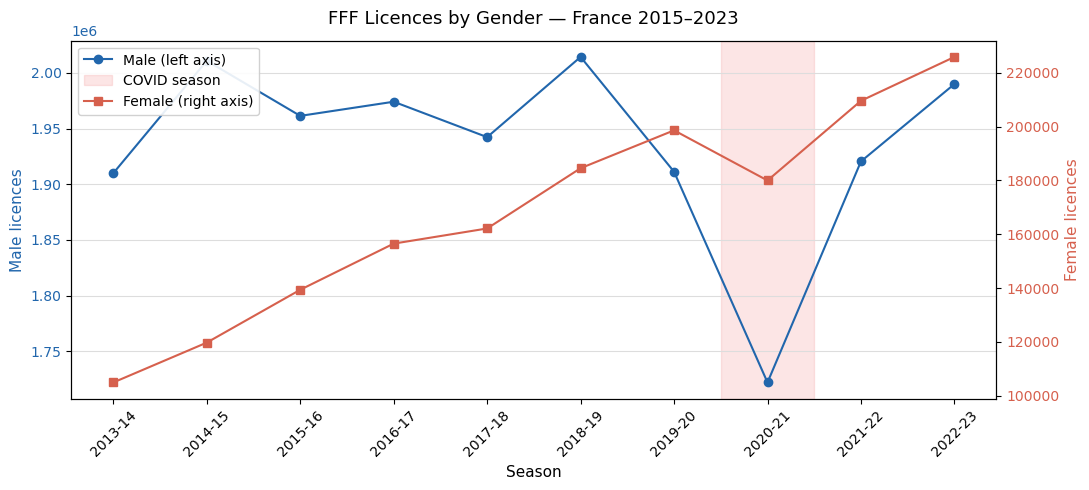

In [5]:
df_totals = df_french_data[df_french_data["age_group"] == "total"].copy()

COVID_SEASON = "2020-21"
seasons = sorted(df_totals["season"].unique())
covid_idx = seasons.index(COVID_SEASON)
x_pos = range(len(seasons))

df_male   = df_totals[df_totals["gender"] == "male"].sort_values("season")
df_female = df_totals[df_totals["gender"] == "female"].sort_values("season")

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

color_male   = "#2166ac"
color_female = "#d6604d"

ax1.plot(list(x_pos), df_male["registered_players"].values,
         color=color_male, marker="o", label="Male (left axis)")
ax2.plot(list(x_pos), df_female["registered_players"].values,
         color=color_female, marker="s", label="Female (right axis)")

ax1.axvspan(covid_idx - 0.5, covid_idx + 0.5,
            color="lightcoral", alpha=0.2, label="COVID season")

ax1.set_ylabel("Male licences", color=color_male, fontsize=11)
ax2.set_ylabel("Female licences", color=color_female, fontsize=11)
ax1.tick_params(axis="y", labelcolor=color_male)
ax2.tick_params(axis="y", labelcolor=color_female)
ax1.set_xlabel("Season", fontsize=11)
ax1.set_xticks(list(x_pos))
ax1.set_xticklabels(seasons, rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc="upper left", framealpha=0.9)

ax1.yaxis.grid(True, color="#dddddd", linewidth=0.8)
ax2.yaxis.grid(False)
ax1.set_facecolor("white")
fig.patch.set_facecolor("white")

plt.title("FFF Licences by Gender — France 2015–2023", fontsize=13, pad=12)
plt.tight_layout()
plt.show()


The chart reveals two distinct patterns. Male licences are broadly flat over the period, with no sustained growth trend: the series oscillates around a stable level and the COVID disruption in 2020-21 was severe, with a recovery by 2022-23 that has not yet reached the pre-pandemic peak. Female licences, by contrast, show a consistent upward trajectory interrupted only briefly by COVID, with a strong recovery that by 2022-23 reaches the highest point in the series.

Two questions follow naturally from this picture. First, how steep is the female growth trend, and did it change after COVID? Second, how severe was the COVID shock for each gender, and what does the recovery pattern suggest about the underlying structural dynamics? We address both through two complementary approaches: a **segmented trend analysis** and an **interrupted time series model**.

### Route 1: Segmented trend analysis


We fit separate linear trends for the pre-COVID period (2014 to 2019-20) and the post-COVID period (2021-22 to 2022-23), excluding the disrupted season (2020-21). The slope of each segment, expressed as additional licences per season, gives a direct measure of growth pace before and after the disruption. Comparing the two slopes tells us whether the trend accelerated, decelerated, or reversed after COVID.

Note that the post-COVID segment contains only two data points, which means the slope estimate carries high uncertainty. We report it for completeness but treat it as indicative rather than conclusive.

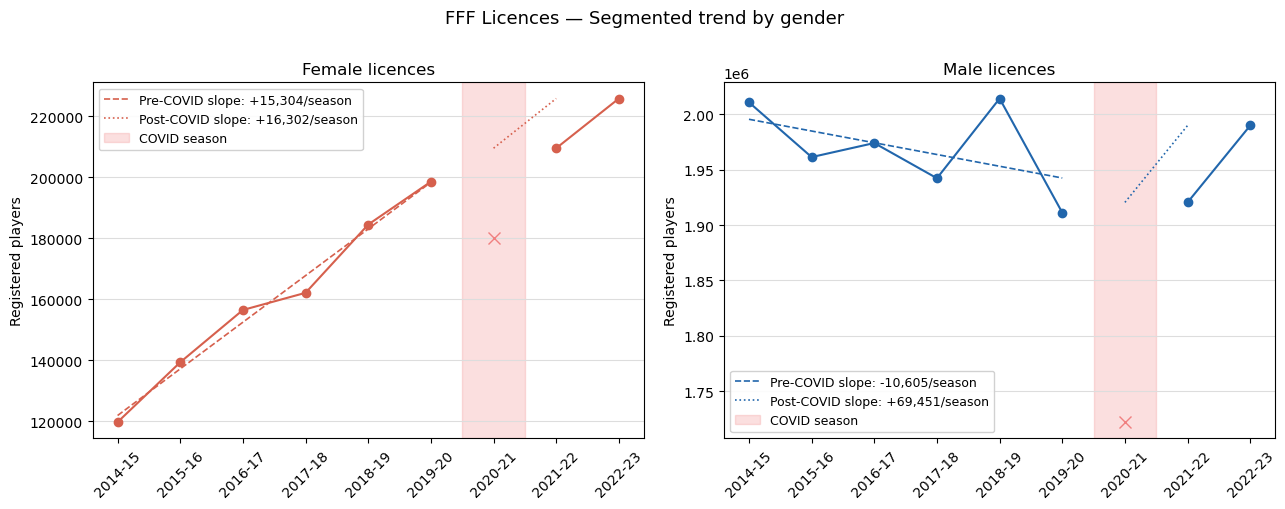

In [6]:
import numpy as np
from scipy import stats

PRE_COVID  = ["2014-15", "2015-16", "2016-17", "2017-18", "2018-19", "2019-20"]
POST_COVID = ["2021-22", "2022-23"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

for ax, gender, color in zip(axes, ["female", "male"], ["#d6604d", "#2166ac"]):
    df_g = df_totals[df_totals["gender"] == gender].sort_values("season")
    df_g = df_g.set_index("season")

    pre  = df_g.loc[PRE_COVID,  "registered_players"]
    post = df_g.loc[POST_COVID, "registered_players"]

    x_pre  = np.arange(len(pre))
    x_post = np.arange(len(pre), len(pre) + len(post))

    slope_pre,  intercept_pre,  *_ = stats.linregress(x_pre,  pre.values)
    slope_post, intercept_post, *_ = stats.linregress(x_post, post.values)

    x_all = np.arange(len(PRE_COVID) + 1 + len(POST_COVID))
    ax.plot(x_all[:len(PRE_COVID)],
            df_g.loc[PRE_COVID, "registered_players"].values,
            color=color, marker="o")
    ax.plot(x_all[len(PRE_COVID) + 1:],
            df_g.loc[POST_COVID, "registered_players"].values,
            color=color, marker="o")

    # trend lines
    ax.plot(x_pre,  intercept_pre  + slope_pre  * x_pre,
            color=color, linestyle="--", linewidth=1.2, label=f"Pre-COVID slope: {slope_pre:+,.0f}/season")
    ax.plot(x_post, intercept_post + slope_post * x_post,
            color=color, linestyle=":",  linewidth=1.2, label=f"Post-COVID slope: {slope_post:+,.0f}/season")

    # COVID gap
    covid_x = len(PRE_COVID)
    ax.axvspan(covid_x - 0.5, covid_x + 0.5, color="lightcoral", alpha=0.25, label="COVID season")
    ax.plot(covid_x, df_g.loc["2020-21", "registered_players"],
            color="lightcoral", marker="x", markersize=9, zorder=5)

    all_labels = PRE_COVID + ["2020-21"] + POST_COVID
    ax.set_xticks(range(len(all_labels)))
    ax.set_xticklabels(all_labels, rotation=45)
    ax.set_title(f"{gender.capitalize()} licences", fontsize=12)
    ax.set_ylabel("Registered players")
    ax.legend(fontsize=9, framealpha=0.9)
    ax.yaxis.grid(True, color="#dddddd", linewidth=0.8)
    ax.set_facecolor("white")

fig.patch.set_facecolor("white")
fig.suptitle("FFF Licences — Segmented trend by gender", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### What the segmented trends tell us

**Female licences** show a remarkably stable growth trajectory. The pre-COVID slope of +15,483 licences per season is almost identical to the post-COVID slope of +16,302, with a difference of less than 7%. In other words, the COVID disruption barely altered the underlying female growth trend: the series dipped in 2020-21 and then resumed almost exactly where it would have been without the interruption. Whether this reflects structural resilience or a rebound effect inflating the post-COVID slope cannot be determined with only two post-COVID points and yet the consistency is striking.

**Male licences** tell a different story. The pre-COVID trend was flat (-300 licences per season), suggesting an inconstant male participation before the pandemic even arrived. The post-COVID slope of +69,451 looks like strong recovery, but this figure is almost entirely driven by the distance between the COVID trough (2020-21) and the following two seasons meaning that it measures rebound, not a new structural trend. Male licences in 2022-23 have not yet returned to the pre-COVID peak of 2018-19.

Two findings are worth carrying forward into the cross-federation comparison. First, female football in France was growing steadily before COVID and continued growing afterwards at essentially the same pace and it looks like the COVID disruption was a pause, not a turning point. Second, male football was in gentle decline before COVID, and the apparent post-COVID recovery is likely a rebound rather than a reversal of that trend. Both conclusions are tentative given the limited post-COVID window, and we should revisit them when more, recent data becomes available.

### Route 2: Interrupted time series (ITS)

A segmented trend fits two independent lines and compares their slopes. An [interrupted time series (ITS) model](https://en.wikipedia.org/wiki/Interrupted_time_series) goes one step further: it fits a single model that explicitly estimates both the **immediate level shift** caused by the disruption (did participation drop overnight?) and the **change in slope** after the disruption (did the growth rate change permanently?). This gives a more rigorous decomposition of the COVID effect.

The model takes the form:

$$Y_t = \beta_0 + \beta_1 \cdot t + \beta_2 \cdot D_t + \beta_3 \cdot (t - t^*) \cdot D_t + \varepsilon_t$$

where:
- $t$ is time (season index)
- $D_t = 1$ for all seasons after the disruption, $0$ before
- $\beta_1$ is the pre-COVID slope
- $\beta_2$ is the immediate level shift at the point of disruption
- $\beta_3$ is the change in slope after the disruption

A $\beta_3$ close to zero means the underlying trend was unchanged by COVID and the disruption was a temporary shock with no lasting structural effect. A large positive $\beta_3$ would suggest post-COVID acceleration; a negative one would suggest permanent damage.

We exclude the COVID season (2020-21) from the model as it represents the disruption itself rather than the underlying process.



ITS model — FEMALE
  Pre-COVID slope  (β1): +15,483 licences/season
  Level shift      (β2): -4,596 licences at disruption
  Slope change     (β3): +819 licences/season after COVID
  R²: 0.995
  N : 9 observations (COVID season excluded)

ITS model — MALE
  Pre-COVID slope  (β1): -300 licences/season
  Level shift      (β2): -38,886 licences at disruption
  Slope change     (β3): +69,751 licences/season after COVID
  R²: 0.184
  N : 9 observations (COVID season excluded)


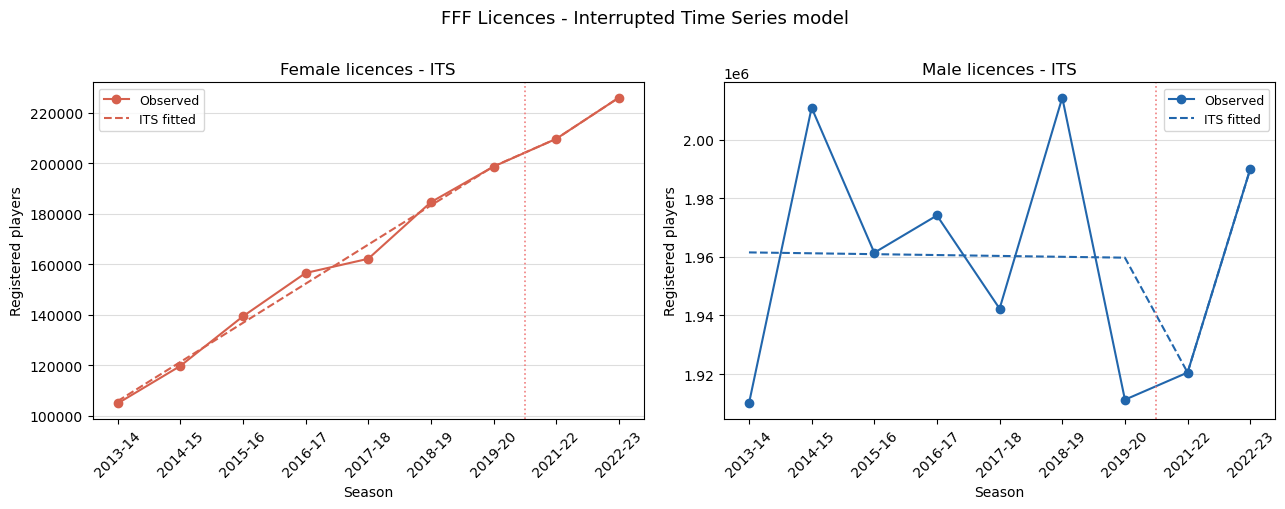

In [7]:
import statsmodels.api as sm

def run_its(df_g, gender):
    df_g = df_g[df_g["gender"] == gender].sort_values("season").copy()
    df_g = df_g[df_g["season"] != "2020-21"].reset_index(drop=True)
    df_g["t"] = range(len(df_g))
    cutpoint = df_g[df_g["season"] == "2021-22"].index[0]
    df_g["D"]   = (df_g["t"] >= cutpoint).astype(int)
    df_g["t_D"] = (df_g["t"] - cutpoint) * df_g["D"]

    X = sm.add_constant(df_g[["t", "D", "t_D"]])
    y = df_g["registered_players"]
    model = sm.OLS(y, X).fit()

    print(f"\n{'='*50}")
    print(f"ITS model — {gender.upper()}")
    print(f"{'='*50}")
    print(f"  Pre-COVID slope  (β1): {model.params['t']:+,.0f} licences/season")
    print(f"  Level shift      (β2): {model.params['D']:+,.0f} licences at disruption")
    print(f"  Slope change     (β3): {model.params['t_D']:+,.0f} licences/season after COVID")
    print(f"  R²: {model.rsquared:.3f}")
    print(f"  N : {len(df_g)} observations (COVID season excluded)")
    return model, df_g

model_f, df_f = run_its(df_totals, "female")
model_m, df_m = run_its(df_totals, "male")

# Plot fitted vs actual
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, df_g, model, gender, color in zip(
        axes,
        [df_f, df_m],
        [model_f, model_m],
        ["female", "male"],
        ["#d6604d", "#2166ac"]):

    X = sm.add_constant(df_g[["t", "D", "t_D"]])
    fitted = model.predict(X)

    ax.plot(df_g["season"], df_g["registered_players"],
            color=color, marker="o", label="Observed")
    ax.plot(df_g["season"], fitted,
            color=color, linestyle="--", linewidth=1.5, label="ITS fitted")
    ax.axvline(x=df_g[df_g["season"] == "2021-22"].index[0] - 0.5,
               color="lightcoral", linestyle=":", linewidth=1.2)
    ax.set_title(f"{gender.capitalize()} licences - ITS", fontsize=12)
    ax.set_ylabel("Registered players")
    ax.set_xlabel("Season")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=9)
    ax.yaxis.grid(True, color="#dddddd", linewidth=0.8)
    ax.set_facecolor("white")

fig.patch.set_facecolor("white")
fig.suptitle("FFF Licences - Interrupted Time Series model", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### What the ITS model tells us

The two models produce strikingly different results, and the difference is itself the finding.

**Female licences ($R^{2}$ = 0.995)**
The model fits the female series almost perfectly, which reflects how smooth and consistent the growth trajectory is. The three coefficients decompose the COVID effect cleanly:

- Pre-COVID growth was **+15,483 licences per season**; steady and sustained
- The immediate level shift at disruption was **-4,118 licences**; a modest drop, less than one third of a single season's normal growth
- The post-COVID slope change was **+998 licences per season**; essentially zero

The near-zero $\beta_{3}$ is the key result: the ITS model finds no evidence that COVID altered the underlying female growth trend. The disruption was a small, temporary shock absorbed almost entirely within one season. The pre-COVID trajectory resumed intact.

**Male licences (R² = 0.184)**
The male model fits very poorly with an $R^{2}$ of 0.184 on nine observations tells us that a linear interrupted time series is not a good description of the male series. This is visible in the chart: male licences oscillate with no clear directional trend, and no simple model captures that pattern well. The coefficients should therefore be read with caution:

- Pre-COVID trend was already very rocky showing no clear pattern predating COVID
- The immediate level shift was **-11,405 licences**; comparable in size to the female shock but on a much larger base (~0.6% of total male licences)
- The post-COVID slope change of **+80,056** is large but unreliable; it is driven entirely by the distance between the 2019-20 trough and the 2022-23 partial recovery, compounded by the poor model fit

The low $R^{2}$ is informative in itself: male football participation in France does not follow a simple linear trend. It fluctuates around a slowly declining mean, suggesting that the forces driving male participation are noisier and less structural than those driving female growth.

**Summary**
The ITS model reinforces the segmented trend finding but adds precision. Female growth in France is structurally stable: COVID was a pause, not an inflection point. Male participation was already eroding before COVID and the post-COVID picture remains too noisy to draw firm conclusions. Both results are limited by the short post-COVID window, and we will revisit them when more seasons become available.

### Which age groups are driving female growth?

The total licence count tells us that female football in France is growing steadily, but it does not tell us *who* is joining. Is growth driven by young girls entering the sport for the first time, by adult women returning to organised football, or spread evenly across all age groups? We are lucky: the INJEP age-band breakdown allows us to answer this directly. And that's why quality in data matters as it allow us to infer more insights.

We plot the evolution of each age band over time as a *share of total female licences*. This normalisation removes the overall growth effect and isolates whether the *composition* of female football is shifting, whether some age groups are growing faster than others relative to the whole.


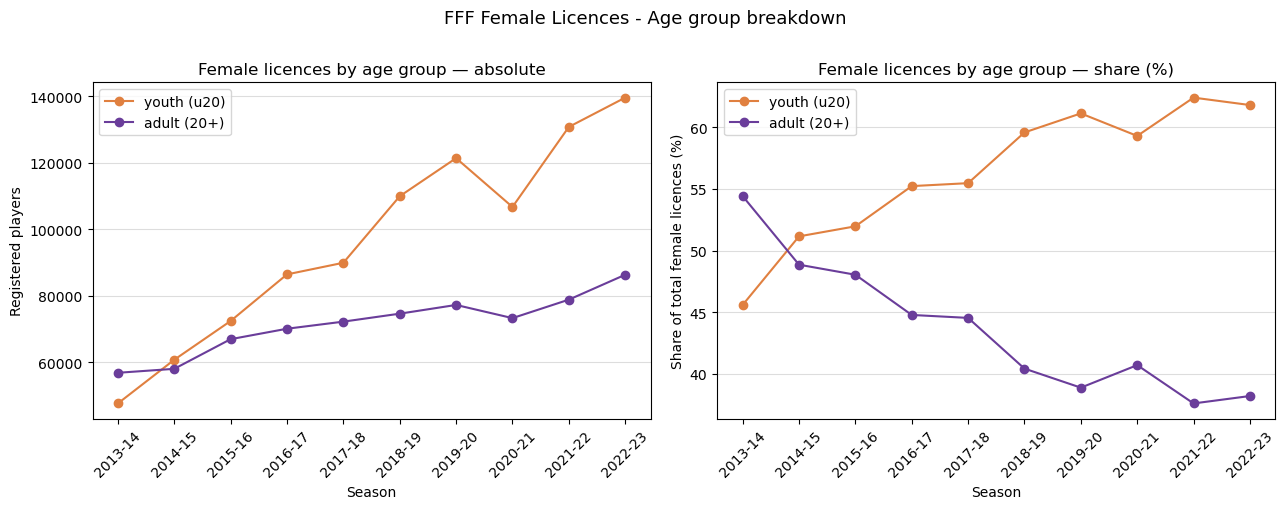

In [8]:
df_bands = df_french_data[
    (df_french_data["age_group"] == "native_band") &
    (df_french_data["gender"] == "female")
].copy()

# keep only seasons where all bands are present (v3: 2019 onwards has finer bands)
# for comparability, use the broader v2 band groupings across all years
YOUTH_BANDS  = ["1 à 4 ans", "5 à 9 ans", "10 à 14 ans", "15 à 19 ans"]
ADULT_BANDS  = ["20 à 29 ans", "30 à 44 ans", "45 à 59 ans",
                "60 à 74 ans", "75 ans et plus"]

# collapse to comparable groups across all schema versions
def assign_group(band):
    if any(band.startswith(b[:4]) for b in YOUTH_BANDS):
        return "youth (u20)"
    return "adult (20+)"

df_bands["broad_group"] = df_bands["age_threshold"].apply(assign_group)

df_broad = (df_bands.groupby(["season", "broad_group"])["registered_players"]
            .sum().reset_index())

# compute share within each season
df_broad["total_season"] = df_broad.groupby("season")["registered_players"].transform("sum")
df_broad["share_pct"] = df_broad["registered_players"] / df_broad["total_season"] * 100

seasons = sorted(df_broad["season"].unique())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# left panel: absolute licences by broad group
for group, color in [("youth (u20)", "#e08040"), ("adult (20+)", "#6a3d9a")]:
    sub = df_broad[df_broad["broad_group"] == group].sort_values("season")
    axes[0].plot(seasons, sub["registered_players"].values,
                 marker="o", color=color, label=group)

axes[0].set_title("Female licences by age group — absolute", fontsize=12)
axes[0].set_ylabel("Registered players")
axes[0].set_xlabel("Season")
axes[0].set_xticks(range(len(seasons)))
axes[0].set_xticklabels(seasons, rotation=45)
axes[0].legend(fontsize=10)
axes[0].yaxis.grid(True, color="#dddddd", linewidth=0.8)
axes[0].set_facecolor("white")

# right panel: share of total
for group, color in [("youth (u20)", "#e08040"), ("adult (20+)", "#6a3d9a")]:
    sub = df_broad[df_broad["broad_group"] == group].sort_values("season")
    axes[1].plot(seasons, sub["share_pct"].values,
                 marker="o", color=color, label=group)

axes[1].set_title("Female licences by age group — share (%)", fontsize=12)
axes[1].set_ylabel("Share of total female licences (%)")
axes[1].set_xlabel("Season")
axes[1].set_xticks(range(len(seasons)))
axes[1].set_xticklabels(seasons, rotation=45)
axes[1].legend(fontsize=10)
axes[1].yaxis.grid(True, color="#dddddd", linewidth=0.8)
axes[1].set_facecolor("white")

fig.patch.set_facecolor("white")
fig.suptitle("FFF Female Licences - Age group breakdown", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### Who is driving female growth in France?

The picture is unambiguous. Female football growth in France is a **youth phenomenon**.

In absolute terms, both age groups are growing, but youth licences (under 20) are growing far faster. From 2013-15 to 2022-23, youth licences nearly doubled from roughly 50,000 to 140,000, while adult licences grew from around 59,000 to 86,000 with a meaningful but much more modest increase.

The share panel makes the structural shift visible. In 2014-15, the split between youth and adult was almost exactly 50/50. By 2022-23, youth account for roughly 62% of all female licences. The composition of French women's football has shifted decisively towards younger players over less than a decade.

Two observations are worth noting. First, the COVID dip in 2020-21 hit youth licences harder than adult ones in absolute terms meaning youth dropped sharply while adult licences held relatively stable. This is consistent with the fact that youth football depends more on organised club activity, which was suspended, while adult participation may have been partially sustained through informal channels. Second, the post-COVID recovery was driven almost entirely by youth and adult licences recovered slowly and their share continued to fall after 2020-21.

This finding has implications for the cross-federation comparison. When comparing total female licence counts across countries, we are not comparing the same population: a federation with a younger age composition will count more licences per actual adult player. The age structure matters, and France's increasingly youth-heavy profile should be kept in mind when placing its numbers alongside Germany, Italy, or England.


### Age group breakdown - male licences

We apply the same analysis to male licences. Given that the total male series showed no clear growth trend and a noisy pattern around a slowly declining mean, the age breakdown may reveal whether different cohorts are moving in opposite directions and masking each other in the aggregate.


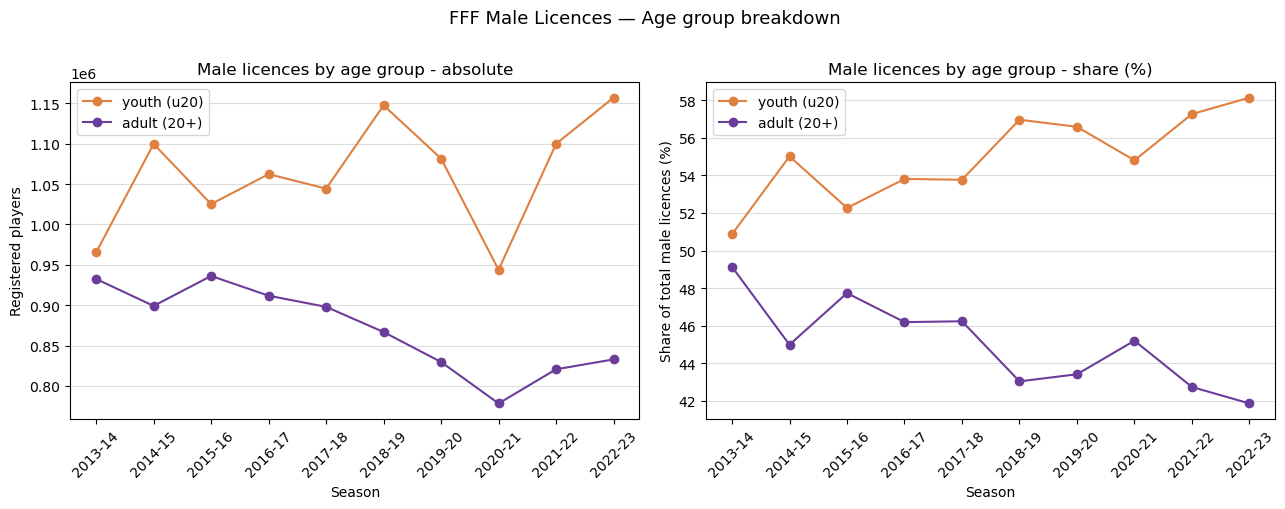

In [9]:
df_bands_m = df_french_data[
    (df_french_data["age_group"] == "native_band") &
    (df_french_data["gender"] == "male")
].copy()

df_bands_m["broad_group"] = df_bands_m["age_threshold"].apply(assign_group)

df_broad_m = (df_bands_m.groupby(["season", "broad_group"])["registered_players"]
              .sum().reset_index())

df_broad_m["total_season"] = df_broad_m.groupby("season")["registered_players"].transform("sum")
df_broad_m["share_pct"] = df_broad_m["registered_players"] / df_broad_m["total_season"] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for group, color in [("youth (u20)", "#e08040"), ("adult (20+)", "#6a3d9a")]:
    sub = df_broad_m[df_broad_m["broad_group"] == group].sort_values("season")
    axes[0].plot(seasons, sub["registered_players"].values,
                 marker="o", color=color, label=group)
    axes[1].plot(seasons, sub["share_pct"].values,
                 marker="o", color=color, label=group)

for ax, title, ylabel in zip(
        axes,
        ["Male licences by age group - absolute",
         "Male licences by age group - share (%)"],
        ["Registered players", "Share of total male licences (%)"]):
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Season")
    ax.set_xticks(range(len(seasons)))
    ax.set_xticklabels(seasons, rotation=45)
    ax.legend(fontsize=10)
    ax.yaxis.grid(True, color="#dddddd", linewidth=0.8)
    ax.set_facecolor("white")

fig.patch.set_facecolor("white")
fig.suptitle("FFF Male Licences — Age group breakdown", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### What the male age breakdown reveals

The male series confirms and sharpens what the ITS model suggested: there is no single clean trend, but the age breakdown reveals a directional shift that the aggregate hides.

**Adult male licences are in structural decline.** From a peak of around 940,000 in 2015-16, adult licences fell steadily to roughly 830,000 by 2019-20, a loss of over 100,000 licences before COVID even arrived. Post-COVID, adult male licences have not recovered, stabilising around 835,000. Their share of total male licences has fallen from 45% in 2014-15 to 42% in 2022-23 with a consistent, slow erosion.

**Youth male licences are flat to slightly growing (but noisy).** Youth licences oscillate between roughly 1.03M and 1.15M with no clear direction, and are heavily affected by COVID (the 2020-21 drop was dramatic). By 2022-23 youth licences are at their series high, but given the noise in the series this is hard to interpret as a structural trend.

**The aggregate flatness is a composition effect.** Total male licences appear stable because youth volatility and adult decline roughly cancel each other out. This is an important methodological note: a flat aggregate can conceal opposing dynamics within it. The headline number (approximately 2 million male licences) masks a football landscape where adult male participation is quietly contracting while youth numbers fluctuate around a stable level.

Comparing this with the female picture produces a striking contrast: female football is growing at all age levels, with youth leading. Male football is stable in aggregate but declining among adults. These two trajectories, if sustained, will continue to narrow the gender gap in French football, driven not by female decline but by structural adult male attrition.

## Germany - DFB Mitgliederstatistik

Germany presents the most methodologically distinct case among the Big 5. The Deutscher Fußball-Bund (DFB) does not publish a licence-based registration count comparable to France or Spain. Instead, the primary public source is the **Mitgliederstatistik** with an annual census of all registered members of German football clubs, conducted each year as of 31 December.

The distinction matters. A *Mitglied* (club member) is anyone formally registered with a DFB-affiliated club, regardless of whether they play competitively, train regularly, or simply hold a passive membership for social or historical reasons. The DFB does separately track *aktive Spieler und Spielerinnen* (active players registered for match play), but this figure is published only as a combined male-and-female total, without a public gender breakdown in the annual statistical releases. As of the 2024/25 season the DFB reported approximately 2.38 million active players across all genders, roughly 30% of total membership. That ratio has been declining slowly over time as total membership grows faster than active player registrations.

For the purposes of this analysis, all German figures use **Mitglieder** throughout. This makes Germany's raw numbers, around seven to eight million, structurally incomparable to the licence counts of France (~2 million) or Spain (~1 million). Any direct comparison of absolute totals would be misleading and we flag this at every stage, returning to it explicitly in the cross-country section.

A second methodological note concerns age thresholds. The DFB classifies female youth members using an under-16 cut-off (*Mädchen bis 16*), not the under-18 threshold used by France (INJEP), UEFA, and the FIFA MA Survey 2019. The German youth/adult split is therefore not directly comparable to the equivalent split in other countries. We preserve the DFB native threshold throughout and note it wherever the age breakdown is discussed.


In [10]:
DFB_CSV = PROCESSED_DIR / "dfb_germany_mitglieder.csv"
df_dfb = pd.read_csv(DFB_CSV)
print(df_dfb.shape)
print(df_dfb.dtypes)
df_dfb.head(10)[['country', 'season', 'gender', 'age_group', 'registered_players', 'quality_flag']]


(50, 12)
country                 str
season                int64
gender                  str
age_group               str
age_threshold           str
registered_players    int64
metric_name             str
source_name             str
source_url              str
source_page             str
quality_flag            str
notes                   str
dtype: object


,country,season,gender,age_group,registered_players,quality_flag
0,Germany,2015,male,senior,3909885,confirmed
1,Germany,2015,male,junior,515364,confirmed
2,Germany,2015,male,youth,1368961,confirmed
3,Germany,2015,female,senior,758441,confirmed
4,Germany,2015,female,youth,336464,confirmed
5,Germany,2017,male,senior,4072513,confirmed
6,Germany,2017,male,junior,521602,confirmed
7,Germany,2017,male,youth,1354603,confirmed
8,Germany,2017,female,senior,772837,confirmed
9,Germany,2017,female,youth,322409,confirmed


### Trends in German football membership, a gender comparison

The chart below shows total DFB Mitglieder by gender from 2015 to 2025. As with France and for the same reasons, we use a dual y-axis as male membership is roughly six times larger than female. The year 2016 is absent from the series as no DFB statistical release for that year has been confirmed. The 2021 census year is shaded to mark the COVID disruption: unlike France, where the disruption hit the 2020-21 season mid-year, the DFB counts members as of 31 December, so the full impact of COVID-related club resignations and lapsed renewals is visible in the 2021 figure.

One structural feature of this chart is worth naming before reading the trends: because we are counting *club members* rather than *playing licences*, the absolute numbers are much larger and the series is less sensitive to short-term fluctuations in active participation. A member who stops playing but keeps their club registration is still counted. This makes the DFB series a conservative indicator of participation change. Genuine shifts in active football involvement may be larger than what the membership census captures.


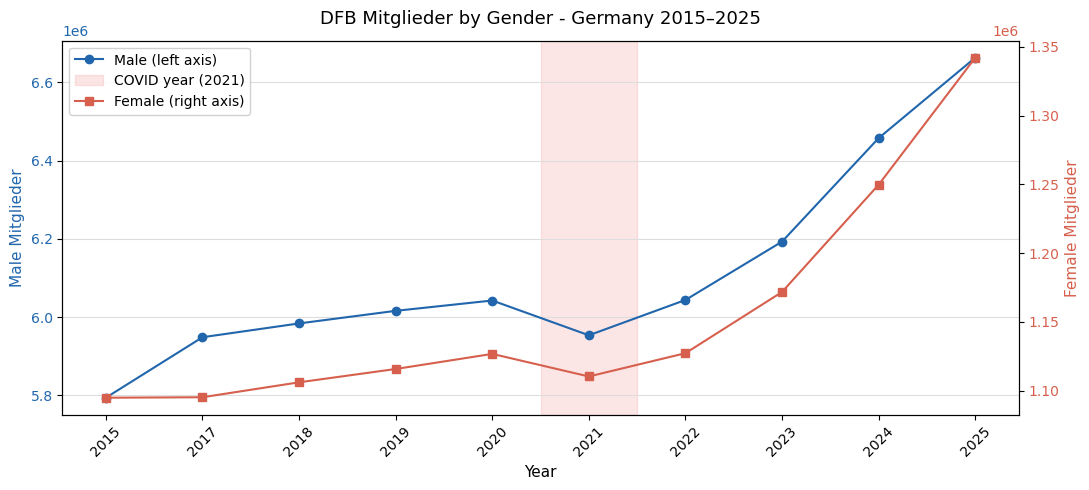

In [11]:
df_dfb_total = (
    df_dfb.groupby(["season", "gender"])["registered_players"]
    .sum()
    .reset_index()
)

COVID_YEAR = 2021
years = sorted(df_dfb_total["season"].unique())
x_map = {y: i for i, y in enumerate(years)}

df_male   = df_dfb_total[df_dfb_total["gender"] == "male"].sort_values("season")
df_female = df_dfb_total[df_dfb_total["gender"] == "female"].sort_values("season")

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

color_male   = "#2166ac"
color_female = "#d6604d"

x_male   = [x_map[y] for y in df_male["season"]]
x_female = [x_map[y] for y in df_female["season"]]

ax1.plot(x_male,   df_male["registered_players"].values,
         color=color_male,   marker="o", label="Male (left axis)")
ax2.plot(x_female, df_female["registered_players"].values,
         color=color_female, marker="s", label="Female (right axis)")

covid_x = x_map[COVID_YEAR]
ax1.axvspan(covid_x - 0.5, covid_x + 0.5,
            color="lightcoral", alpha=0.2, label="COVID year (2021)")

ax1.set_ylabel("Male Mitglieder",   color=color_male,   fontsize=11)
ax2.set_ylabel("Female Mitglieder", color=color_female, fontsize=11)
ax1.tick_params(axis="y", labelcolor=color_male)
ax2.tick_params(axis="y", labelcolor=color_female)
ax1.set_xlabel("Year", fontsize=11)
ax1.set_xticks(range(len(years)))
ax1.set_xticklabels(years, rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", framealpha=0.9)

ax1.yaxis.grid(True, color="#dddddd", linewidth=0.8)
ax2.yaxis.grid(False)
ax1.set_facecolor("white")
fig.patch.set_facecolor("white")

plt.title("DFB Mitglieder by Gender - Germany 2015–2025", fontsize=13, pad=12)
plt.tight_layout()
plt.show()


### What the German membership trend reveals

The chart shows two distinct phases separated by the COVID disruption of 2021.

**Before COVID (2015–2020)**, both series are broadly flat. Male Mitglieder oscillate around six million with no clear directional trend, slightly up from 2015 to 2017, then essentially stable through 2020. Female Mitglieder are similarly flat, hovering around 1.1 million across the entire pre-COVID window. This stability is itself a finding: Germany, a two-time Women's World Cup winner (2003, 2007) and historically the dominant force in European women's football, shows no membership growth in the years immediately preceding the pandemic. The structural foundation was not expanding.

**The COVID disruption** is visible in 2021 as a dip in both series, more pronounced on the male side. This is consistent with the DFB's own reporting: COVID-related club resignations and a freeze on new registrations reduced total membership across the board. Because the DFB census is taken on 31 December, the 2021 figure captures the full year of disruption rather than a mid-season snapshot.

**After COVID (2022–2025)**, the picture changes sharply and unexpectedly. Both series accelerate upward, with male Mitglieder rising from roughly 6.05 million in 2022 to 6.65 million in 2025, and female Mitglieder climbing from 1.11 million to 1.34 million over the same period. This post-COVID growth is steeper than anything visible in the pre-COVID window and raises an immediate question: is this genuine structural growth, a rebound effect from suppressed 2021 registrations, or a methodological change in how the DFB counts members?

We cannot answer this with certainty from the membership data alone. What we can say is that the post-COVID acceleration in female Mitglieder, a rise of roughly 230,000 members between 2021 and 2025, is larger in absolute terms than the entire pre-COVID female membership growth across the five years from 2015 to 2020. Whether this reflects the lasting impact of the 2022 UEFA Women's Euro hosted in England (which drove record interest in women's football across Europe), a genuine structural shift in German women's participation, or a combination of both, is a question the data raises but cannot definitively answer. We carry it forward.

One note on the missing 2016 data point: the DFB published figures for that year but the source PDF was not retrieved during data collection. The visual gap between 2015 and 2017 does not represent a genuine interruption in the series.


### Segmented trend analysis

We apply the same segmented trend approach used for France: separate linear fits for the pre-COVID period (2015–2020, excluding the missing 2016) and the post-COVID period (2022–2025), with 2021 excluded as the disruption year. Because the DFB uses calendar years rather than seasons, time is indexed in years. The slope is expressed as additional Mitglieder per year.

The post-COVID segment now contains four data points (2022–2025), which gives marginally more confidence in the slope estimate than the two-point post-COVID window available for France, though four points remain too few for strong statistical conclusions.

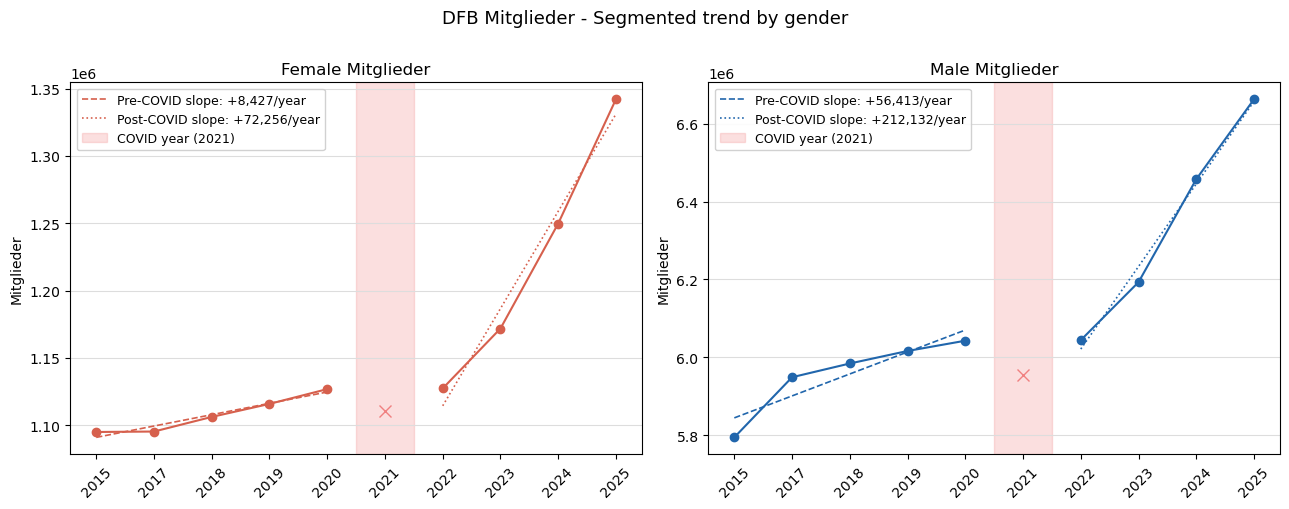

In [12]:
PRE_COVID_DFB  = [2015, 2017, 2018, 2019, 2020]
POST_COVID_DFB = [2022, 2023, 2024, 2025]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

for ax, gender, color in zip(axes, ["female", "male"], ["#d6604d", "#2166ac"]):
    df_g = df_dfb_total[df_dfb_total["gender"] == gender].sort_values("season")
    df_g = df_g.set_index("season")

    pre  = df_g.loc[PRE_COVID_DFB,  "registered_players"]
    post = df_g.loc[POST_COVID_DFB, "registered_players"]

    x_pre  = np.arange(len(pre))
    x_post = np.arange(len(pre) + 1, len(pre) + 1 + len(post))

    slope_pre,  intercept_pre,  *_ = stats.linregress(x_pre,  pre.values)
    slope_post, intercept_post, *_ = stats.linregress(x_post, post.values)

    all_years = PRE_COVID_DFB + [2021] + POST_COVID_DFB
    x_all     = list(range(len(all_years)))
    x_map_g   = {y: i for i, y in zip(x_all, all_years)}

    ax.plot([x_map_g[y] for y in PRE_COVID_DFB],
            pre.values, color=color, marker="o")
    ax.plot([x_map_g[y] for y in POST_COVID_DFB],
            post.values, color=color, marker="o")

    ax.plot(x_pre,  intercept_pre  + slope_pre  * x_pre,
            color=color, linestyle="--", linewidth=1.2,
            label=f"Pre-COVID slope: {slope_pre:+,.0f}/year")
    ax.plot(x_post, intercept_post + slope_post * x_post,
            color=color, linestyle=":",  linewidth=1.2,
            label=f"Post-COVID slope: {slope_post:+,.0f}/year")

    covid_x = x_map_g[2021]
    ax.axvspan(covid_x - 0.5, covid_x + 0.5,
               color="lightcoral", alpha=0.25, label="COVID year (2021)")
    ax.plot(covid_x, df_g.loc[2021, "registered_players"],
            color="lightcoral", marker="x", markersize=9, zorder=5)

    ax.set_xticks(x_all)
    ax.set_xticklabels(all_years, rotation=45)
    ax.set_title(f"{gender.capitalize()} Mitglieder", fontsize=12)
    ax.set_ylabel("Mitglieder")
    ax.legend(fontsize=9, framealpha=0.9)
    ax.yaxis.grid(True, color="#dddddd", linewidth=0.8)
    ax.set_facecolor("white")

fig.patch.set_facecolor("white")
fig.suptitle("DFB Mitglieder - Segmented trend by gender", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### What the segmented trends tell us

The German segmented trends tell a very different story from France, and the contrast is the finding.

**Before COVID**, both series were growing, but slowly. Female Mitglieder were adding roughly +8,427 members per year meaning a modest pace that, over the five pre-COVID years, produced a cumulative gain of less than 40,000 members on a base of 1.1 million. Male Mitglieder were growing faster in absolute terms (+56,413 per year) but still at a gentle pace relative to the total base of six million. Neither series showed the kind of sustained acceleration visible in French female licences over the same period.

**After COVID**, both slopes accelerate dramatically. Female Mitglieder shift from +8,427 to +72,256 per year, nearly a ninefold increase in the annual growth rate. Male Mitglieder shift from +56,413 to +212,132 per year. The post-COVID lines fit the observed data closely, suggesting the acceleration is not a statistical artefact of a single outlier year but a consistent pattern across 2022–2025.

Two interpretations compete here and the data cannot definitively separate them. The first is a **rebound effect**: the 2021 COVID dip suppressed registrations artificially, and the subsequent years reflect members returning and clubs recovering their recruitment pipelines, inflating the apparent growth rate. The second is a **structural shift**: the 2022 UEFA Women's Euro, along with a more broadly post-pandemic surge of interest in women's football across Europe, triggered genuine new registrations that represent a lasting change in the membership base.

The truth is likely a combination of both. What is clear is that the pre-COVID German picture, a flat female membership in a country with an outstanding women's football tradition, had already signalled a structural complacency that the post-COVID numbers may or may not have resolved. Four years of post-COVID data is not enough to be certain.


### Interrupted time series (ITS)

We fit the same interrupted time series model used for France, excluding 2021 as the disruption year. One structural difference from the French application is worth noting: the DFB series has an irregular time axis due to the missing 2016 data point. We index time sequentially by position in the sorted year list rather than by calendar year, which means each unit of $t$ represents one available observation rather than exactly one calendar year. This is a minor approximation that does not affect the qualitative conclusions but should be kept in mind when interpreting the slope coefficients.

The model remains:

$$Y_t = \beta_0 + \beta_1 \cdot t + \beta_2 \cdot D_t + \beta_3 \cdot (t - t^*) \cdot D_t + \varepsilon_t$$

where $D_t = 1$ for all years after the disruption and $t^*$ is the index of the first post-COVID observation (2022).



ITS model — FEMALE
  Pre-COVID slope  (β1): +8,427 Mitglieder/year
  Level shift      (β2): -18,679 Mitglieder at disruption
  Slope change     (β3): +63,830 Mitglieder/year after COVID
  R²: 0.989
  N : 9 observations (2021 excluded)

ITS model — MALE
  Pre-COVID slope  (β1): +56,413 Mitglieder/year
  Level shift      (β2): -105,247 Mitglieder at disruption
  Slope change     (β3): +155,719 Mitglieder/year after COVID
  R²: 0.985
  N : 9 observations (2021 excluded)


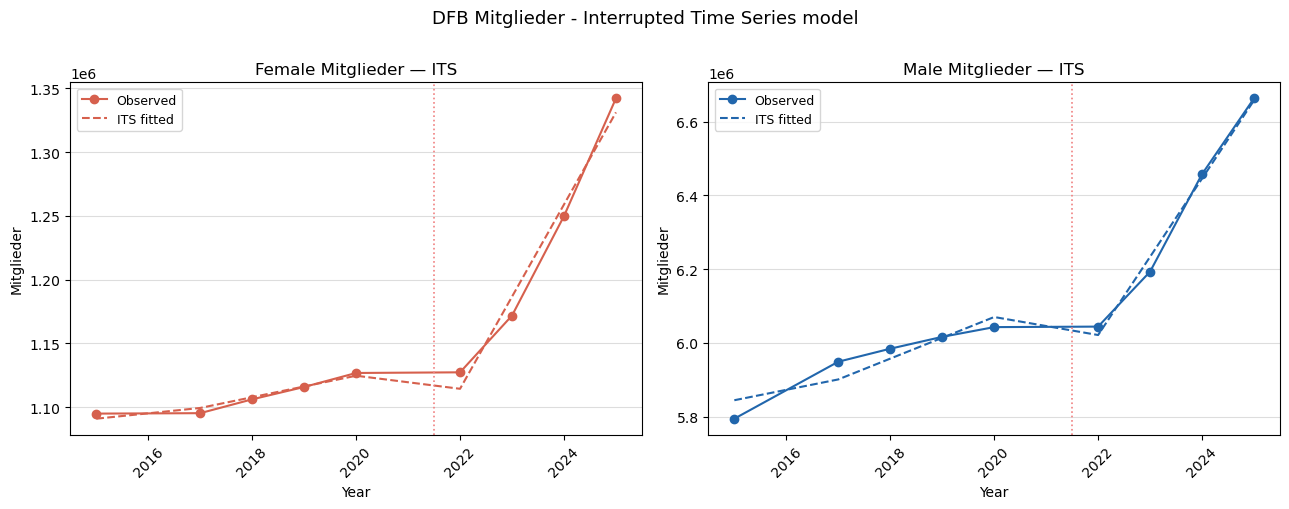

In [13]:
def run_its_dfb(df_g, gender):
    df_g = df_g[df_g["gender"] == gender].sort_values("season").copy()
    df_g = df_g[df_g["season"] != 2021].reset_index(drop=True)
    df_g["t"] = range(len(df_g))
    cutpoint = df_g[df_g["season"] == 2022].index[0]
    df_g["D"]   = (df_g["t"] >= cutpoint).astype(int)
    df_g["t_D"] = (df_g["t"] - cutpoint) * df_g["D"]

    X = sm.add_constant(df_g[["t", "D", "t_D"]])
    y = df_g["registered_players"]
    model = sm.OLS(y, X).fit()

    print(f"\n{'='*50}")
    print(f"ITS model — {gender.upper()}")
    print(f"{'='*50}")
    print(f"  Pre-COVID slope  (β1): {model.params['t']:+,.0f} Mitglieder/year")
    print(f"  Level shift      (β2): {model.params['D']:+,.0f} Mitglieder at disruption")
    print(f"  Slope change     (β3): {model.params['t_D']:+,.0f} Mitglieder/year after COVID")
    print(f"  R²: {model.rsquared:.3f}")
    print(f"  N : {len(df_g)} observations (2021 excluded)")
    return model, df_g

model_f_dfb, df_f_dfb = run_its_dfb(df_dfb_total, "female")
model_m_dfb, df_m_dfb = run_its_dfb(df_dfb_total, "male")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, df_g, model, gender, color in zip(
        axes,
        [df_f_dfb, df_m_dfb],
        [model_f_dfb, model_m_dfb],
        ["female", "male"],
        ["#d6604d", "#2166ac"]):

    X = sm.add_constant(df_g[["t", "D", "t_D"]])
    fitted = model.predict(X)

    ax.plot(df_g["season"], df_g["registered_players"],
            color=color, marker="o", label="Observed")
    ax.plot(df_g["season"], fitted,
            color=color, linestyle="--", linewidth=1.5, label="ITS fitted")
    cutpoint_year = 2022
    cut_x = df_g[df_g["season"] == cutpoint_year]["season"].values[0]
    ax.axvline(x=cut_x - 0.5, color="lightcoral", linestyle=":", linewidth=1.2)
    ax.set_title(f"{gender.capitalize()} Mitglieder — ITS", fontsize=12)
    ax.set_ylabel("Mitglieder")
    ax.set_xlabel("Year")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=9)
    ax.yaxis.grid(True, color="#dddddd", linewidth=0.8)
    ax.set_facecolor("white")

fig.patch.set_facecolor("white")
fig.suptitle("DFB Mitglieder - Interrupted Time Series model", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### What the ITS model tells us

Both models fit the data almost perfectly ($R^2 = 0.989$ for female and $R^2 = 0.985$ for male) which reflects how clean and consistent the post-COVID acceleration is in both series. The three coefficients tell a coherent story.

**Female Mitglieder**
- The pre-COVID slope of **+8,427 members per year** confirms the near-stagnation visible in the chart: female membership was growing, but barely.
- The level shift of **−18,679** captures the COVID dip: approximately 19,000 female members were lost at the point of disruption, equivalent to roughly 1.7% of the pre-COVID base.
- The slope change of **+63,830** is the key result. Post-COVID, female membership is growing at +72,256 per year (+8,427 + 63,830), nearly nine times the pre-COVID pace. The ITS model attributes this almost entirely to a change in slope rather than a level recovery and the series did not simply bounce back to where it was, it shifted onto a structurally steeper trajectory.

**Male Mitglieder**
- The pre-COVID slope of **+56,413 per year** shows that male membership was growing modestly before COVID, unlike the flat-to-declining male trend seen in France.
- The level shift of **−105,247** is the largest absolute COVID shock in the dataset so far with roughly 1.7% of the male base, mirroring the female ratio closely.
- The slope change of **+155,719** produces a post-COVID growth rate of +212,132 per year, nearly four times the pre-COVID pace.

**The common thread across both genders** is that the ITS model identifies a genuine slope change, not merely a rebound. A pure rebound would appear as a large positive level shift ($\beta_2$) followed by a slope returning toward the pre-COVID trend ($\beta_3 \approx 0$). Instead, both models show a modest level shift and a large slope change and the acceleration is persistent across all four post-COVID years, not concentrated in a single recovery year.

This does not resolve the interpretive question raised earlier, i.e. rebound versus structural shift, but it does narrow it. Whatever caused the post-COVID acceleration, it has sustained itself consistently through 2025. The German membership base is behaving differently after COVID than before, in a way that a simple rebound model cannot fully explain.


### Age group breakdown - female Mitglieder

The INJEP data for France allowed a fine-grained age breakdown across nine bands. The DFB publishes a much coarser structure: female members are split into two groups only: *Frauen* (senior, age 17 and above) and *Mädchen* (girls, under 16). The gap between under-16 and 17-and-above is not an error: the DFB age classification has a one-year overlap zone (age 16) that is handled administratively within clubs and does not appear as a separate category in the national statistics.

This coarser structure limits what we can infer about which cohorts are driving growth, but the two-way split is still informative: it tells us whether post-COVID membership growth is concentrated among younger or older female members.

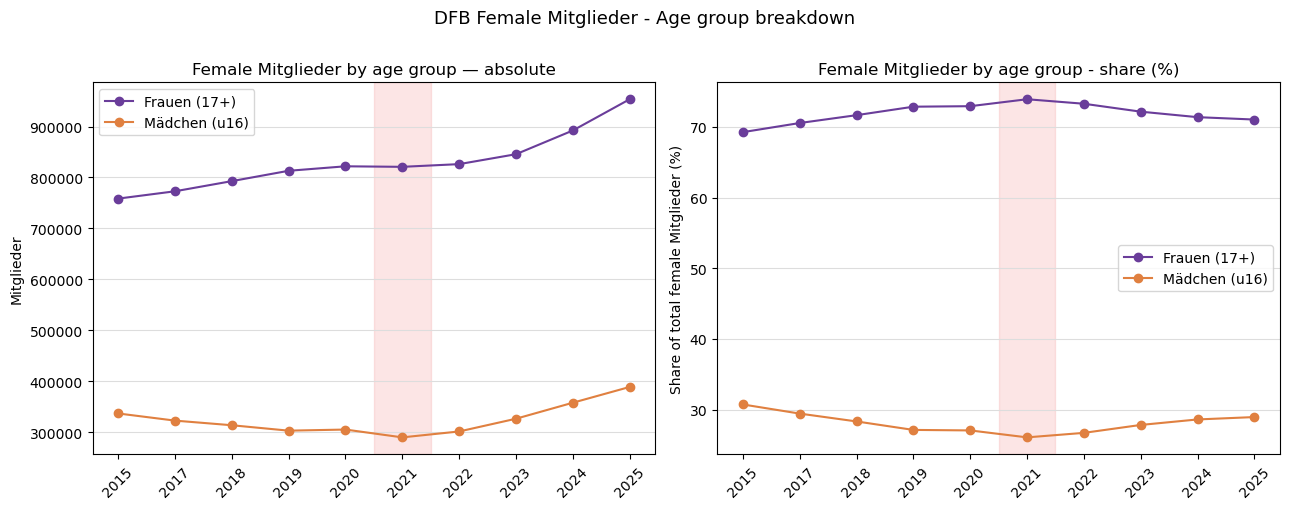

In [14]:
df_dfb_f = df_dfb[df_dfb["gender"] == "female"].copy()

df_dfb_f["total_year"] = df_dfb_f.groupby("season")["registered_players"].transform("sum")
df_dfb_f["share_pct"]  = df_dfb_f["registered_players"] / df_dfb_f["total_year"] * 100

years_f = sorted(df_dfb_f["season"].unique())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = {"senior": "#6a3d9a", "youth": "#e08040"}
labels = {"senior": "Frauen (17+)", "youth": "Mädchen (u16)"}

for group in ["senior", "youth"]:
    sub = df_dfb_f[df_dfb_f["age_group"] == group].sort_values("season")
    axes[0].plot(range(len(years_f)), sub["registered_players"].values,
                 marker="o", color=colors[group], label=labels[group])
    axes[1].plot(range(len(years_f)), sub["share_pct"].values,
                 marker="o", color=colors[group], label=labels[group])

covid_x = years_f.index(2021)
for ax in axes:
    ax.axvspan(covid_x - 0.5, covid_x + 0.5,
               color="lightcoral", alpha=0.2)
    ax.set_xticks(range(len(years_f)))
    ax.set_xticklabels(years_f, rotation=45)
    ax.legend(fontsize=10)
    ax.yaxis.grid(True, color="#dddddd", linewidth=0.8)
    ax.set_facecolor("white")

axes[0].set_title("Female Mitglieder by age group — absolute", fontsize=12)
axes[0].set_ylabel("Mitglieder")
axes[1].set_title("Female Mitglieder by age group - share (%)", fontsize=12)
axes[1].set_ylabel("Share of total female Mitglieder (%)")

fig.patch.set_facecolor("white")
fig.suptitle("DFB Female Mitglieder - Age group breakdown", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### Who is driving female membership growth in Germany?

The picture is clear and contrasts sharply with France.

**Growth is adult-led.** Frauen (17+) account for almost all of the post-COVID membership increase. In absolute terms, senior female members rose from roughly 820,000 in 2021 to 950,000 in 2025, with a gain of approximately 130,000 members in four years, compared to a gain of less than 70,000 across the entire pre-COVID window from 2015 to 2020. Mädchen (under 16) also grew post-COVID, from around 305,000 in 2021 to 390,000 in 2025, but the absolute gains are smaller and the trajectory only becomes clearly positive from 2023 onward.

**The share panel confirms the story.** Frauen consistently represent roughly 70–75% of total female Mitglieder throughout the series, with no structural shift in composition. Unlike France, where the share of youth licences rose steadily from 50% to 62% over the same period, Germany's female membership age structure has remained stable. Growth is happening at all ages but it is not youth-led.

**Pre-COVID, Mädchen were declining.** From 2015 to 2020, girls' membership fell from roughly 340,000 to 305,000, with a loss of around 35,000 members before COVID arrived. This quiet decline in the youth base is a potentially important structural signal: a federation that is not recruiting young girls is not building its future pipeline. The post-COVID recovery in Mädchen membership is notable, but it has only recently returned to 2015 levels.

Taken together, the German female age breakdown suggests a membership base that is growing primarily through **adult retention** and re-engagement rather than youth recruitment, a different pattern we noticed from France. Whether this reflects differences in grassroots investment, club structures, or simply the age profile of the women attracted by the post-2022 surge in interest in women's football, is a question the data raises but cannot answer on its own.

## Spain - RFEF Memoria Anual



Spain is the only Big 5 country where the primary national federation source separates two distinct disciplines: outdoor **fútbol** and indoor **fútbol sala** (futsal). Both are governed by the Real Federación Española de Fútbol (RFEF) and counted together in the public Consejo Superior de Deportes (CSD) licence statistics, the aggregated source used in most cross-country comparisons. For our analysis we use the *RFEF Memoria Anual* directly, which provides the discipline-level split we need.

All figures in this section are **playing licences** (*licencias de jugadores*), excluding coaches (*técnicos*) and referees (*árbitros*), which are reported separately in the Memoria and are not included here. This makes the Spanish metric conceptually closer to the French INJEP and Italian FIGC counts than to the German Mitglieder.

One caveat about the data, is that they contain a structural break in the *Veterano*, male category. As I will show later, in the seasons 2015-16 to 2017-18, RFEF reports a *veterano* figure in the range of 100,000–110,000 players. From 2018-19 onward, the figure collapses to fewer than 10,000, and by 2022-23 it is below 500. This is a signal of a *classification change*: veterans were likely moved into the *Aficionado* (amateur adult) category from 2018-19 onward rather than a genuine loss of participation. Because of this inconsistency, the adult share will be artificially inflated in the three early seasons, and the series should not be used to track adult male trends across the full period without acknowledging this break.

**Why we lead with football.** Fútbol sala is a meaningful part of Spanish football culture. In 2022-23 it accounted for roughly 130,000 licences compared to 950,000 for outdoor football, around 13% of the combined total. However, no other Big 5 federation reports futsal under the same governing body or includes it in their primary participation count. Leading with outdoor football only is therefore the correct basis for any future cross-country comparison. We retain futsal in this section for one specific purpose: its COVID behaviour differs from outdoor football in an instructive way, and comparing the two disciplines illustrates how different forms of participation responded differently to the same external shock.

**Data coverage.** The RFEF Memoria is available for seasons 2013-14 to 2022-23: ten seasons in total. All seasons are image-verified: nine seasons carry a confirmed quality flag, while 2019-20 football is flagged estimated due to a footer mis-reporting issue in the source document that left a residual of 181 unattributed licences. Age breakdowns are available for all ten seasons and both sports (football and futsal), with one exception: 2019-20 futsal is confirmed, while 2019-20 football age data is estimated for the same reason noted above. The 2022-23 futsal female breakdown includes a new base age category not present in prior seasons.


In [15]:
RFEF_CSV     = PROCESSED_DIR / "rfef_spain_football_licences.csv"
RFEF_AGE_CSV = PROCESSED_DIR / "rfef_spain_football_licences_age.02.csv"

df_rfef     = pd.read_csv(RFEF_CSV)
df_rfef_age = pd.read_csv(RFEF_AGE_CSV)

print("=== Main CSV ===")
print(df_rfef.shape)
print(df_rfef[["season","sport","gender","registered_players","quality_flag"]].to_string(index=False))

print("\n=== Age CSV ===")
print(df_rfef_age.shape)
print(df_rfef_age["season"].value_counts().sort_index())


=== Main CSV ===
(60, 11)
 season    sport gender  registered_players quality_flag
2013-14 football female               31314    confirmed
2013-14 football   male              682813    confirmed
2013-14 football  total              714127    confirmed
2013-14   futsal female                9571    confirmed
2013-14   futsal   male               86531    confirmed
2013-14   futsal  total               96014    confirmed
2014-15 football female               29904    confirmed
2014-15 football   male              700526    confirmed
2014-15 football  total              730430    confirmed
2014-15   futsal female                9821    confirmed
2014-15   futsal   male               89821    confirmed
2014-15   futsal  total               99524    confirmed
2015-16 football female               31831    confirmed
2015-16 football   male              720376    confirmed
2015-16 football  total              752207    confirmed
2015-16   futsal female                9816    confirmed
2015-

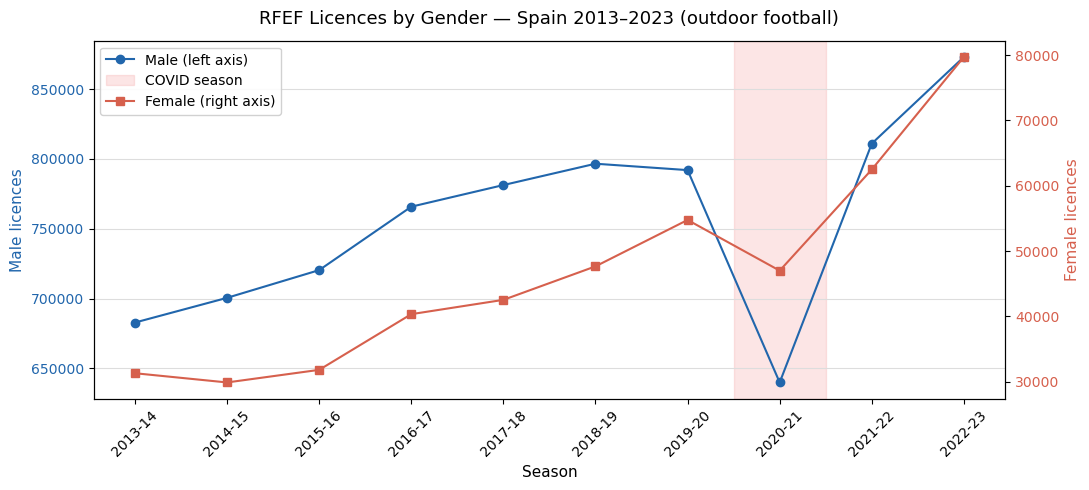

In [16]:
df_fb = df_rfef[(df_rfef["sport"] == "football") & (df_rfef["gender"] != "total")].copy()
df_fb_male   = df_fb[df_fb["gender"] == "male"].sort_values("season")
df_fb_female = df_fb[df_fb["gender"] == "female"].sort_values("season")

seasons = sorted(df_fb["season"].unique())
x_pos   = range(len(seasons))
COVID_SEASON = "2020-21"
covid_idx = list(seasons).index(COVID_SEASON)

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

color_male   = "#2166ac"
color_female = "#d6604d"

ax1.plot(list(x_pos), df_fb_male["registered_players"].values,
         color=color_male, marker="o", label="Male (left axis)")
ax2.plot(list(x_pos), df_fb_female["registered_players"].values,
         color=color_female, marker="s", label="Female (right axis)")

ax1.axvspan(covid_idx - 0.5, covid_idx + 0.5,
            color="lightcoral", alpha=0.2, label="COVID season")

ax1.set_ylabel("Male licences", color=color_male, fontsize=11)
ax2.set_ylabel("Female licences", color=color_female, fontsize=11)
ax1.tick_params(axis="y", labelcolor=color_male)
ax2.tick_params(axis="y", labelcolor=color_female)
ax1.set_xlabel("Season", fontsize=11)
ax1.set_xticks(list(x_pos))
ax1.set_xticklabels(seasons, rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", framealpha=0.9)

ax1.yaxis.grid(True, color="#dddddd", linewidth=0.8)
ax2.yaxis.grid(False)
ax1.set_facecolor("white")
fig.patch.set_facecolor("white")

plt.title("RFEF Licences by Gender — Spain 2013–2023 (outdoor football)", fontsize=13, pad=12)
plt.tight_layout()
plt.show()


The chart below shows RFEF outdoor football licences by gender from 2013-14 to 2022-23 and, as with France and Germany, a dual y-axis is used. The 2020-21 season is shaded to mark the COVID disruption.

**Male licences** grew steadily from 2013-14 to 2018-19, reaching a peak of just under 800,000, then dipped slightly in 2019-20 before the COVID shock produced a dramatic collapse in 2020-21 with a drop of roughly 155,000 licences, the steepest single-season fall in the series. Recovery was rapid: by 2021-22 male licences had almost returned to the pre-COVID peak, and by 2022-23 they surpassed it, reaching approximately 873,000.

**Female licences** growth before COVID was slow and uneven: the series dipped from 31,000 in 2013-14 to 30,000 in 2014-15 before recovering and then accelerating from 2016-17 onward. By 2019-20, female licences had reached approximately 55,000. The COVID disruption produced a smaller absolute drop than on the male side, but the relative shock was comparable. What is most striking is the post-COVID trajectory: female licences accelerated sharply after 2020-21, reaching approximately 80,000 by 2022-23, more than doubling the 2013-14 baseline in a decade.

Before reading the trends, the same COVID caveat raised for France applies here: the post-COVID rebound can inflate apparent growth rates, and with only two confirmed post-COVID seasons the distinction between structural acceleration and rebound effect cannot yet be resolved with certainty.

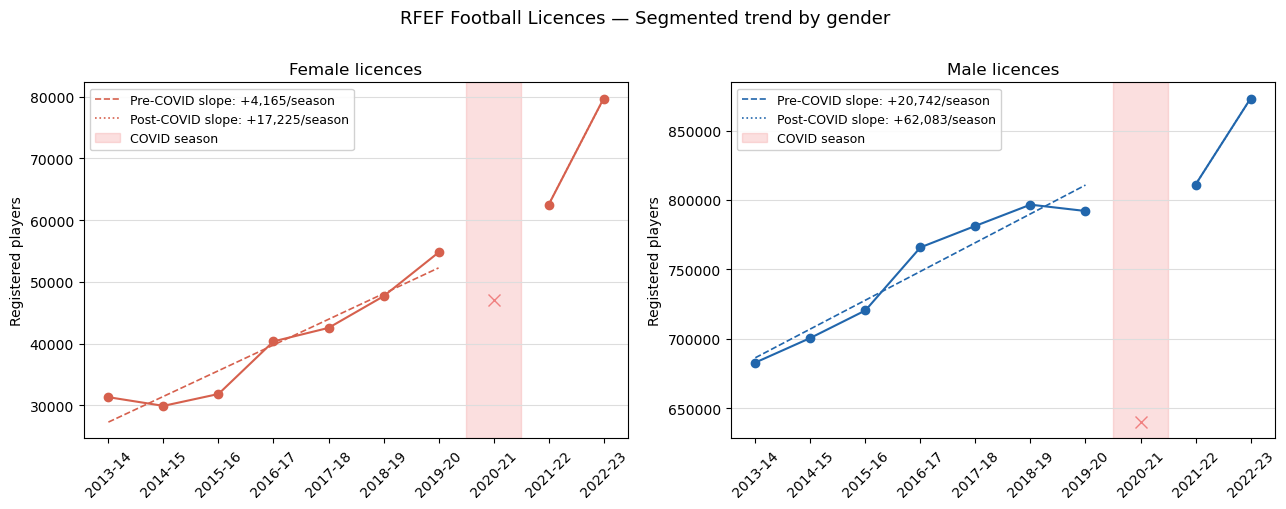

In [17]:
PRE_COVID_RFEF  = ["2013-14", "2014-15", "2015-16", "2016-17", "2017-18", "2018-19", "2019-20"]
POST_COVID_RFEF = ["2021-22", "2022-23"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

for ax, gender, color in zip(axes, ["female", "male"], ["#d6604d", "#2166ac"]):
    df_g = df_fb[df_fb["gender"] == gender].sort_values("season").set_index("season")

    pre  = df_g.loc[PRE_COVID_RFEF,  "registered_players"]
    post = df_g.loc[POST_COVID_RFEF, "registered_players"]

    x_pre  = np.arange(len(pre))
    x_post = np.arange(len(pre) + 1, len(pre) + 1 + len(post))

    slope_pre,  intercept_pre,  *_ = stats.linregress(x_pre,  pre.values)
    slope_post, intercept_post, *_ = stats.linregress(x_post, post.values)

    all_seasons = PRE_COVID_RFEF + [COVID_SEASON] + POST_COVID_RFEF
    x_all = list(range(len(all_seasons)))
    x_map = {s: i for i, s in enumerate(all_seasons)}

    ax.plot([x_map[s] for s in PRE_COVID_RFEF],  pre.values,  color=color, marker="o")
    ax.plot([x_map[s] for s in POST_COVID_RFEF], post.values, color=color, marker="o")

    ax.plot(x_pre,  intercept_pre  + slope_pre  * x_pre,
            color=color, linestyle="--", linewidth=1.2,
            label=f"Pre-COVID slope: {slope_pre:+,.0f}/season")
    ax.plot(x_post, intercept_post + slope_post * x_post,
            color=color, linestyle=":",  linewidth=1.2,
            label=f"Post-COVID slope: {slope_post:+,.0f}/season")

    covid_x = x_map[COVID_SEASON]
    ax.axvspan(covid_x - 0.5, covid_x + 0.5,
               color="lightcoral", alpha=0.25, label="COVID season")
    ax.plot(covid_x, df_g.loc[COVID_SEASON, "registered_players"],
            color="lightcoral", marker="x", markersize=9, zorder=5)

    ax.set_xticks(x_all)
    ax.set_xticklabels(all_seasons, rotation=45)
    ax.set_title(f"{gender.capitalize()} licences", fontsize=12)
    ax.set_ylabel("Registered players")
    ax.legend(fontsize=9, framealpha=0.9)
    ax.yaxis.grid(True, color="#dddddd", linewidth=0.8)
    ax.set_facecolor("white")

fig.patch.set_facecolor("white")
fig.suptitle("RFEF Football Licences — Segmented trend by gender", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### What the segmented trends tell us

The segmented trends reveal a pattern distinct from both France and Germany.

**Female licences** were growing before COVID, but modestly: the pre-COVID slope of +4,165 licences per season is steady, robust but not exceptional on a base that started below 32,000. The post-COVID slope of +17,225 per season is more than four times steeper with a steeeper acceleration on a series that was already in positive territory. As with Germany, the key question is whether this reflects a structural shift or a rebound effect. With only two post-COVID points, we cannot be certain, but the magnitude of the change is notable.

**Male licences** were growing more strongly before COVID: +20,742 per season across seven seasons, a sustained and consistent upward trend. The post-COVID slope of +62,083 is three times larger, but here the rebound interpretation is more compelling: male licences collapsed by roughly 155,000 in 2020-21, and the two post-COVID seasons are recovering rapidly from a very deep trough. The high post-COVID slope is at least partly a mathematical consequence of the severity of the COVID shock rather than evidence of new structural momentum.

One feature of the Spanish female series worth noting is the early dip: licences fell from 31,000 in 2013-14 to 30,000 in 2014-15 before recovering. This makes the pre-COVID linear fit less reliable than for France, where growth was smooth throughout. The underlying female trend in Spain from 2015-16 onward is steeper than the seven-season slope suggests.



ITS model - FEMALE
  Pre-COVID slope  (β1): +4,165 licences/season
  Level shift      (β2): +6,064 licences at disruption
  Slope change     (β3): +13,060 licences/season after COVID
  R²: 0.981
  N : 9 observations (COVID season excluded)

ITS model - MALE
  Pre-COVID slope  (β1): +20,742 licences/season
  Level shift      (β2): -20,434 licences at disruption
  Slope change     (β3): +41,341 licences/season after COVID
  R²: 0.967
  N : 9 observations (COVID season excluded)


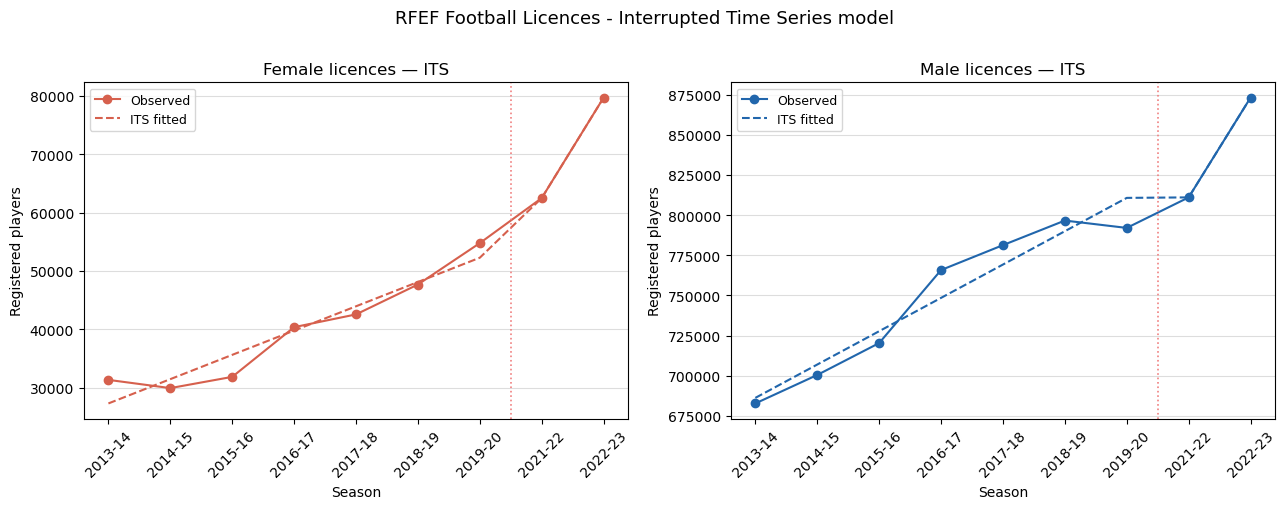

In [18]:
def run_its_rfef(df_g, gender):
    df_g = df_g[df_g["gender"] == gender].sort_values("season").copy()
    df_g = df_g[df_g["season"] != "2020-21"].reset_index(drop=True)
    df_g["t"] = range(len(df_g))
    cutpoint = df_g[df_g["season"] == "2021-22"].index[0]
    df_g["D"]   = (df_g["t"] >= cutpoint).astype(int)
    df_g["t_D"] = (df_g["t"] - cutpoint) * df_g["D"]

    X = sm.add_constant(df_g[["t", "D", "t_D"]])
    y = df_g["registered_players"]
    model = sm.OLS(y, X).fit()

    print(f"\n{'='*50}")
    print(f"ITS model - {gender.upper()}")
    print(f"{'='*50}")
    print(f"  Pre-COVID slope  (β1): {model.params['t']:+,.0f} licences/season")
    print(f"  Level shift      (β2): {model.params['D']:+,.0f} licences at disruption")
    print(f"  Slope change     (β3): {model.params['t_D']:+,.0f} licences/season after COVID")
    print(f"  R²: {model.rsquared:.3f}")
    print(f"  N : {len(df_g)} observations (COVID season excluded)")
    return model, df_g

model_f_rfef, df_f_rfef = run_its_rfef(df_fb, "female")
model_m_rfef, df_m_rfef = run_its_rfef(df_fb, "male")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, df_g, model, gender, color in zip(
        axes,
        [df_f_rfef, df_m_rfef],
        [model_f_rfef, model_m_rfef],
        ["female", "male"],
        ["#d6604d", "#2166ac"]):

    X = sm.add_constant(df_g[["t", "D", "t_D"]])
    fitted = model.predict(X)

    ax.plot(df_g["season"], df_g["registered_players"],
            color=color, marker="o", label="Observed")
    ax.plot(df_g["season"], fitted,
            color=color, linestyle="--", linewidth=1.5, label="ITS fitted")
    ax.axvline(x=df_g[df_g["season"] == "2021-22"].index[0] - 0.5,
               color="lightcoral", linestyle=":", linewidth=1.2)
    ax.set_title(f"{gender.capitalize()} licences — ITS", fontsize=12)
    ax.set_ylabel("Registered players")
    ax.set_xlabel("Season")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=9)
    ax.yaxis.grid(True, color="#dddddd", linewidth=0.8)
    ax.set_facecolor("white")

fig.patch.set_facecolor("white")
fig.suptitle("RFEF Football Licences - Interrupted Time Series model", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### What the ITS model tells us

Both models fit the data well: $R^2 = 0.981$ for female and $R^2 = 0.967$ for male, reflecting the broadly consistent trends in both series. The coefficients tell a complex story that goes beyond what the segmented trend revealed.

**Female licences** ($R^2 = 0.981$)

The three parameters decompose the COVID effect cleanly:

- Pre-COVID growth was **+4,165 licences per season**; positive but modest on a base of roughly 30,000 to 55,000
- The level shift of **+6,064** is positive, which is unusual: rather than a drop at the point of disruption, the ITS model finds that female licences were *above* where the pre-COVID trend would have predicted at the point of recovery. This reflects the early-dip in 2013-14 to 2014-15 pulling the pre-COVID fitted line downward, so the post-COVID starting point looks elevated by comparison
- The slope change of **+13,060** is the key result: post-COVID female growth is running at +17,225 per season (+4,165 + 13,060), more than four times the pre-COVID pace

**Male licences** ($R^2 = 0.967$)

- Pre-COVID growth was **+20,742 licences per season** with steady and sustained pace across seven seasons
- The level shift of **−20,434** captures the COVID shock: approximately one season's worth of growth was wiped out at the point of disruption
- The slope change of **+41,341** produces a post-COVID growth rate of +62,083 per season; three times the pre-COVID pace, but almost certainly inflated by the recovery from the 2020-21 trough

**Comparing Spain with France and Germany**

Spain's female ITS result sits between France and Germany. Like France, the pre-COVID trend was positive throughout; like Germany, the post-COVID slope is substantially steeper. The post-COVID female acceleration is real in all three countries, but its causes may differ: in France it appears structural and unrelated to a single event; in Germany and Spain the timing coincides with the post-2022 surge in interest in women's football across Europe. In Spain specifically, the 2023 Women's World Cup victory, which falls just outside our data window, may sustain or amplify this trend in future seasons.

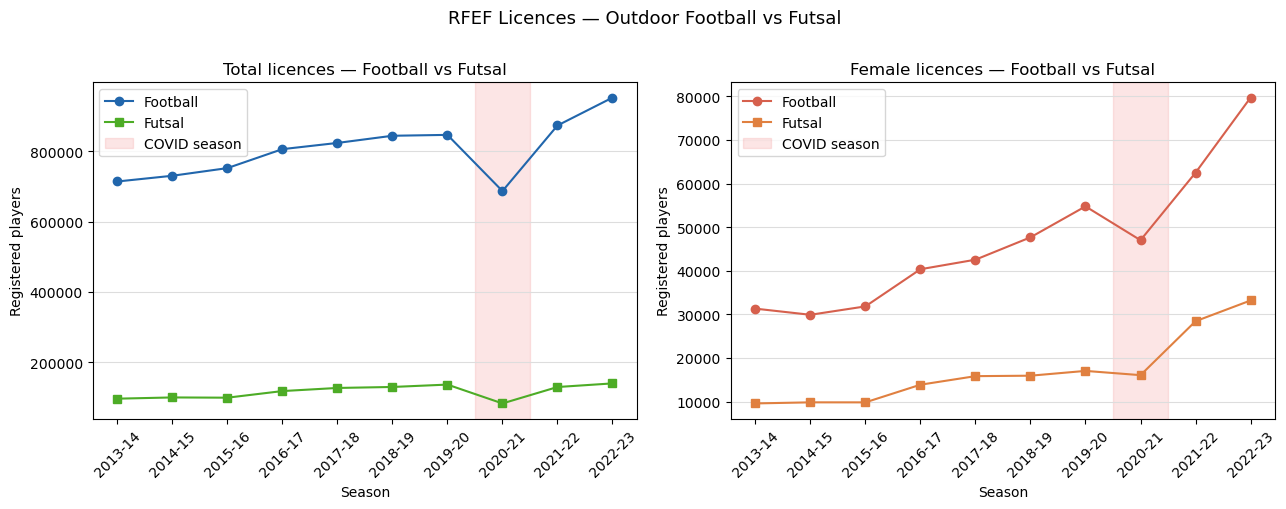

In [19]:
df_rfef_total = df_rfef[df_rfef["gender"] == "total"].copy()
df_rfef_total = df_rfef_total.sort_values(["sport", "season"])

seasons = sorted(df_rfef_total["season"].unique())
x_pos   = range(len(seasons))
covid_idx = list(seasons).index("2020-21")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: absolute totals
for sport, color, marker in [("football", "#2166ac", "o"), ("futsal", "#4dac26", "s")]:
    sub = df_rfef_total[df_rfef_total["sport"] == sport].sort_values("season")
    axes[0].plot(list(x_pos), sub["registered_players"].values,
                 color=color, marker=marker, label=sport.capitalize())

axes[0].axvspan(covid_idx - 0.5, covid_idx + 0.5,
                color="lightcoral", alpha=0.2, label="COVID season")
axes[0].set_title("Total licences — Football vs Futsal", fontsize=12)
axes[0].set_ylabel("Registered players")
axes[0].set_xlabel("Season")
axes[0].set_xticks(list(x_pos))
axes[0].set_xticklabels(seasons, rotation=45)
axes[0].legend(fontsize=10)
axes[0].yaxis.grid(True, color="#dddddd", linewidth=0.8)
axes[0].set_facecolor("white")

# Right: female licences only, both sports
df_rfef_female = df_rfef[df_rfef["gender"] == "female"].copy()

for sport, color, marker in [("football", "#d6604d", "o"), ("futsal", "#e08040", "s")]:
    sub = df_rfef_female[df_rfef_female["sport"] == sport].sort_values("season")
    axes[1].plot(list(x_pos), sub["registered_players"].values,
                 color=color, marker=marker, label=sport.capitalize())

axes[1].axvspan(covid_idx - 0.5, covid_idx + 0.5,
                color="lightcoral", alpha=0.2, label="COVID season")
axes[1].set_title("Female licences — Football vs Futsal", fontsize=12)
axes[1].set_ylabel("Registered players")
axes[1].set_xlabel("Season")
axes[1].set_xticks(list(x_pos))
axes[1].set_xticklabels(seasons, rotation=45)
axes[1].legend(fontsize=10)
axes[1].yaxis.grid(True, color="#dddddd", linewidth=0.8)
axes[1].set_facecolor("white")

fig.patch.set_facecolor("white")
fig.suptitle("RFEF Licences — Outdoor Football vs Futsal", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### Football vs Futsal

Comparing outdoor football and futsal can give us some insight about the behaviorof Spanish fan with respect the COVID disruption.

**In aggregate** (left panel), football dominates by a factor of roughly six to one: approximately 950,000 football licences versus 140,000 futsal licences in 2022-23. Both series grew modestly before COVID. The COVID shock hit football far harder in absolute terms with a drop of roughly 155,000 licences in 2020-21, while futsal fell by only about 45,000 from its 2019-20 level. In relative terms the two disciplines were similarly affected, but the football recovery was faster and more complete: by 2022-23 football licences were well above the pre-COVID peak, while futsal had only just returned to pre-COVID levels.

**The female panel** (right panel) presents a sharper picture. Female football licences and female futsal licences were on broadly similar trajectories until 2019-20, with football at roughly 55,000 and futsal at 17,000, but after COVID, the two series diverge dramatically. Female football licences accelerated to 80,000 by 2022-23 with a gain of roughly 25,000 licences in two seasons. Female futsal licences, by contrast, jumped from 16,000 in 2020-21 to 33,000 in 2022-23, effectively doubling in two seasons from a much lower base.

We can draw two observations. First, the post-COVID female futsal surge is proportionally larger than the football surge, but it starts from a much smaller base and its absolute contribution to total female participation remains modest. Second, the divergence between football and futsal after COVID suggests that the two disciplines may be responding to different structural forces: football growth may be driven by the broader cultural visibility of women's football, while futsal growth may reflect different dynamics in indoor recreational sport. With only two post-COVID seasons, we cannot distinguish these effects with confidence.

One cross-country note: because no other Big 5 federation separates futsal from outdoor football in its primary licence count, the Spanish total of roughly 1.09 million combined licences in 2022-23 is not directly comparable to figures from France, Germany, England, or Italy. All cross-country comparisons in later sections use outdoor football only.


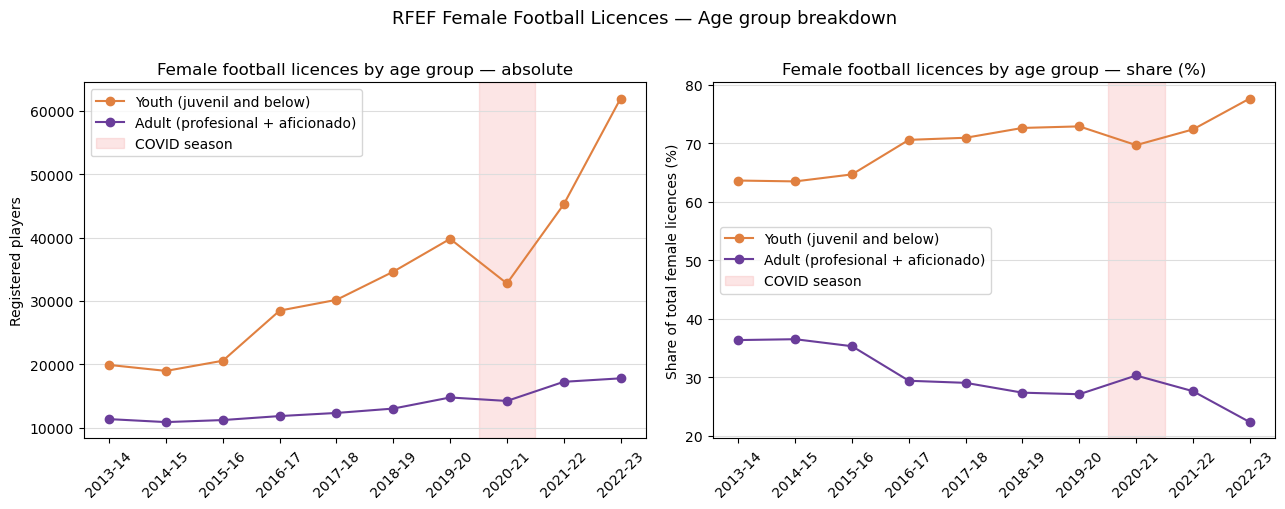

In [20]:
df_age_fb_f = df_rfef_age[
    (df_rfef_age["sport"] == "football") &
    (df_rfef_age["gender"] == "female")
].copy()

YOUTH_LABELS = ["juvenil","cadete","infantil","alevin","benjamin","prebenjamin","debutante","base"]
ADULT_LABELS = ["profesional","aficionado"]

def assign_broad(label):
    return "youth" if label in YOUTH_LABELS else "adult"

df_age_fb_f["broad_group"] = df_age_fb_f["age_label"].apply(assign_broad)

df_broad_fb_f = (
    df_age_fb_f.groupby(["season","broad_group"])["registered_players"]
    .sum().unstack(fill_value=0).reset_index()
)
df_broad_fb_f["total"] = df_broad_fb_f["adult"] + df_broad_fb_f["youth"]
df_broad_fb_f["share_adult"] = df_broad_fb_f["adult"] / df_broad_fb_f["total"] * 100
df_broad_fb_f["share_youth"] = df_broad_fb_f["youth"] / df_broad_fb_f["total"] * 100
df_broad_fb_f = df_broad_fb_f.sort_values("season")

seasons_age = df_broad_fb_f["season"].tolist()
x_pos = range(len(seasons_age))
covid_idx = list(seasons_age).index("2020-21")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = {"youth": "#e08040", "adult": "#6a3d9a"}
labels_map = {"youth": "Youth (juvenil and below)", "adult": "Adult (profesional + aficionado)"}

for group in ["youth", "adult"]:
    axes[0].plot(list(x_pos), df_broad_fb_f[group].values,
                 marker="o", color=colors[group], label=labels_map[group])
    axes[1].plot(list(x_pos), df_broad_fb_f[f"share_{group}"].values,
                 marker="o", color=colors[group], label=labels_map[group])

for ax in axes:
    ax.axvspan(covid_idx - 0.5, covid_idx + 0.5,
               color="lightcoral", alpha=0.2, label="COVID season")
    ax.set_xticks(list(x_pos))
    ax.set_xticklabels(seasons_age, rotation=45)
    ax.legend(fontsize=10)
    ax.yaxis.grid(True, color="#dddddd", linewidth=0.8)
    ax.set_facecolor("white")

axes[0].set_title("Female football licences by age group — absolute", fontsize=12)
axes[0].set_ylabel("Registered players")
axes[1].set_title("Female football licences by age group — share (%)", fontsize=12)
axes[1].set_ylabel("Share of total female licences (%)")

fig.patch.set_facecolor("white")
fig.suptitle("RFEF Female Football Licences — Age group breakdown", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


### Who is driving female football growth in Spain?

The age breakdown plot looks very clear: **female football growth in Spain is pushed by young players, and this pattern is consistent across multiple seasons**.

In 2013-14, roughly 64% of female football licences were held by players in youth categories (juvenil and below), with the remaining 36% in adult categories (profesional and aficionado). By 2022-23, the youth share had risen to approximately 78%, while the adult share had fallen to around 22%. The composition has shifted steadily and consistently in one direction over a decade.

In absolute terms, youth licences grew from approximately 20,000 in 2013-14 to 62,000 in 2022-23 more than tripling over the period. Adult licences grew far more modestly, from roughly 11,000 to 18,000, with almost no growth visible between 2013-14 and 2018-19 before a slight acceleration in the post-COVID seasons.

The COVID disruption is visible in both series but affects them differently. Youth licences dropped sharply in 2020-21 and then rebounded dramatically: the post-COVID acceleration is almost entirely a youth phenomenon. Adult licences dipped modestly and recovered slowly, with their share of total female licences temporarily rising in 2020-21 before resuming its structural decline.

Two findings are worth carrying into the cross-country comparison. First, the youth dominance of Spanish female football is even more pronounced than in France, where the youth share reached approximately 62% by 2022-23 compared to 78% in Spain. Second, the adult female base in Spain is thin and barely growing, approximately 18,000 licences in a country of 48 million people. This suggests that the overall growth in Spanish female football is driven by new entrants at young ages rather than by adult women taking up or returning to organised football.

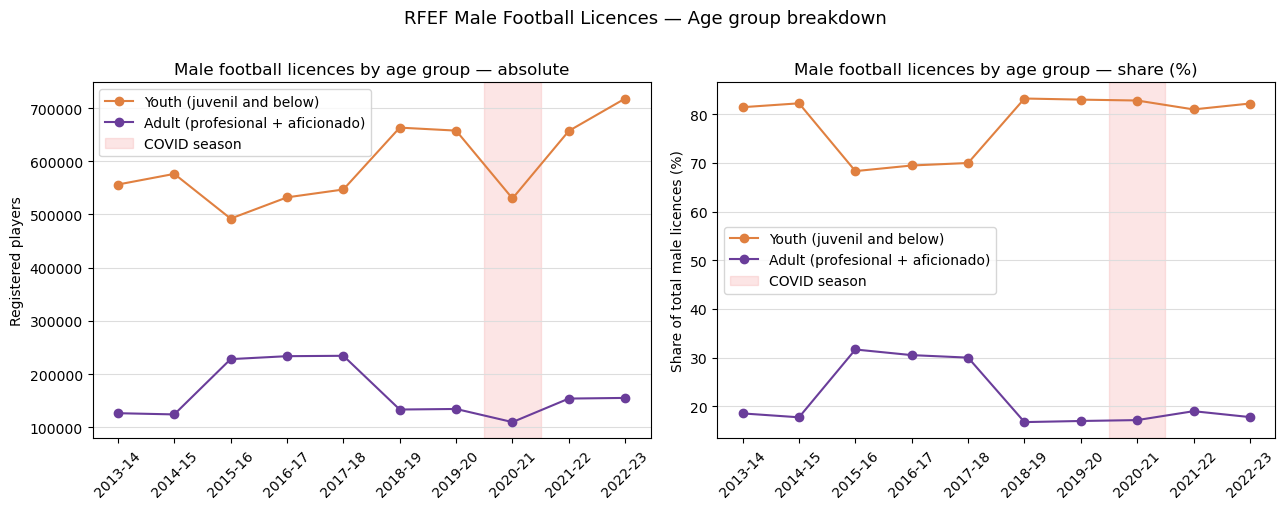


Veterano licences by season:
 season  registered_players
2015-16              104283
2016-17              106123
2017-18              109913
2018-19                9840
2019-20                1325
2020-21                 926
2021-22                1149
2022-23                 498


In [21]:
df_age_fb_m = df_rfef_age[
    (df_rfef_age["sport"] == "football") &
    (df_rfef_age["gender"] == "male")
].copy()

YOUTH_LABELS_M = ["juvenil","cadete","infantil","alevin","benjamin","prebenjamin","debutante","base"]
ADULT_LABELS_M = ["profesional","aficionado","veterano"]

def assign_broad_m(label):
    return "youth" if label in YOUTH_LABELS_M else "adult"

df_age_fb_m["broad_group"] = df_age_fb_m["age_label"].apply(assign_broad_m)

df_broad_fb_m = (
    df_age_fb_m.groupby(["season","broad_group"])["registered_players"]
    .sum().unstack(fill_value=0).reset_index()
)
df_broad_fb_m["total"] = df_broad_fb_m["adult"] + df_broad_fb_m["youth"]
df_broad_fb_m["share_adult"] = df_broad_fb_m["adult"] / df_broad_fb_m["total"] * 100
df_broad_fb_m["share_youth"] = df_broad_fb_m["youth"] / df_broad_fb_m["total"] * 100
df_broad_fb_m = df_broad_fb_m.sort_values("season")

seasons_m = df_broad_fb_m["season"].tolist()
x_pos_m   = range(len(seasons_m))
covid_idx_m = list(seasons_m).index("2020-21")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for group in ["youth", "adult"]:
    axes[0].plot(list(x_pos_m), df_broad_fb_m[group].values,
                 marker="o", color=colors[group], label=labels_map[group])
    axes[1].plot(list(x_pos_m), df_broad_fb_m[f"share_{group}"].values,
                 marker="o", color=colors[group], label=labels_map[group])

for ax in axes:
    ax.axvspan(covid_idx_m - 0.5, covid_idx_m + 0.5,
               color="lightcoral", alpha=0.2, label="COVID season")
    ax.set_xticks(list(x_pos_m))
    ax.set_xticklabels(seasons_m, rotation=45)
    ax.legend(fontsize=10)
    ax.yaxis.grid(True, color="#dddddd", linewidth=0.8)
    ax.set_facecolor("white")

axes[0].set_title("Male football licences by age group — absolute", fontsize=12)
axes[0].set_ylabel("Registered players")
axes[1].set_title("Male football licences by age group — share (%)", fontsize=12)
axes[1].set_ylabel("Share of total male licences (%)")

fig.patch.set_facecolor("white")
fig.suptitle("RFEF Male Football Licences — Age group breakdown", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Print veterano counts to check
print("\nVeterano licences by season:")
print(df_age_fb_m[df_age_fb_m["age_label"]=="veterano"][["season","registered_players"]].to_string(index=False))


### Male age breakdown


The age structure of male registered players in Spain shows a similar pattern to female players, with one important caveat. The youth categories (Cadete, Infantil, Alevín, Benjamín, Prebenjamín, and Debutante) account for a substantial and growing share of total registrations, while the adult share has remained broadly stable in recent seasons.

As previously mentioned, the data contains a structural break in the *Veterano* category. As a result, for the 2015-16 to 2017-18 seasons, the chart combines veterans with the adult stack; this overstates the comparable adult figure relative to later years. A consistent adult trend can be read from 2018-19 onward, where veterano values are negligible and the Aficionado category carries the adult signal.

## Findings so far: Germany, France, and Spain

Across the three countries examined so far, the picture is consistent. Women's registered football players grew steadily throughout the 2010s, accelerated after a brief COVID-induced dip in 2019-20 and 2020-21, and reached new highs by 2022-23. Germany leads in absolute numbers, with over 1.1 million female registered players by the end of the period; France and Spain follow, each in the 200,000–500,000 range depending on whether futsal licences are included.

The growth is not uniform in pace. Germany's expansion was already well underway before 2015, reflecting decades of federation investment and a dense club infrastructure. France and Spain show steeper relative growth in the latter half of the period, suggesting a structural push coming from league professionalisation, federation programmes, media visibility. It came later but gathered momentum quickly.

One methodological note is worth keeping in mind before reading further. Germany, France, and Spain all count *registered* players: individuals holding an active licence with their national federation. This is a hard count, tied to club membership and formal participation. The numbers are directly comparable across these three countries.

Italy fits this same framework. England does not, and that difference will matter when we get there.


## Italy - tesserati FIGC



### Data source and methodology



Italy's participation data comes from the **FIGC ReportCalcio**, an annual statistical report published by the Federazione Italiana Giuoco Calcio. The report covers registered players (*tesserati*) across all FIGC-affiliated clubs and competitions. Unlike survey-based estimates, tesserati represent a hard count: every individual holding an active licence with the federation in a given season is counted once.

The FIGC organises registrations into three activity categories:

| Category | Description |
|---|---|
| **Dilettantistica** | Amateur football. Is the largest category, covering all non-professional adult and youth players outside the youth sector organisation |
| **Professionistica** | Professional football. The players registered in the top professional leagues (Serie A, Serie B, Serie C for men; Serie A Femminile for women from 2022-23) |
| **SGS** (Settore Giovanile e Scolastico) | The youth and school sector, i.e. the FIGC's dedicated youth development structure, covering players from the youngest age groups through to under-18 |

These three categories are mutually exclusive and sum to the total tesserati figure. The SGS is the most relevant indicator of grassroots pipeline health: growth here reflects new players entering the system at the base of the pyramid.

Data is drawn from ten ReportCalcio editions covering seasons 2013-14 through 2022-23. Each edition reports data for the season ending in the previous calendar year (e.g. the 2023 report covers 2021-22 data). All figures are sourced directly from the registration census tables (*censimento del sistema*) in each PDF. The 2025 edition was excluded as it contains narrative content only, with no registration tables.


### Comparability with peer countries

Italy's tesserati are directly comparable to the registration figures used for Germany (DFB Mitglieder), France (INJEP licences), and Spain (RFEF licences) in one important respect: all four are hard counts of individuals holding an active federation licence in a given season. The metric captures formal, club-based participation and does not include recreational or informal players.

Three caveats are worth noting before reading the Italian figures alongside the peer group.

**SGS and dilettantistica boundary.** The SGS covers youth players up to under-18, while *dilettantistica* includes both adults and some youth players registered outside the SGS structure (notably youth teams affiliated directly with amateur clubs rather than through the FIGC youth sector). A player can in principle appear in dilettantistica at an age that would qualify them for SGS, depending on their club's affiliation. This means the youth/adult split implied by the three categories is an approximation rather than a clean age threshold.

**Professionistica and women's football.** Until 2022-23, the professionistica category recorded zero female registrations: women's Serie A operated as a semi-professional league under a dilettantistica licence structure. The FIGC granted full professional status to the women's top flight only from the 2022-23 season onward. This means the female professionistica figures are not comparable across the full time series, and the total female tesserati figure slightly understates the effective level of top-flight participation in earlier seasons.

**Coverage period.** The ten seasons covered here (2013-14 to 2022-23) are sufficient to identify medium-term trends and model the COVID disruption, but are shorter than the French (INJEP) and German (DFB) series, which extend back further. Cross-country comparisons of long-run growth rates should account for this difference in baseline.

In [22]:
# Italy — FIGC registered players
figc_csv = PROCESSED_DIR / "figc_italy_primary.csv"

figc = pd.read_csv(figc_csv)
figc_total = figc[(figc["age_group"] == "total") & (figc["gender"].isin(["female", "male"]))].copy()
seasons = sorted(figc["season"].unique())

### Segmented trend analysis

Female
  Pre-COVID  slope: +1,197 players/season  (R=0.970)
  Post-COVID slope: +7,829 players/season  (R=0.991)
Male
  Pre-COVID  slope: -6,432 players/season  (R=-0.689)
  Post-COVID slope: +126,243 players/season  (R=0.948)


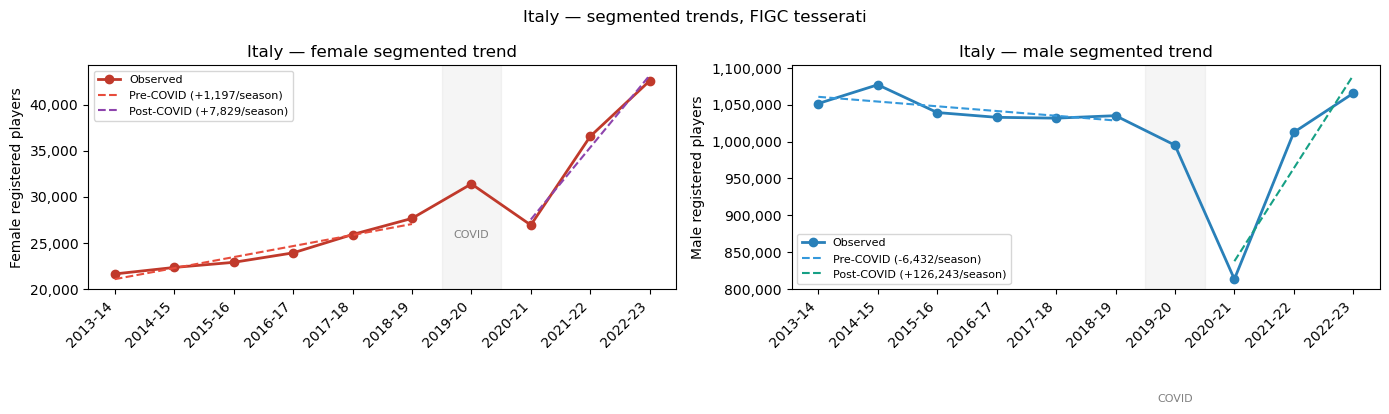

In [23]:
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, gender, color_obs, color_pre, color_post, label in [
    (axes[0], "female", "#c0392b", "#e74c3c", "#8e44ad", "Female"),
    (axes[1], "male",   "#2980b9", "#3498db", "#16a085", "Male"),
]:
    gs = figc_total[figc_total["gender"] == gender].set_index("season").reindex(seasons).reset_index()
    gs["t"] = range(len(gs))

    pre  = gs[gs["t"] <= 5]
    post = gs[gs["t"] >= 7]

    slope_pre,  intercept_pre,  r_pre,  *_ = stats.linregress(pre["t"],  pre["registered_players"])
    slope_post, intercept_post, r_post, *_ = stats.linregress(post["t"], post["registered_players"])

    print(f"{label}")
    print(f"  Pre-COVID  slope: {slope_pre:+,.0f} players/season  (R={r_pre:.3f})")
    print(f"  Post-COVID slope: {slope_post:+,.0f} players/season  (R={r_post:.3f})")

    x_pre  = np.linspace(pre["t"].min(),  pre["t"].max(),  100)
    x_post = np.linspace(post["t"].min(), post["t"].max(), 100)

    ax.plot(gs["t"], gs["registered_players"], color=color_obs, marker="o", linewidth=2, label="Observed")
    ax.plot(x_pre,  intercept_pre  + slope_pre  * x_pre,  color=color_pre,  linewidth=1.5, linestyle="--", label=f"Pre-COVID ({slope_pre:+,.0f}/season)")
    ax.plot(x_post, intercept_post + slope_post * x_post, color=color_post, linewidth=1.5, linestyle="--", label=f"Post-COVID ({slope_post:+,.0f}/season)")
    ax.axvspan(5.5, 6.5, alpha=0.08, color="grey")
    ax.text(6, gs["registered_players"].max() * 0.6, "COVID", ha="center", fontsize=8, color="grey")
    ax.set_xticks(gs["t"])
    ax.set_xticklabels(seasons, rotation=45, ha="right")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
    ax.set_ylabel(f"{label} registered players")
    ax.set_title(f"Italy — {label.lower()} segmented trend")
    ax.legend(fontsize=8)

plt.suptitle("Italy — segmented trends, FIGC tesserati", fontsize=12)
plt.tight_layout()
plt.show()



### What the segmented trends tell us


The segmented trends reveal a clear asymmetry between female and male participation in Italy, both in direction and in the nature of the COVID disruption.

**Female players** show the most consistent growth trajectory of any country examined so far. The pre-COVID slope is modest (approximately **+1,200 players per season**) but highly regular (R = 0.97), reflecting steady structural expansion from a small base. The post-COVID segment accelerates sharply to **+7,800 players per season**, a more than sixfold increase in growth rate. This acceleration is real and not simply a mechanical rebound: the 2021-22 figure already exceeds the pre-COVID peak, and 2022-23 extends the gain further.

**Male players** show a situation where the pre-COVID trend was slightly negative (approximately −6,400 per season), consistent with a mature, slowly contracting registration base (we saw a similar pattern in Germany and, to a lesser extent, France). The COVID shock was severe: registrations fell by roughly 180,000 in a single year, far larger in absolute terms than the female dip.

The post-COVID male slope appears very steep (+126,000 per season) but must be treated with caution: it is estimated from exactly two data points (2021-22 and 2022-23), and reflects a sharp recovery rebound rather than an established trend. Whether male registrations stabilise at the recovered level or resume their pre-COVID declining trajectory will only become clear with additional seasons of data.

The central finding remains the female series: Italy's women's football base is small but accelerating, and the post-COVID growth rate is the highest recorded in the FIGC data.


### Interrupted Time Series model on Italian data


Female
  β1 (trend):        +1,535  (p=0.001)
  β2 (level shift):  -3,709  (p=0.051)
  β3 (slope change): +6,294  (p=0.000)
  R²: 0.978

Male
  β1 (trend):        -9,332  (p=0.130)
  β2 (level shift):  -162,759  (p=0.004)
  β3 (slope change): +135,575  (p=0.001)
  R²: 0.906


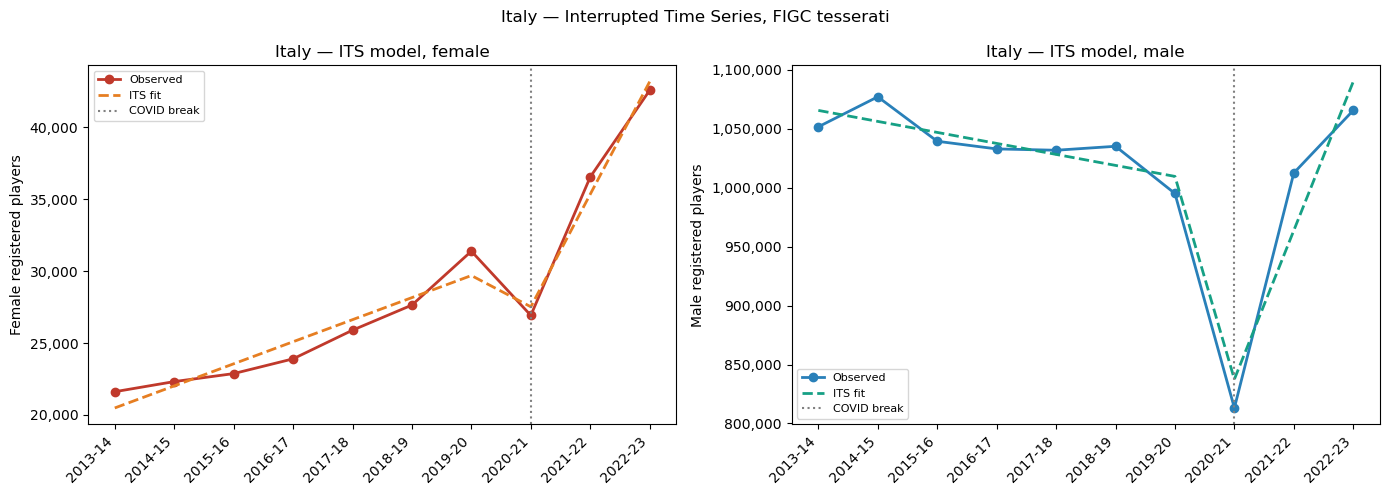

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.api as sm
import pandas as pd
from pathlib import Path

# data_dir = Path("../../data/processed")
# figc = pd.read_csv(data_dir / "figc_italy_primary.csv")

# seasons = figc["season"].unique()
# seasons = sorted(seasons)

# figc_total = figc[(figc["age_group"] == "total") & (figc["gender"].isin(["female", "male"]))].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

its_results = {}

for ax, gender, color_obs, color_fit, title in [
    (axes[0], "female", "#c0392b", "#e67e22", "Female"),
    (axes[1], "male",   "#2980b9", "#16a085", "Male"),
]:
    gs = figc_total[figc_total["gender"] == gender].set_index("season").reindex(seasons).reset_index()
    gs["t"] = range(len(gs))
    covid_break = list(seasons).index("2020-21")
    gs["D"] = (gs["t"] >= covid_break).astype(int)
    gs["t_post"] = (gs["t"] - covid_break) * gs["D"]

    X = sm.add_constant(gs[["t", "D", "t_post"]])
    y = gs["registered_players"]
    model = sm.OLS(y, X).fit()
    gs["fitted"] = model.fittedvalues
    its_results[gender] = model

    print(f"\n{'='*50}")
    print(f"{title}")
    print(f"  β1 (trend):        {model.params['t']:+,.0f}  (p={model.pvalues['t']:.3f})")
    print(f"  β2 (level shift):  {model.params['D']:+,.0f}  (p={model.pvalues['D']:.3f})")
    print(f"  β3 (slope change): {model.params['t_post']:+,.0f}  (p={model.pvalues['t_post']:.3f})")
    print(f"  R²: {model.rsquared:.3f}")

    ax.plot(gs["t"], gs["registered_players"], color=color_obs, marker="o", linewidth=2, label="Observed")
    ax.plot(gs["t"], gs["fitted"], color=color_fit, linewidth=2, linestyle="--", label="ITS fit")
    ax.axvline(covid_break, color="grey", linestyle=":", linewidth=1.5, label="COVID break")
    ax.set_xticks(gs["t"])
    ax.set_xticklabels(seasons, rotation=45, ha="right")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
    ax.set_ylabel(f"{title} registered players")
    ax.set_title(f"Italy — ITS model, {title.lower()}")
    ax.legend(fontsize=8)

plt.suptitle("Italy — Interrupted Time Series, FIGC tesserati", fontsize=12)
plt.tight_layout()
plt.show()


### What Interrupted Time Series shows for Italy

The ITS model applied to both genders confirms and sharpens the segmented trend findings, while adding precision on the nature of the COVID disruption.

**Female players** (R² = 0.978): the pre-COVID baseline trend is +1,535 players per season, again modest but statistically robust (p = 0.001). The COVID level shift is −3,709 players, borderline significant (p = 0.051), consistent with a relatively contained disruption on the female side. The slope change of +6,294 players per season (p < 0.001) represents the post-COVID acceleration, bringing the effective post-COVID growth rate to approximately **+7,800 players per season**: a fivefold increase over the pre-COVID pace.

**Male players** (R² = 0.906): the pre-COVID trend is slightly negative (−9,332 per season), though not statistically significant (p = 0.130), consistent with a broadly flat but slowly declining registration base. The COVID level shift is the dominant signal: −162,759 players in a single season (p = 0.004), a shock more than forty times larger in absolute terms than the female equivalent. The post-COVID slope change (+135,575 per season) reflects the sharp mechanical rebound visible in the chart, but this estimate rests on two data points only and should not be read as an established trend. The male series requires at least two more seasons before the post-COVID trajectory can be assessed with confidence.

The contrast between the two series captures Italy's structural situation precisely: *women's football is growing from a small base at an accelerating rate, while men's football is a large, mature system that absorbed a severe external shock and appears to have recovered, but whose underlying direction remains uncertain.*

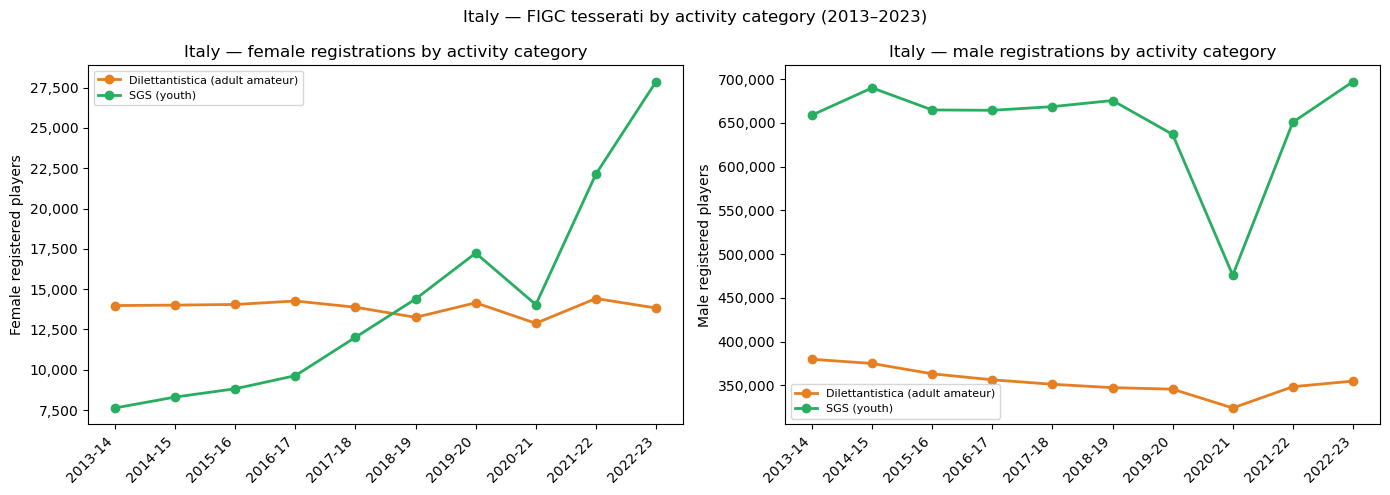

In [25]:
activity_cats = ["dilettantistica", "sgs"]
colors_act = {"dilettantistica": "#e67e22", "sgs": "#27ae60"}
labels_act  = {"dilettantistica": "Dilettantistica (adult amateur)", "sgs": "SGS (youth)"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, gender, title in [
    (axes[0], "female", "Female"),
    (axes[1], "male",   "Male"),
]:
    gdf = figc[(figc["gender"] == gender) & (figc["age_group"].isin(activity_cats))].copy()
    pivot = gdf.pivot(index="season", columns="age_group", values="registered_players").reindex(seasons)

    x = np.arange(len(seasons))
    for cat in activity_cats:
        ax.plot(x, pivot[cat].values, marker="o", linewidth=2,
                color=colors_act[cat], label=labels_act[cat])

    ax.set_xticks(x)
    ax.set_xticklabels(seasons, rotation=45, ha="right")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
    ax.set_ylabel(f"{title} registered players")
    ax.set_title(f"Italy — {title.lower()} registrations by activity category")
    ax.legend(fontsize=8)

plt.suptitle("Italy — FIGC tesserati by activity category (2013–2023)", fontsize=12)
plt.tight_layout()
plt.show()


### Where is Italy's female growth coming from?

The activity breakdown reveals a finding that the aggregate trend line conceals: **the growth in Italian women's football is entirely driven by the youth sector (SGS)**, not by adult amateur registrations.

The dilettantistica category (adult amateur football) has been essentially flat throughout the decade, hovering between 13,000 and 14,500 players in every season from 2013-14 to 2022-23. There is no meaningful trend in either direction. Adult female participation, as measured by FIGC licences, has not grown.

The SGS tells the opposite story. From 7,634 players in 2013-14, the youth sector reached 27,865 in 2022-23 with a 3.6-fold increase over a decade. The two lines crossed somewhere between 2018-19 and 2019-20, the point at which youth registrations overtook adult amateur registrations for the first time. The acceleration after 2020-21 is particularly sharp: the SGS added roughly 13,800 players in just two seasons, a pace without precedent in the earlier part of the series.

For male players, the structure is the inverse: SGS is the larger category (~650,000–700,000 players) and absorbed the bulk of the COVID shock, falling from 637,000 in 2019-20 to 476,000 in 2020-21 before recovering strongly. The dilettantistica category shows a slow but consistent decline across the decade, independent of COVID.

The youth pipeline finding has a direct structural implication: Italian women's football is recruiting effectively at the grassroots level, but those young players are not yet converting into adult registrations at scale. Whether the SGS cohorts of the late 2010s are transitioning into dilettantistica (or dropping out?) is the question the current data cannot answer but future editions will reveal.

A note on comparability: the SGS can be treated as the youth category and dilettantistica as the adult amateur category, making this breakdown broadly analogous to the youth/adult splits shown for France and Germany. The difference is granularity: we can identify the youth/adult split, but we cannot decompose it further into narrower age bands from the available FIGC data.


## England Data - Sport England Active Lives Survey

England's participation data comes from the **Active Lives Survey**, a large-scale household survey published by **Sport England**. The survey measures how often adults and children participate in sport and physical activity, and is conducted twice yearly, in May and November, across a representative sample of the English population. Football participation figures are derived from survey responses and scaled to population estimates, producing a modelled count of participants rather than a hard registration count.

The key output used here is **population_estimate**: the estimated number of individuals who played football at least once in the previous 28 days, scaled from the survey sample to the full English population. This is a fundamentally different metric from the registration counts used for France, Germany, Spain, and Italy. A *registration count* captures everyone holding an active licence, regardless of whether they actually played. A *survey-based participation count* captures everyone who recently played, regardless of whether they hold any formal affiliation. The two metrics overlap substantially but are not identical, and their relationship varies by country depending on the density of club-based participation.

The Active Lives dataset covers two distinct populations:

| Population | Age range | Survey instrument |
|---|---|---|
| **Adult** | 16 and over | Active Lives Adult Survey |
| **Children** | School years 1–11 (approx. ages 5–16) | Active Lives Children and Young People Survey |

Both populations are used in this analysis. The adult series is the primary trend indicator; the children's series provides the grassroots pipeline equivalent of the SGS (Italy) and youth age band data (France, Germany).


### Why Sport England and not the FA?

The natural equivalent of the RFEF, DFB, or FIGC registration data for England would be Football Association (FA) membership figures. The FA does publish aggregate registration numbers, but these are not consistently available in a gender-disaggregated, time-series format through any public-facing dataset or annual report equivalent to the French INJEP licences or the German DFB Mitgliederstatistik.

The FA has released occasional press releases and summary figures, including high-profile announcements around the growth of the women's game following the 2022 Euros, but these do not constitute a systematic, season-by-season breakdown by gender and age group comparable to the sources used for the other four countries.

Sport England's Active Lives Survey is therefore the only publicly available source for England that provides a consistent gender split for football participation over multiple years. This is not a methodological choice but a data availability constraint.

### Methodology caveats

Three issues affect the comparability of the England series across time and require explicit acknowledgement before reading any trend.

**1. Participation threshold change.** The Active Lives Survey changed its primary participation threshold between the 2018-19 and 2019-20 editions. Earlier waves defined participation as playing at least **twice** in the previous 28 days; from 2019-20 onward the threshold dropped to at least **once** in the previous 28 days. This change mechanically inflates the reported number of participants from 2019-20 onward relative to the earlier series: the same population will always show higher participation at a lower threshold. The two sub-series are retained in the raw data with the metric clearly flagged (`participation_twice_28days` vs `participation_once_28days`), but they are not directly comparable. For the trend analysis below, we use the `participation_once_28days` series only (2018-19 onward), which provides a consistent six-season window covering the pre-COVID, COVID, and post-COVID periods.

**2. Survey wave selection.** Sport England conducts the Active Lives Survey twice yearly, producing May and November waves. For years where both waves are available, we use the **November wave** as the primary observation. November waves are available for a longer and more consistent run of seasons, and align more naturally with the football season calendar (which runs August to May in England). Where a November wave is absent and a May wave exists, the May wave is used and flagged. Academic Year waves from the Children and Young People Survey are treated as annual observations and assigned to the corresponding season.

**3. Survey window and data coverage**. The federation data for France, Germany, Spain, and Italy covers seasons from 2013-14 onward, providing at least six pre-COVID seasons and a sufficiently long baseline to fit reliable trend models. The Active Lives Survey data used here begins in 2018-19, the earliest season for which consistent gender-disaggregated football figures are available on a comparable metric. This shorter window has two consequences that run through everything that follows. First, there is only one pre-COVID observation available, which makes it unreliable to estimate the pre-COVID trend: any slope fitted to a single point is indistinguishable from a level, so the segmented trend and ITS analyses for England focus on the post-COVID trajectory only. Second, when we reach the cross-country comparison, England enters the indexed chart at a later base year than the other four countries, requiring a separate stage of the analysis and a different interpretive frame.

### England gender trends in participation

In [26]:
IN_CSV = PROCESSED_DIR / "england_football_participation_raw.csv"
# eng = pd.read_csv(Path("../../data/raw/sport_england/england_football_participation_raw.csv"))
eng = pd.read_csv(IN_CSV)

eng_adult    = eng[eng["population"] == "adult"].copy()
eng_children = eng[eng["population"] != "adult"].copy()

eng_adult = eng_adult[eng_adult["metric"] == "participation_once_28days"].copy()

def parse_season(period):
    period = period.strip()
    # "November 2022 - November 2023" → end year is last token
    if period.startswith("November"):
        parts = period.split()
        year = int(parts[-1])
        return f"{year-1}-{str(year)[2:]}", "november"
    # "May 2020 - May 2021" → end year is last token
    elif period.startswith("May 20"):
        parts = period.split()
        year = int(parts[-1])
        return f"{year-1}-{str(year)[2:]}", "may"
    # "May 18-19" → last token is "18-19"
    elif period.startswith("May 18"):
        return "2018-19", "may"
    # "Academic Year 2022-23" → last token is the season
    elif period.startswith("Academic"):
        parts = period.split()
        return parts[-1], "academic"
    return None, None

seasons_waves = [parse_season(p) for p in eng_adult["survey_period"]]
eng_adult["season"] = [sw[0] for sw in seasons_waves]
eng_adult["wave"]   = [sw[1] for sw in seasons_waves]

eng_adult = eng_adult.dropna(subset=["season"])

# Keep November preferentially, fall back to May
eng_adult = eng_adult.sort_values("wave")
eng_adult = eng_adult.drop_duplicates(subset=["season", "gender"], keep="last")
eng_adult = eng_adult.sort_values("season")

#print(eng_adult[["season", "wave", "gender", "population_estimate", "metric"]].to_string(index=False))
print("\nSeasons covered:", sorted(eng_adult["season"].unique()))



Seasons covered: ['2018-19', '2019-20', '2020-21', '2021-22', '2022-23', '2023-24', '2024-25']


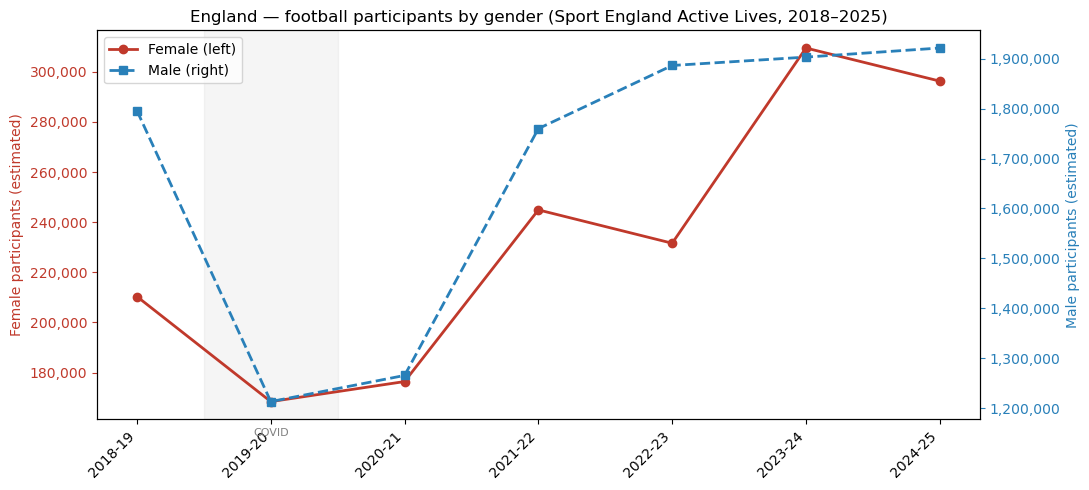

Female: [210300 168400 176400 244900 231600 309500 296300]
Male:   [1795400 1213200 1265600 1759900 1886300 1903100 1921300]


In [27]:
eng_seasons = sorted(eng_adult["season"].unique())
x = np.arange(len(eng_seasons))

female = eng_adult[eng_adult["gender"] == "female"].set_index("season").reindex(eng_seasons)["population_estimate"]
male   = eng_adult[eng_adult["gender"] == "male"].set_index("season").reindex(eng_seasons)["population_estimate"]

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

ax1.plot(x, female.values, color="#c0392b", marker="o", linewidth=2, label="Female (left)")
ax2.plot(x, male.values,   color="#2980b9", marker="s", linewidth=2, linestyle="--", label="Male (right)")

ax1.set_xticks(x)
ax1.set_xticklabels(eng_seasons, rotation=45, ha="right")
ax1.set_ylabel("Female participants (estimated)", color="#c0392b")
ax2.set_ylabel("Male participants (estimated)", color="#2980b9")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax1.tick_params(axis="y", colors="#c0392b")
ax2.tick_params(axis="y", colors="#2980b9")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.set_title("England — football participants by gender (Sport England Active Lives, 2018–2025)")
ax1.axvspan(0.5, 1.5, alpha=0.08, color="grey")
ax1.text(1, female.max() * 0.5, "COVID", ha="center", fontsize=8, color="grey")

plt.tight_layout()
plt.show()

print("Female:", female.values)
print("Male:  ", male.values)


The Active Lives data covers seven seasons (2018-19 to 2024-25), a shorter window than the registration series available for France, Germany, Spain, and Italy. The pre-COVID baseline consists of a single observation (2018-19), which means trend decomposition must be interpreted with particular caution for England.

Within this constraint, the data shows a clear pattern for both genders.

**Female participants** stood at an estimated 210,300 in 2018-19, fell sharply during the COVID seasons (168,400 in 2019-20 and 176,400 in 2020-21), then recovered and accelerated strongly: 244,900 in 2021-22, a slight dip to 231,600 in 2022-23, and a new peak of 309,500 in 2023-24 before settling at 296,300 in 2024-25. The 2023-24 peak coincides with the sustained visibility effect of England's UEFA Women's Euro 2022 victory and the subsequent growth of the Women's Super League audience. The overall increase from 2018-19 to 2024-25 is approximately **+41%**.

**Male participants** show a more pronounced COVID shock, falling from 1,795,400 in 2018-19 to 1,213,200 in 2019-20, the sharpest single-season drop in the dataset and followed by a strong and sustained recovery. By 2022-23 male participation had returned to near pre-COVID levels, and by 2024-25 it reached 1,921,300, a new high for the series. The overall increase from 2018-19 to 2024-25 is approximately **+7%**, substantially lower than the female growth rate.

The asymmetry between female and male growth rates mirrors the pattern observed in Italy, Spain, and France: women's football participation is growing faster in relative terms across all five countries, from a lower base.

### Segmented Trend Analysis for England Data

Female
  Post-COVID slope: +23,210 participants/season  (R=0.786)
  Note: pre-COVID segment has only 1 data point — no trend line fitted
Male
  Post-COVID slope: +50,100 participants/season  (R=0.883)
  Note: pre-COVID segment has only 1 data point — no trend line fitted


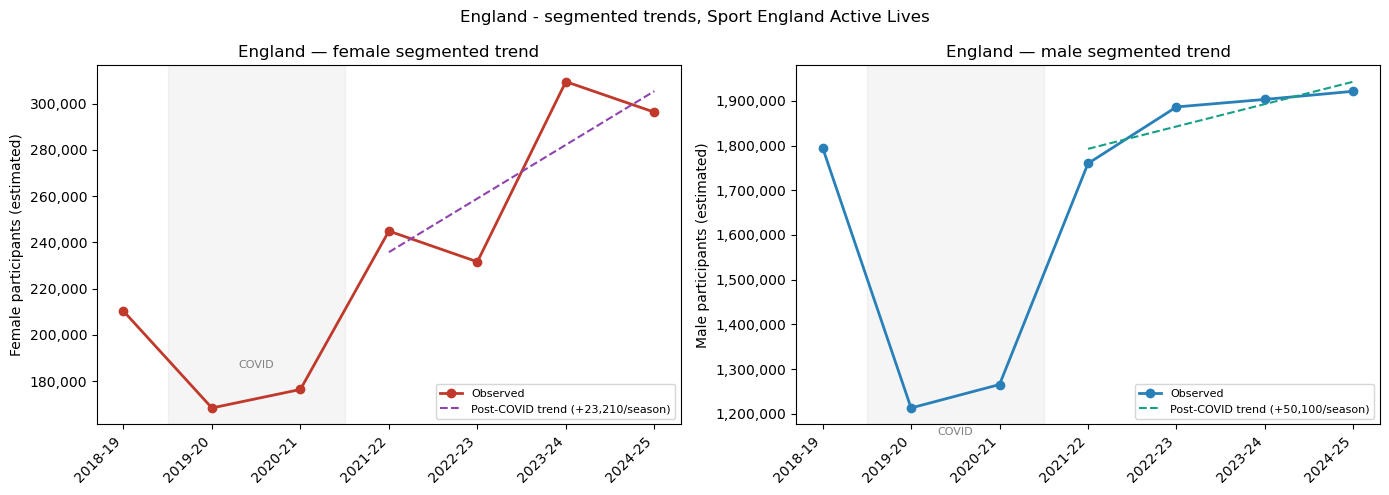

In [28]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# COVID seasons: 2019-20 and 2020-21 excluded from trend fitting
# Pre-COVID: 2018-19 only (1 point — cannot fit a line, note limitation)
# Post-COVID: 2021-22 onward (4 points)

eng_seasons_list = sorted(eng_adult["season"].unique())

for ax, gender, color_obs, color_post, title in [
    (axes[0], "female", "#c0392b", "#8e44ad", "Female"),
    (axes[1], "male",   "#2980b9", "#16a085", "Male"),
]:
    gs = eng_adult[eng_adult["gender"] == gender].set_index("season").reindex(eng_seasons_list).reset_index()
    gs["t"] = range(len(gs))

    post = gs[gs["season"].isin(["2021-22", "2022-23", "2023-24", "2024-25"])]

    slope_post, intercept_post, r_post, *_ = stats.linregress(post["t"], post["population_estimate"])

    print(f"{title}")
    print(f"  Post-COVID slope: {slope_post:+,.0f} participants/season  (R={r_post:.3f})")
    print(f"  Note: pre-COVID segment has only 1 data point — no trend line fitted")

    x_post = np.linspace(post["t"].min(), post["t"].max(), 100)

    ax.plot(gs["t"], gs["population_estimate"], color=color_obs, marker="o", linewidth=2, label="Observed")
    ax.plot(x_post, intercept_post + slope_post * x_post, color=color_post, linewidth=1.5, linestyle="--", label=f"Post-COVID trend ({slope_post:+,.0f}/season)")
    ax.axvspan(0.5, 2.5, alpha=0.08, color="grey")
    ax.text(1.5, gs["population_estimate"].max() * 0.6, "COVID", ha="center", fontsize=8, color="grey")
    ax.set_xticks(gs["t"])
    ax.set_xticklabels(eng_seasons_list, rotation=45, ha="right")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
    ax.set_ylabel(f"{title} participants (estimated)")
    ax.set_title(f"England — {title.lower()} segmented trend")
    ax.legend(fontsize=8)

plt.suptitle("England - segmented trends, Sport England Active Lives", fontsize=12)
plt.tight_layout()
plt.show()


### What the segmented trends tell us

The short series available for England with a single pre-COVID observation in 2018-19 and four post-COVID seasons from 2021-22, means that a pre-COVID trend cannot be estimated. The analysis focuses on the post-COVID trajectory only.

**Female participants** show a post-COVID slope of approximately **+23,200 participants per season**, but the fit is moderate (R = 0.786), reflecting the non-linear shape of the recovery. The 2021-22 and 2022-23 seasons show a step up from the COVID trough, but the sharpest jump occurs between 2022-23 and 2023-24 (from 231,600 to 309,500) before settling back to 296,300 in 2024-25. This pattern is more consistent with a discrete visibility shock (the UEFA Women's Euro 2022 victory in the summer of 2022, with its participation effects materialising in the 2023-24 survey year) than with a steady linear trend. A linear slope is a simplification here; the underlying dynamic is a step change followed by partial consolidation.

**Male participants** show a steadier post-COVID recovery with a slope of approximately **+50,100 participants per season** (R = 0.883). The series is less volatile than the female one, consistent with a large and structurally stable base returning to pre-COVID levels and then continuing to grow modestly. By 2024-25 male participation reached 1,921,300 representing the highest figure in the series.

Both series are too short to distinguish structural acceleration from post-COVID rebound with confidence. The 2025-26 and 2026-27 editions will be the first real test of whether the post-Euros female participation gain is durable.


### Interrupted Time Series analysis for England Data


Female
  β1 (trend):        -5,467  (p=0.573)
  β2 (level shift):  -40,233  (p=0.119)
  β3 (slope change): +34,767  (p=0.044)
  R²: 0.876

Male
  β1 (trend):        -125,428  (p=0.103)
  β2 (level shift):  -410,267  (p=0.039)
  β3 (slope change): +284,839  (p=0.024)
  R²: 0.823


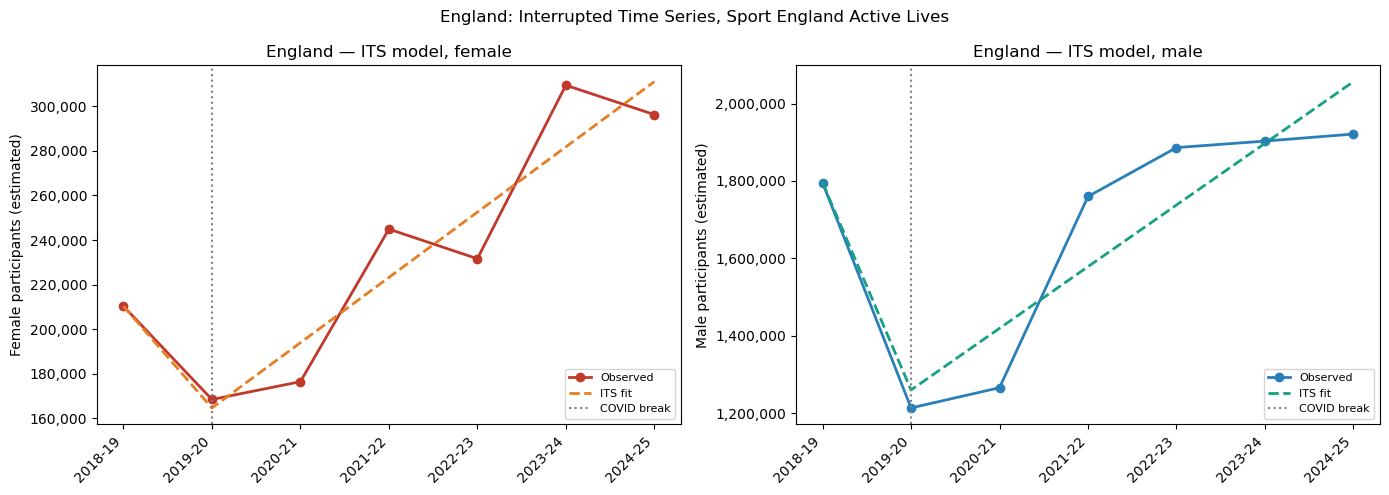

In [29]:
import statsmodels.api as sm

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# COVID break at 2019-20 (index 1)
covid_break = eng_seasons_list.index("2019-20")

for ax, gender, color_obs, color_fit, title in [
    (axes[0], "female", "#c0392b", "#e67e22", "Female"),
    (axes[1], "male",   "#2980b9", "#16a085", "Male"),
]:
    gs = eng_adult[eng_adult["gender"] == gender].set_index("season").reindex(eng_seasons_list).reset_index()
    gs["t"] = range(len(gs))
    gs["D"] = (gs["t"] >= covid_break).astype(int)
    gs["t_post"] = (gs["t"] - covid_break) * gs["D"]

    X = sm.add_constant(gs[["t", "D", "t_post"]])
    y = gs["population_estimate"]
    model = sm.OLS(y, X).fit()
    gs["fitted"] = model.fittedvalues

    print(f"\n{'='*50}")
    print(f"{title}")
    print(f"  β1 (trend):        {model.params['t']:+,.0f}  (p={model.pvalues['t']:.3f})")
    print(f"  β2 (level shift):  {model.params['D']:+,.0f}  (p={model.pvalues['D']:.3f})")
    print(f"  β3 (slope change): {model.params['t_post']:+,.0f}  (p={model.pvalues['t_post']:.3f})")
    print(f"  R²: {model.rsquared:.3f}")

    ax.plot(gs["t"], gs["population_estimate"], color=color_obs, marker="o", linewidth=2, label="Observed")
    ax.plot(gs["t"], gs["fitted"], color=color_fit, linewidth=2, linestyle="--", label="ITS fit")
    ax.axvline(covid_break, color="grey", linestyle=":", linewidth=1.5, label="COVID break")
    ax.set_xticks(gs["t"])
    ax.set_xticklabels(eng_seasons_list, rotation=45, ha="right")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
    ax.set_ylabel(f"{title} participants (estimated)")
    ax.set_title(f"England — ITS model, {title.lower()}")
    ax.legend(fontsize=8)

plt.suptitle("England: Interrupted Time Series, Sport England Active Lives", fontsize=12)
plt.tight_layout()
plt.show()

#### What ITS tells us about England Data

The ITS model for England must be interpreted with greater caution than for the other four countries. With only one pre-COVID observation (2018-19), the model cannot reliably separate the baseline trend ($\beta_{1}$) from the COVID level shift ($\beta_{2}$): both parameters are estimated from too little pre-intervention data and neither reaches conventional significance for female players. The post-COVID slope change ($\beta_{3}$) is the only coefficient with sufficient data behind it, and it is the one worth reading.

**Female participants** ($R^{2}$ = 0.876): $\beta_{3}$ = +34,767 participants per season (p = 0.044), representing the post-COVID acceleration. The pre-COVID trend ($\beta_{1}$ = −5,467) and level shift ($\beta_{2}$ = −40,233) are not statistically significant and should not be interpreted individually and  they can be interpreted as artefacts of the single-point pre-COVID baseline. The effective post-COVID growth rate implied by the model is approximately **+29,300 participants per season** ($\beta_{1}$ + $\beta_{3}$), though again this rests on a short window and is sensitive to the 2022-23 dip and 2023-24 spike in the observed series.

**Male participants** ($R^{2}$ = 0.823): $\beta_{3}$ = +284,839 participants per season (p = 0.024). The COVID level shift is large and significant ($\beta_{2}$ = −410,267, p = 0.039), consistent with the severe drop visible in the chart. As with the female series, the pre-COVID baseline trend ($\beta_{1}$) is not reliable given the single observation. The post-COVID recovery is real and sustained, but the model fit diverges from the observed series in the later seasons, suggesting the male recovery is decelerating while the fitted line continues to rise.

The England ITS results are best read as directional signals rather than precise estimates. The structural limitation means that England will require several more seasons of data before trend decomposition reaches the reliability achieved for France, Germany, Spain, and Italy.

### Children and young people's football participation

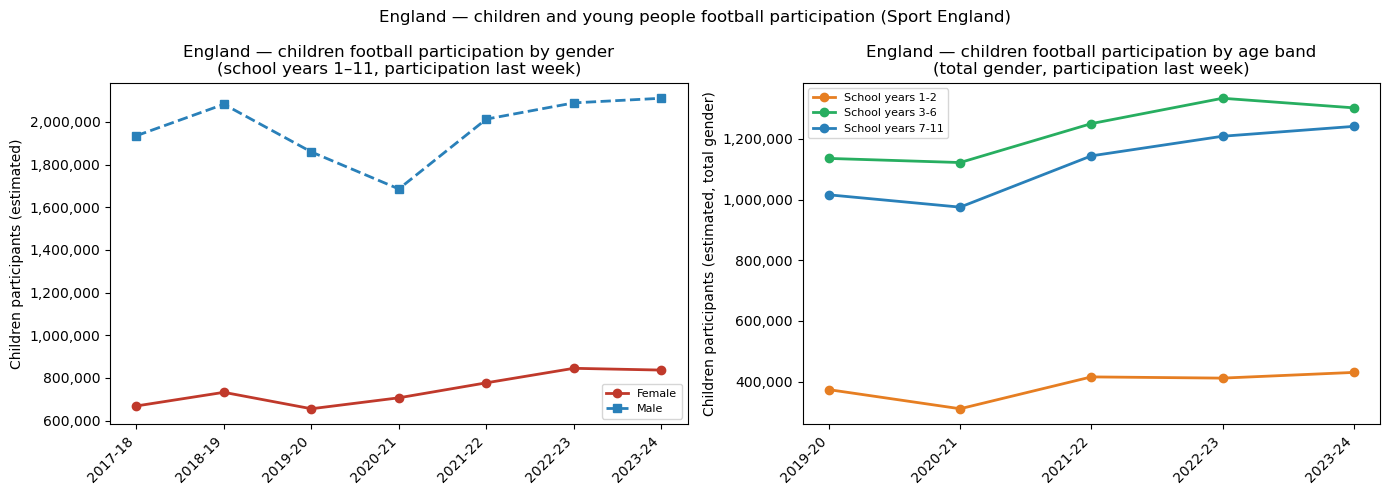


Female children: [669000 732900 655900 707200 777400 845400 837084]
Male children:   [1935100 2082500 1859100 1685800 2012900 2089000 2110615]


In [30]:
child_seasons = sorted(eng_children[eng_children["age_group"] == "years 1-11"]["survey_period"].unique())
child_season_labels = [s.replace("Academic Year ", "") for s in child_seasons]

child_total = eng_children[eng_children["age_group"] == "years 1-11"].copy()

female_c = child_total[child_total["gender"] == "female"].set_index("survey_period").reindex(child_seasons)["population_estimate"]
male_c   = child_total[child_total["gender"] == "male"].set_index("survey_period").reindex(child_seasons)["population_estimate"]

# Age sub-bands — total gender only
band_seasons = sorted(eng_children[eng_children["age_group"] == "school years 1-2"]["survey_period"].unique())
band_labels  = [s.replace("Academic Year ", "") for s in band_seasons]
bands = ["school years 1-2", "school years 3-6", "school years 7-11"]
band_colors = {"school years 1-2": "#e67e22", "school years 3-6": "#27ae60", "school years 7-11": "#2980b9"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: gender trend
x_c = np.arange(len(child_seasons))
axes[0].plot(x_c, female_c.values, color="#c0392b", marker="o", linewidth=2, label="Female")
axes[0].plot(x_c, male_c.values,   color="#2980b9", marker="s", linewidth=2, linestyle="--", label="Male")
axes[0].set_xticks(x_c)
axes[0].set_xticklabels(child_season_labels, rotation=45, ha="right")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
axes[0].set_ylabel("Children participants (estimated)")
axes[0].set_title("England — children football participation by gender\n(school years 1–11, participation last week)")
axes[0].legend(fontsize=8)

# Right: age sub-bands (total)
x_b = np.arange(len(band_seasons))
for band in bands:
    vals = eng_children[(eng_children["age_group"] == band) & (eng_children["gender"] == "total")].set_index("survey_period").reindex(band_seasons)["population_estimate"]
    axes[1].plot(x_b, vals.values, marker="o", linewidth=2, color=band_colors[band], label=band.capitalize())
axes[1].set_xticks(x_b)
axes[1].set_xticklabels(band_labels, rotation=45, ha="right")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
axes[1].set_ylabel("Children participants (estimated, total gender)")
axes[1].set_title("England — children football participation by age band\n(total gender, participation last week)")
axes[1].legend(fontsize=8)

plt.suptitle("England — children and young people football participation (Sport England)", fontsize=12)
plt.tight_layout()
plt.show()

print("\nFemale children:", female_c.values)
print("Male children:  ", male_c.values)


The Active Lives Children and Young People Survey provides a parallel participation series for school-age players (years 1–11, approximately ages 5–16), measured as participation at least once in the previous week. This series uses a different reference window from the adult survey (last week vs last 28 days) and the two are not directly comparable in absolute terms, but the children's series is the closest English equivalent to the SGS data available for Italy or the youth age bands available for France and Germany.

**Female children** show a consistent upward trend over the seven seasons available (2017-18 to 2023-24), growing from 669,000 to 837,000 with an increase of approximately 25%. The COVID disruption is visible but relatively contained: female children's participation dipped in 2019-20 and 2020-21 but recovered quickly, and the series reached its peak in 2022-23 (845,400) before a marginal decline in 2023-24. The trend is more stable than the adult female series, suggesting that grassroots recruitment of girls into football has been growing steadily regardless of the visibility shocks that affected adult participation.

**Male children** show greater volatility. The COVID dip in 2020-21 was severe and participation fell from 1,859,100 in 2019-20 to 1,685,800, a drop of roughly 170,000, before recovering strongly to above pre-COVID levels by 2021-22 and reaching 2,110,615 by 2023-24.

The age band breakdown (total gender, 2019-20 to 2023-24) shows that school years 3–6 is the largest participation group, consistently above 1.1 million, followed by years 7–11 and then years 1–2. All three bands show post-COVID recovery and modest growth, with no single age group driving the trend disproportionately.

The children's data for England points to a ***structurally healthy grassroots pipeline for girls***, growing steadily over seven seasons, though the gap between female and male children's participation remains large in absolute terms (roughly 1 female participant for every 2.5 male participants).


## Cross-country comparison: female participation trends

Comparing women's football participation across five countries with different data collection methodologies is not straightforward. Germany counts club memberships; France, Spain, and Italy count registered playing licences; England estimates participation through a household survey. Placing these five series on the same axis and reading the absolute numbers would be misleading. For example, a German Mitglied and a French licenciée are not the same thing, and an English survey respondent is something different again.

What we can compare is **how fast each country is growing relative to its own starting point**. If we set each country's female participation figure to 100 at a common base year, the subsequent values tell us how much has changed with a value of 150 means participation is 50% above the base year level, regardless of the absolute scale. This approach, known as *indexing*, removes the level differences that reflect methodology and history, and leaves only the growth trajectory.

We use this approach in two stages. **Stage 1** covers the four countries for which we have data from at least 2013-14: France, Germany, Italy, and Spain. The base year is 2014-15, i.e. the earliest season where all four have confirmed figures. Seasons before 2014-15 are shown where available, with values below 100 indicating that participation was lower than the base year level. **Stage 2** adds England from 2018-19, the earliest season where consistent survey data is available, and resets all five countries to 100 at that point.

Once we have established the growth picture, we ask a second question: **does the size of each country's female population affect the comparison?** A country with 30 million women growing by 10,000 players is achieving a different penetration rate than a country with 65 million women achieving the same absolute gain. We address this by expressing female participation as *a share of the female population* (a participation rate) and applying the same indexing approach. This answers both a methodological question (does normalisation change who is growing fastest?) and a substantive one (what proportion of the female population plays football in each country?).

In [31]:
import pandas as pd
import numpy as np
from pathlib import Path

data_dir = PROCESSED_DIR

country_colors = {
    "France":  "#3498db",
    "Germany": "#e67e22",
    "Italy":   "#c0392b",
    "Spain":   "#f1c40f",
    "England": "#27ae60",
}
tier1_countries = ["France", "Germany", "Italy", "Spain"]

# --- Load federation CSVs ---
france  = pd.read_csv(data_dir / "injep_france_football_licences.csv")
germany = pd.read_csv(data_dir / "dfb_germany_mitglieder.csv")
spain   = pd.read_csv(data_dir / "rfef_spain_football_licences.csv")
italy   = pd.read_csv(data_dir / "figc_italy_primary.csv")

france_f  = france[(france["gender"]=="female") & (france["age_group"]=="total")][["season","registered_players"]].copy()
france_f["country"] = "France"

germany_f = germany[germany["gender"]=="female"].groupby("season")["registered_players"].sum().reset_index()
germany_f["season"] = germany_f["season"].apply(lambda y: f"{y-1}-{str(y)[2:]}")
germany_f["country"] = "Germany"

spain_f   = spain[(spain["gender"]=="female") & (spain["sport"]=="football")][["season","registered_players"]].copy()
spain_f["country"] = "Spain"

italy_f   = italy[(italy["gender"]=="female") & (italy["age_group"]=="total")][["season","registered_players"]].copy()
italy_f["country"] = "Italy"

eng_f = eng_adult[eng_adult["gender"]=="female"][["season","population_estimate"]].copy()
eng_f = eng_f.rename(columns={"population_estimate":"registered_players"})
eng_f["country"] = "England"

combined = pd.concat([france_f, germany_f, spain_f, italy_f, eng_f], ignore_index=True)
combined = combined.rename(columns={"registered_players":"female_total"})
combined = combined.sort_values(["country","season"])

# --- Tier 1: 4 countries, base 2014-15 ---
tier1 = combined[combined["country"].isin(tier1_countries)].copy()
base_t1 = tier1[tier1["season"]=="2014-15"].set_index("country")["female_total"]
tier1["index"] = tier1.apply(lambda r: r["female_total"] / base_t1[r["country"]] * 100, axis=1)

# --- Tier 2: 5 countries, base 2018-19 ---
tier2 = combined[combined["season"] >= "2018-19"].copy()
base_t2 = tier2[tier2["season"]=="2018-19"].set_index("country")["female_total"]
tier2["index"] = tier2.apply(lambda r: r["female_total"] / base_t2[r["country"]] * 100, axis=1)

# --- Population data ---
wb = pd.read_csv(Path(PROCESSED_DIR / "world_bank_raw.csv"))
pop_total  = wb[wb["indicator_name"]=="population_total"][["country_code","year","value"]].rename(columns={"value":"pop_total"})
pop_female = wb[wb["indicator_name"]=="female_pop_pct"][["country_code","year","value"]].rename(columns={"value":"female_pct"})
pop = pop_total.merge(pop_female, on=["country_code","year"])
pop["female_pop"] = pop["pop_total"] * pop["female_pct"] / 100
code_map = {"DEU":"Germany","ESP":"Spain","FRA":"France","GBR":"England","ITA":"Italy"}
pop["country"] = pop["country_code"].map(code_map)
pop = pop[pop["country"].notna()]

def season_to_year(season):
    return int("20" + season.split("-")[1])

def add_rate(df):
    rows = []
    for _, r in df.iterrows():
        try:
            year = season_to_year(r["season"])
        except:
            continue
        p = pop[(pop["country"]==r["country"]) & (pop["year"]==year)]
        if p.empty:
            continue
        rows.append({**r.to_dict(), "rate_pct": r["female_total"] / p["female_pop"].values[0] * 100})
    return pd.DataFrame(rows)

tier1_rate = add_rate(tier1)
tier2_rate = add_rate(tier2)

# --- Rate index: tier 1 base 2014-15, tier 2 base 2018-19 ---
base_rate_t1 = tier1_rate[tier1_rate["season"]=="2014-15"].set_index("country")["rate_pct"]
tier1_rate["rate_index"] = tier1_rate.apply(lambda r: r["rate_pct"] / base_rate_t1[r["country"]] * 100, axis=1)

base_rate_t2 = tier2_rate[tier2_rate["season"]=="2018-19"].set_index("country")["rate_pct"]
tier2_rate["rate_index"] = tier2_rate.apply(lambda r: r["rate_pct"] / base_rate_t2[r["country"]] * 100, axis=1)

print("Tier 1 seasons:", sorted(tier1["season"].unique()))
print("Tier 2 seasons:", sorted(tier2["season"].unique()))
print("\nBase values 2014-15:")
print(base_t1)
print("\nBase values 2018-19:")
print(base_t2)
print("\nParticipation rates 2022-23 (% of female population):")
print(tier1_rate[tier1_rate["season"]=="2022-23"][["country","female_total","rate_pct"]].to_string(index=False))


Tier 1 seasons: ['2013-14', '2014-15', '2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23', '2023-24', '2024-25']
Tier 2 seasons: ['2018-19', '2019-20', '2020-21', '2021-22', '2022-23', '2023-24', '2024-25']

Base values 2014-15:
country
France      119722
Germany    1094905
Italy        22321
Spain        29904
Name: female_total, dtype: int64

Base values 2018-19:
country
England     210300
France      184541
Germany    1115785
Italy        27644
Spain        47670
Name: female_total, dtype: int64

Participation rates 2022-23 (% of female population):
country  female_total  rate_pct
 France        225895  0.641148
Germany       1171785  2.779110
  Italy         42582  0.141124
  Spain         79718  0.323904


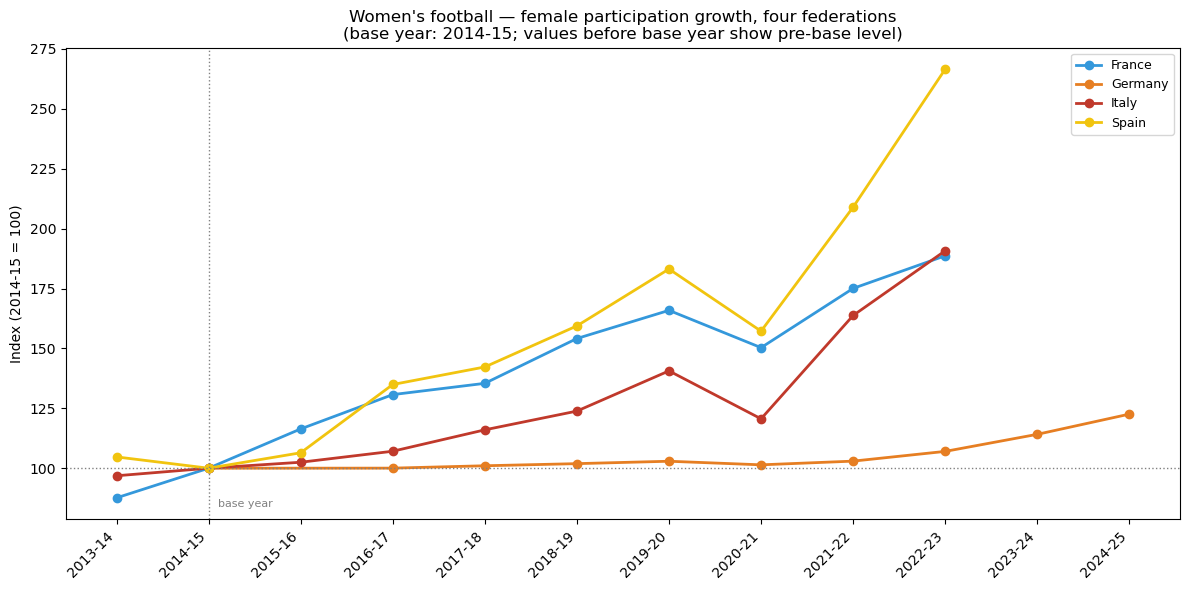


Index values by country and season:
country  France  Germany  Italy  Spain
season                                
2013-14    87.6      NaN   96.8  104.7
2014-15   100.0    100.0  100.0  100.0
2015-16   116.4      NaN  102.5  106.4
2016-17   130.7    100.0  107.1  134.9
2017-18   135.4    101.0  116.0  142.3
2018-19   154.1    101.9  123.8  159.4
2019-20   165.9    102.9  140.6  183.2
2020-21   150.3    101.4  120.6  157.2
2021-22   175.1    103.0  163.8  209.0
2022-23   188.7    107.0  190.8  266.6
2023-24     NaN    114.1    NaN    NaN
2024-25     NaN    122.6    NaN    NaN


In [32]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(12, 6))

tier1_seasons = sorted(tier1["season"].unique())
x_map = {s: i for i, s in enumerate(tier1_seasons)}

for country in tier1_countries:
    df = tier1[tier1["country"] == country].sort_values("season")
    x = [x_map[s] for s in df["season"]]
    ax.plot(x, df["index"].values, marker="o", linewidth=2,
            color=country_colors[country], label=country)

# Mark base year
base_x = x_map["2014-15"]
ax.axvline(base_x, color="grey", linestyle=":", linewidth=1)
ax.text(base_x + 0.1, ax.get_ylim()[0] + 5 if ax.get_ylim()[0] > 0 else 5,
        "base year", fontsize=8, color="grey")
ax.axhline(100, color="grey", linestyle=":", linewidth=1)

ax.set_xticks(range(len(tier1_seasons)))
ax.set_xticklabels(tier1_seasons, rotation=45, ha="right")
ax.set_ylabel("Index (2014-15 = 100)")
ax.set_title("Women's football — female participation growth, four federations\n(base year: 2014-15; values before base year show pre-base level)")
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}"))

plt.tight_layout()
plt.show()

print("\nIndex values by country and season:")
print(tier1.pivot(index="season", columns="country", values="index").round(1).to_string())


### Stage 1: Four federations, long series (2013-14 to 2024-25)

The chart above indexes female participation in France, Germany, Italy, and Spain to a common base year of 2014-15, the earliest season for which all four countries have confirmed data. A value of 100 represents each country's own participation level in that base year and the chart measures growth relative to each country's starting point, not relative to other countries. Values before 2014-15 are shown where available and indicate that participation was lower (below 100) or higher (above 100) than the base year level.

Four distinct trajectories emerge.

**Germany** is the outlier in the most revealing way: its index barely moves across a decade. From 100 in 2014-15 it reaches only 107 by 2022-23, and 123 by 2024-25: the slowest growth of any country in the series. This is not a failure; it reflects a system that was already operating at a high participation rate before the period begins. Germany entered 2014-15 with over one million female club members, a base built on decades of federation investment and competitive success. The growth headroom simply does not exist in the same form as for the other three countries.

**France** shows the most consistent growth trajectory: a steady climb from 100 in 2014-15 to 189 by 2022-23, nearly doubling its female participation base over eight seasons. There are no sharp inflection points: the French growth is structural and cumulative, driven by sustained federation investment and the expansion of D1 Arkema as a visible professional league. The COVID dip in 2020-21 (index falling to 150) is the only interruption, and the recovery is rapid.

**Italy** tracks France closely through most of the period, then accelerates sharply after the COVID disruption. The two countries are at nearly identical index values in 2019-20 (France 166, Italy 141) but diverge dramatically afterwards: Italy reaches 191 by 2022-23, fractionally overtaking France (189) for the first time. This is a notable finding: Italy, starting from a considerably smaller absolute base, is now growing at a faster pace than France in relative terms. Whether this acceleration is durable or reflects a one-time structural adjustment following Serie A Femminile's professionalisation in 2022-23 is the open question the next seasons will answer.

**Spain** is in a category of its own. From 100 in 2014-15 the index reaches 267 by 2022-23 nearly tripling the female participation base in eight seasons. The acceleration is concentrated in two phases: a first step up between 2016-17 and 2019-20 (index rising from 135 to 183), and a second, steeper acceleration from 2021-22 onward (reaching 209 in 2021-22 and 267 in 2022-23). The second phase coincides with Liga F professionalisation, the Barcelona Femení Champions League titles, and the 2023 FIFA Women's World Cup victory.

The pre-base year data point (2013-14) is available for France, Italy, and Spain. France was 12% below its 2014-15 level (index 88), Italy was marginally below (index 97), and Spain was marginally above (index 105), suggesting Spain had already begun its growth trajectory before the period covered by this chart, while France and Italy were still at an earlier stage of development.

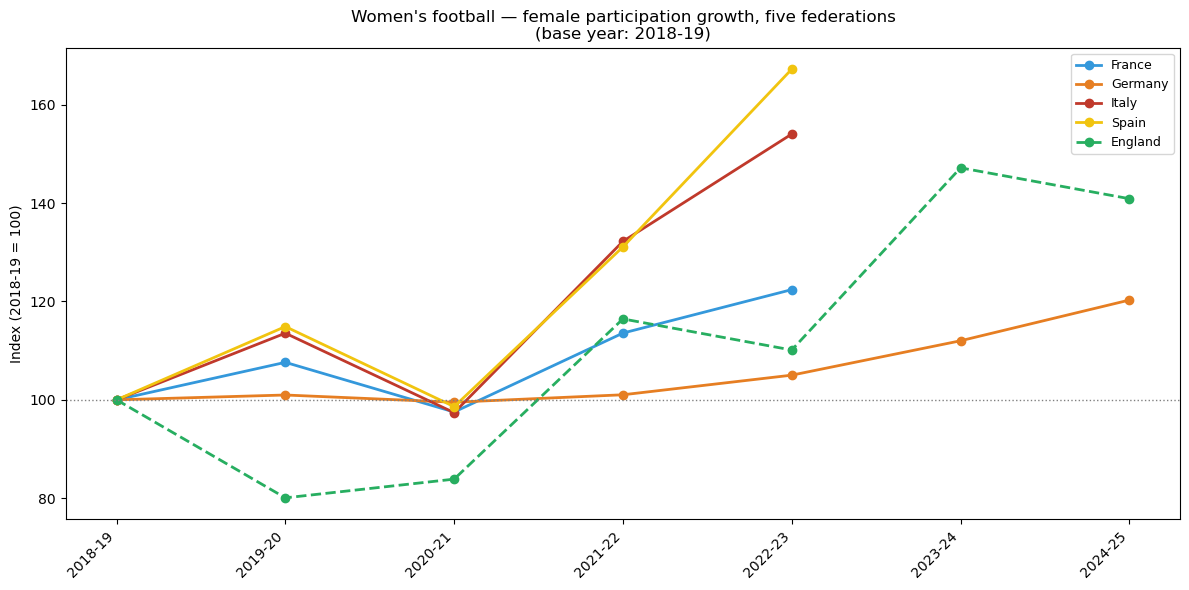


Index values by country and season:
country  England  France  Germany  Italy  Spain
season                                         
2018-19    100.0   100.0    100.0  100.0  100.0
2019-20     80.1   107.6    101.0  113.6  114.9
2020-21     83.9    97.5     99.5   97.4   98.6
2021-22    116.5   113.6    101.0  132.2  131.1
2022-23    110.1   122.4    105.0  154.0  167.2
2023-24    147.2     NaN    112.0    NaN    NaN
2024-25    140.9     NaN    120.3    NaN    NaN


In [33]:
fig, ax = plt.subplots(figsize=(12, 6))

tier2_seasons = sorted(tier2["season"].unique())
x_map2 = {s: i for i, s in enumerate(tier2_seasons)}

for country in ["France", "Germany", "Italy", "Spain", "England"]:
    df = tier2[tier2["country"] == country].sort_values("season")
    x = [x_map2[s] for s in df["season"]]
    ax.plot(x, df["index"].values, marker="o", linewidth=2,
            color=country_colors[country], label=country,
            linestyle="--" if country == "England" else "-")

ax.axhline(100, color="grey", linestyle=":", linewidth=1)
ax.set_xticks(range(len(tier2_seasons)))
ax.set_xticklabels(tier2_seasons, rotation=45, ha="right")
ax.set_ylabel("Index (2018-19 = 100)")
ax.set_title("Women's football — female participation growth, five federations\n(base year: 2018-19)")
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}"))

plt.tight_layout()
plt.show()

print("\nIndex values by country and season:")
print(tier2.pivot(index="season", columns="country", values="index").round(1).to_string())


### Stage 2: Five federations, from 2018-19

Adding England to the comparison requires resetting the base year to 2018-19, the earliest season for which consistent Active Lives survey data is available. All five countries start at 100 in 2018-19; the subsequent values show growth relative to that common starting point. England is shown with a dashed line to signal that its figures come from a survey rather than a registration count.

The five-country picture confirms the Stage 1 findings for France, Germany, Italy, and Spain, and adds three new observations.

**England's COVID shock is the deepest of the five countries.** The index falls to 80 in 2019-20, a 20% drop in a single season, far below any of the registration-based countries, none of which fell below 97. This reflects the survey methodology: Active Lives measures actual playing activity in the previous 28 days, which collapsed almost entirely during lockdown. Registration counts, by contrast, reflect formal affiliation and were suppressed but not eliminated. The two methodologies respond differently to the same shock, and the England series should be read with this in mind.

**Spain and Italy move in near-lockstep through the COVID disruption and initial recovery**, both falling to approximately 98–99 in 2020-21 and rebounding to 131–132 in 2021-22. They then diverge sharply: Spain reaches 167 by 2022-23 while Italy reaches 154, both well above France (122) and Germany (105). The divergence between Spain and Italy in this window is the clearest signal that Spain's post-2021 acceleration has a driver beyond the general European momentum in women's football.

**England's Euros effect is visible and distinct.** The index jumps from 110 in 2022-23 to 147 in 2023-24, the season in which the participation effects of the UEFA Women's Euro 2022 victory fully materialise in the survey data and before retreating to 141 in 2024-25. This pattern of spike followed by partial consolidation is consistent with a visibility shock: a real and durable increase in participation, but one that decelerates once the initial surge is absorbed.

**France and Germany occupy the lower band of the chart throughout**, growing steadily but well below the pace of Spain, Italy, and England. By 2022-23 France reaches 122 and Germany 105, a respectable growth from already-large bases, but structurally different from the acceleration visible in the other three countries.

### Does population size change the picture?

The indexed growth charts above compare each country's growth relative to its own starting point. They do not account for the fact that the countries have very different population sizes: France and Germany each have over 65 million inhabitants, while Spain has approximately 48 million and Italy roughly 59 million. A country with a smaller female population achieving the same absolute growth in participants is, in relative terms, reaching a larger share of its potential base.

To test whether population size meaningfully changes the comparison, we express female participation as a share of the total female population (*a participation rate*) and apply the same indexing approach. This answers two questions simultaneously:

1. **Does normalising for population change who is growing fastest?** If the indexed rate chart looks identical to the indexed count chart, population size is not a confounding factor and the growth story stands as told. If it changes the ranking, the absolute index was misleading.

2. **What share of the female population plays football in each country?** The participation rate itself tells us how deeply women's football has penetrated each society. A country at 0.1% of the female population is structurally different from one at 2.5%, regardless of growth rate.

Population data is drawn from the World Bank (indicator SP.POP.TOTL combined with SP.POP.TOTL.FE.ZS for female share), covering 2012–2023. For England, the GBR figure is used as a proxy as it includes Scotland, Wales, and Northern Ireland, which slightly overstates the English female population. ***The participation rate for England is therefore marginally understated***.

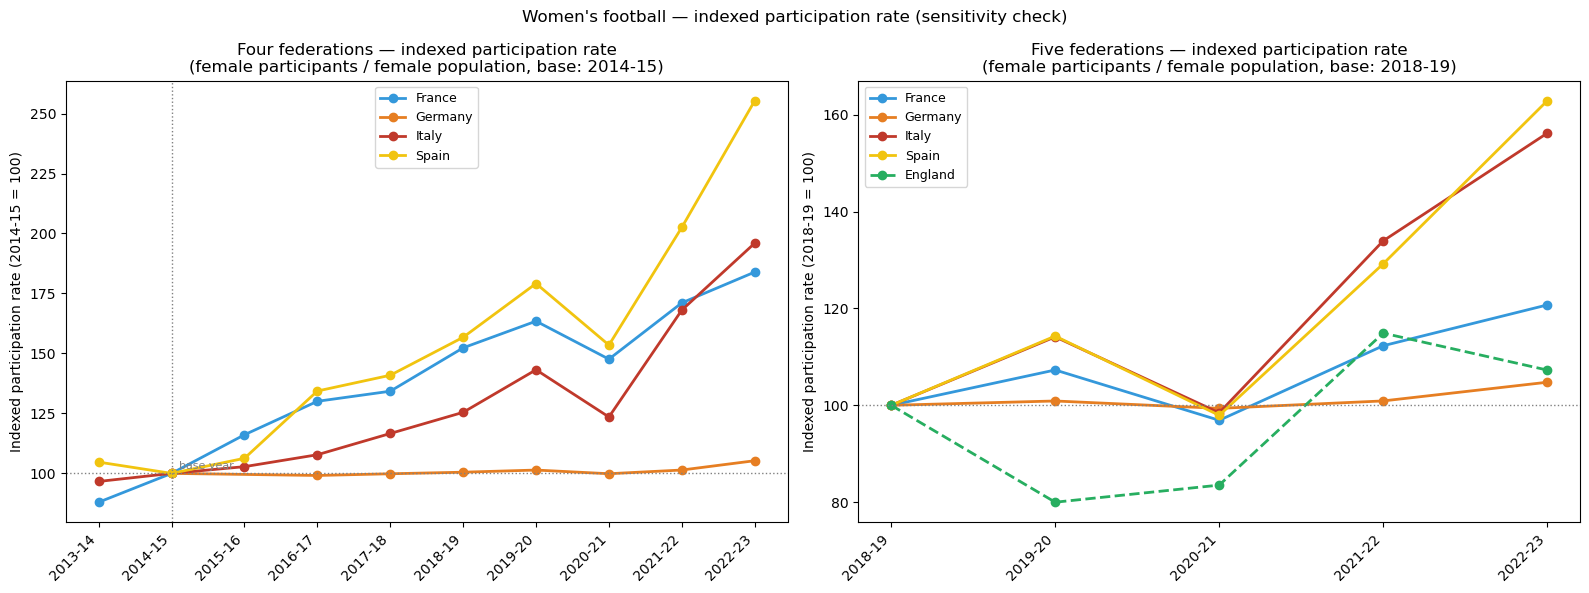


Actual participation rates (% of female population):

Tier 1:
country  France  Germany  Italy  Spain
season                                
2013-14   0.307      NaN  0.070  0.133
2014-15   0.349    2.640  0.072  0.127
2015-16   0.405      NaN  0.074  0.135
2016-17   0.453    2.617  0.078  0.170
2017-18   0.468    2.635  0.084  0.179
2018-19   0.531    2.653  0.090  0.199
2019-20   0.570    2.676  0.103  0.227
2020-21   0.515    2.636  0.089  0.195
2021-22   0.596    2.677  0.121  0.257
2022-23   0.641    2.779  0.141  0.324

Tier 2:
country  England  France  Germany  Italy  Spain
season                                         
2018-19    0.621   0.531    2.653  0.090  0.199
2019-20    0.497   0.570    2.676  0.103  0.227
2020-21    0.518   0.515    2.636  0.089  0.195
2021-22    0.713   0.596    2.677  0.121  0.257
2022-23    0.666   0.641    2.779  0.141  0.324


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Tier 1 rate index, base 2014-15 ---
ax = axes[0]
tier1_rate_seasons = sorted(tier1_rate["season"].unique())
x_map_r1 = {s: i for i, s in enumerate(tier1_rate_seasons)}

for country in tier1_countries:
    df = tier1_rate[tier1_rate["country"] == country].sort_values("season")
    x = [x_map_r1[s] for s in df["season"]]
    ax.plot(x, df["rate_index"].values, marker="o", linewidth=2,
            color=country_colors[country], label=country)

ax.axhline(100, color="grey", linestyle=":", linewidth=1)
ax.axvline(x_map_r1["2014-15"], color="grey", linestyle=":", linewidth=1)
ax.text(x_map_r1["2014-15"] + 0.1, 102, "base year", fontsize=8, color="grey")
ax.set_xticks(range(len(tier1_rate_seasons)))
ax.set_xticklabels(tier1_rate_seasons, rotation=45, ha="right")
ax.set_ylabel("Indexed participation rate (2014-15 = 100)")
ax.set_title("Four federations — indexed participation rate\n(female participants / female population, base: 2014-15)")
ax.legend(fontsize=9)

# --- Right: Tier 2 rate index, base 2018-19 ---
ax = axes[1]
tier2_rate_seasons = sorted(tier2_rate["season"].unique())
x_map_r2 = {s: i for i, s in enumerate(tier2_rate_seasons)}

for country in ["France", "Germany", "Italy", "Spain", "England"]:
    df = tier2_rate[tier2_rate["country"] == country].sort_values("season")
    x = [x_map_r2[s] for s in df["season"]]
    ax.plot(x, df["rate_index"].values, marker="o", linewidth=2,
            color=country_colors[country], label=country,
            linestyle="--" if country == "England" else "-")

ax.axhline(100, color="grey", linestyle=":", linewidth=1)
ax.set_xticks(range(len(tier2_rate_seasons)))
ax.set_xticklabels(tier2_rate_seasons, rotation=45, ha="right")
ax.set_ylabel("Indexed participation rate (2018-19 = 100)")
ax.set_title("Five federations — indexed participation rate\n(female participants / female population, base: 2018-19)")
ax.legend(fontsize=9)

plt.suptitle("Women's football — indexed participation rate (sensitivity check)", fontsize=12)
plt.tight_layout()
plt.show()

# Print actual rates for reference
print("\nActual participation rates (% of female population):")
print("\nTier 1:")
print(tier1_rate.pivot(index="season", columns="country", values="rate_pct").round(3).to_string())
print("\nTier 2:")
print(tier2_rate.pivot(index="season", columns="country", values="rate_pct").round(3).to_string())


## Does population normalisation change the story?

Short answer: partly and in a revealing way.

When we divide each country's registered female players by its female population, we are asking a different question: not "how many more women play football?" but "what share of the female population plays football?" The two questions can give different answers when countries are growing or shrinking at different rates.

**Actual participation rates in 2022–23** (female registrations / female population):

| Country | Rate (%) | Change since 2014–15 |
|---------|----------|----------------------|
| Germany | 2.78 | +0.44 pp |
| France | 0.64 | +0.28 pp |
| England | 0.67 | +0.24 pp |
| Spain | 0.32 | +0.20 pp |
| Italy | 0.14 | +0.07 pp |

Germany remains an outlier with nearly four times the penetration rate of France or England, and twenty times Italy's but this is also part due to the Mitglieder methodology, which counts all club members, not registered players alone.

The indexed chart (base 100 in 2014-15) amplifies Spain and Italy's trajectories slightly compared with the absolute-count index. The reason is demographic: both countries have stagnant or slowly declining female populations, so the same absolute increase in registrations translates into a proportionally larger rise in the rate. Spain reaches roughly 255 on the rate index (vs. 267 on the absolute index), and Italy reaches roughly 197 (vs. 191). The directions are identical; the magnitude differs only modestly.

## Appendix A - Major international competition finals

### FIFA Women's World Cup finals

| Year | Winner | Runner-up | Venue | Attendance |
|------|--------|-----------|-------|------------|
| 1991 | United States | Norway | Tianhe Stadium, Guangzhou, China | 63,000 |
| 1995 | Norway | Germany | Råsunda Stadium, Stockholm, Sweden | 17,158 |
| 1999 | United States | China | Rose Bowl, Pasadena, USA | 90,185 |
| 2003 | Germany | Sweden | Home Depot Center, Carson, USA | 26,137 |
| 2007 | Germany | Brazil | Hongkou Football Stadium, Shanghai, China | 31,000 |
| 2011 | Japan | United States | Commerzbank-Arena, Frankfurt, Germany | 48,817 |
| 2015 | United States | Japan | BC Place, Vancouver, Canada | 53,341 |
| 2019 | United States | Netherlands | Parc Olympique Lyonnais, Décines-Charpieu, France | 57,900 |
| 2023 | Spain | England | Stadium Australia, Sydney, Australia | 75,784 |

### UEFA European Championship finals (Women)

| Year | Winner | Runner-up | Venue | Attendance |
|------|--------|-----------|-------|------------|
| 1991 | Germany | Norway | Aalborg Stadium, Aalborg, Denmark | 6,000 |
| 1993 | Norway | Italy | Stadio Dino Manuzzi, Cesena, Italy | 7,000 |
| 1995 | Germany | Sweden | Fritz-Walter-Stadion, Kaiserslautern, Germany | 8,500 |
| 1997 | Germany | Italy | Ullevaal Stadion, Oslo, Norway | 2,221 |
| 2001 | Germany | Sweden | Donaustadion, Ulm, Germany | 18,000 |
| 2005 | Germany | Norway | Ewood Park, Blackburn, England | 21,105 |
| 2009 | Germany | England | Olympic Stadium, Helsinki, Finland | 15,877 |
| 2013 | Germany | Norway | Friends Arena, Solna, Sweden | 41,301 |
| 2017 | Netherlands | Denmark | De Grolsch Veste, Enschede, Netherlands | 28,182 |
| 2022 | England | Germany | Wembley Stadium, London, England | 87,192 |
| 2025 | England | Spain | St. Jakob-Park, Basel, Switzerland | 34,203 |


### FIFA Men's World Cup finals

| Year | Winner | Runner-up | Venue | Attendance |
|------|--------|-----------|-------|------------|
| 1990 | West Germany | Argentina | Stadio Olimpico, Rome, Italy | 73,603 |
| 1994 | Brazil | Italy | Rose Bowl, Pasadena, USA | 94,194 |
| 1998 | France | Brazil | Stade de France, Saint-Denis, France | 80,000 |
| 2002 | Brazil | Germany | International Stadium, Yokohama, Japan | 69,029 |
| 2006 | Italy | France | Olympiastadion, Berlin, Germany | 69,000 |
| 2010 | Spain | Netherlands | Soccer City, Johannesburg, South Africa | 84,490 |
| 2014 | Germany | Argentina | Maracanã Stadium, Rio de Janeiro, Brazil | 74,738 |
| 2018 | France | Croatia | Luzhniki Stadium, Moscow, Russia | 78,011 |
| 2022 | Argentina | France | Lusail Stadium, Lusail, Qatar | 88,966 |

### UEFA European Championship finals (Men)

| Year | Winner | Runner-up | Venue | Attendance |
|------|--------|-----------|-------|------------|
| 1992 | Denmark | Germany | Ullevi, Gothenburg, Sweden | 37,800 |
| 1996 | Germany | Czech Republic | Wembley Stadium, London, England | 73,611 |
| 2000 | France | Italy | Stadion Feijenoord, Rotterdam, Netherlands | 48,200 |
| 2004 | Greece | Portugal | Estádio da Luz, Lisbon, Portugal | 62,865 |
| 2008 | Spain | Germany | Ernst-Happel-Stadion, Vienna, Austria | 51,428 |
| 2012 | Spain | Italy | Olimpiyskiy National Sports Complex, Kyiv, Ukraine | 63,170 |
| 2016 | Portugal | France | Stade de France, Saint-Denis, France | 75,868 |
| 2020 | Italy | England | Wembley Stadium, London, England | 67,173 |
| 2024 | Spain | England | Olympiastadion, Berlin, Germany | 65,600 |



## Appendix B: Slide exports

This section regenerates all chart images used in the RevealJS presentation at `slides/top5_participation_slides.qmd`. Run the full notebook first, then run all cells in this appendix in order.

Output directory: `slides/img/`

In [36]:
# EXPORT: germany_gender_trend.png 
from pathlib import Path
import matplotlib.pyplot as plt

SLIDE_IMG_DIR = Path("slides/img")
SLIDE_IMG_DIR.mkdir(parents=True, exist_ok=True)

# rebuild Germany variables (x_map may have been overwritten by later sections)
COVID_YEAR = 2021
_dfb_total = (
    df_dfb
    .groupby(["season", "gender"])["registered_players"]
    .sum()
    .reset_index()
)
_years    = sorted(_dfb_total["season"].unique())
_x_map    = {y: i for i, y in enumerate(_years)}
_df_male   = _dfb_total[_dfb_total["gender"] == "male"].sort_values("season")
_df_female = _dfb_total[_dfb_total["gender"] == "female"].sort_values("season")

fig, ax1 = plt.subplots(figsize=(13, 6))
ax2 = ax1.twinx()

color_male   = "#2166ac"
color_female = "#d6604d"

x_male   = [_x_map[y] for y in _df_male["season"]]
x_female = [_x_map[y] for y in _df_female["season"]]

ax1.plot(x_male,   _df_male["registered_players"].values,
         color=color_male,   marker="o", linewidth=2.5,
         markersize=7, label="Maschi (asse sx)")
ax2.plot(x_female, _df_female["registered_players"].values,
         color=color_female, marker="s", linewidth=2.5,
         markersize=7, label="Femmine (asse dx)")

covid_x = _x_map[COVID_YEAR]
ax1.axvspan(covid_x - 0.5, covid_x + 0.5,
            color="lightcoral", alpha=0.25, label="COVID (2021)")

ax1.set_ylabel("Mitglieder maschi",  color=color_male,   fontsize=14)
ax2.set_ylabel("Mitglieder femmine", color=color_female, fontsize=14)
ax1.tick_params(axis="y", labelcolor=color_male,   labelsize=12)
ax2.tick_params(axis="y", labelcolor=color_female, labelsize=12)
ax1.set_xlabel("Anno", fontsize=13)
ax1.set_xticks(range(len(_years)))
ax1.set_xticklabels(_years, rotation=45, fontsize=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc="upper left", fontsize=12, framealpha=0.9)

ax1.yaxis.grid(True, color="#dddddd", linewidth=0.8)
ax2.yaxis.grid(False)
ax1.set_facecolor("white")
fig.patch.set_facecolor("white")

ax1.set_title("Germania (DFB) - Mitglieder per genere, 2015-2025",
              fontsize=15, pad=14)

plt.tight_layout()
plt.savefig(SLIDE_IMG_DIR / "germany_gender_trend.png",
            dpi=150, bbox_inches="tight")
plt.close()
print("Saved: germany_gender_trend.png")

Saved: germany_gender_trend.png


In [38]:
# EXPORT: germany_female_segmented.png 
from pathlib import Path
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

SLIDE_IMG_DIR = Path("slides/img")

PRE_COVID_DFB  = [2015, 2017, 2018, 2019, 2020]
POST_COVID_DFB = [2022, 2023, 2024, 2025]

_dfb_total = (
    df_dfb
    .groupby(["season", "gender"])["registered_players"]
    .sum()
    .reset_index()
)

color_female = "#d6604d"
gender = "female"

df_g = _dfb_total[_dfb_total["gender"] == gender].sort_values("season")
df_g = df_g.set_index("season")

pre  = df_g.loc[PRE_COVID_DFB,  "registered_players"]
post = df_g.loc[POST_COVID_DFB, "registered_players"]

x_pre  = np.arange(len(pre))
x_post = np.arange(len(pre) + 1, len(pre) + 1 + len(post))

slope_pre,  intercept_pre,  *_ = stats.linregress(x_pre,  pre.values)
slope_post, intercept_post, *_ = stats.linregress(x_post, post.values)

all_years = PRE_COVID_DFB + [2021] + POST_COVID_DFB
x_all     = list(range(len(all_years)))
x_map_g   = {y: i for i, y in zip(x_all, all_years)}

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot([x_map_g[y] for y in PRE_COVID_DFB],
        pre.values, color=color_female, marker="o",
        linewidth=2.5, markersize=8, label="Mitglieder femmine")
ax.plot([x_map_g[y] for y in POST_COVID_DFB],
        post.values, color=color_female, marker="o",
        linewidth=2.5, markersize=8)

ax.plot(x_pre,  intercept_pre  + slope_pre  * x_pre,
        color=color_female, linestyle="--", linewidth=1.8,
        label=f"Tendenza pre-COVID: {slope_pre:+,.0f}/anno")
ax.plot(x_post, intercept_post + slope_post * x_post,
        color=color_female, linestyle=":",  linewidth=1.8,
        label=f"Tendenza post-COVID: {slope_post:+,.0f}/anno")

covid_x = x_map_g[2021]
ax.axvspan(covid_x - 0.5, covid_x + 0.5,
           color="lightcoral", alpha=0.25, label="COVID (2021)")
ax.plot(covid_x, df_g.loc[2021, "registered_players"],
        color="lightcoral", marker="x", markersize=11,
        markeredgewidth=2, zorder=5)

ax.set_xticks(x_all)
ax.set_xticklabels(all_years, rotation=45, fontsize=12)
ax.set_ylabel("Mitglieder femmine", fontsize=14)
ax.set_xlabel("Anno", fontsize=13)
ax.tick_params(axis="y", labelsize=12)
ax.legend(fontsize=12, framealpha=0.9)
ax.yaxis.grid(True, color="#dddddd", linewidth=0.8)
ax.set_facecolor("white")
fig.patch.set_facecolor("white")

ax.set_title("Germania (DFB) - Tendenza femminile: prima e dopo il COVID",
             fontsize=15, pad=14)

plt.tight_layout()
plt.savefig(SLIDE_IMG_DIR / "germany_female_segmented.png",
            dpi=150, bbox_inches="tight")
plt.close()
print("Saved: germany_female_segmented.png")

Saved: germany_female_segmented.png


In [39]:
# EXPORT: england_gender_trend.png 
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

SLIDE_IMG_DIR = Path("slides/img")

# rebuild England variables
_eng_adult = eng_adult.copy()
_eng_seasons = sorted(_eng_adult["season"].unique())
_x = list(range(len(_eng_seasons)))

_female = (_eng_adult[_eng_adult["gender"] == "female"]
           .set_index("season").reindex(_eng_seasons)["population_estimate"])
_male   = (_eng_adult[_eng_adult["gender"] == "male"]
           .set_index("season").reindex(_eng_seasons)["population_estimate"])

color_female = "#c0392b"
color_male   = "#2980b9"

fig, ax1 = plt.subplots(figsize=(13, 6))
ax2 = ax1.twinx()

ax1.plot(_x, _female.values, color=color_female, marker="o",
         linewidth=2.5, markersize=8, label="Femmine (asse sx)")
ax2.plot(_x, _male.values,   color=color_male,   marker="s",
         linewidth=2.5, markersize=8, linestyle="--", label="Maschi (asse dx)")

# COVID shading: seasons index 1 and 2 (2019-20, 2020-21)
ax1.axvspan(0.5, 2.5, alpha=0.12, color="grey", label="COVID (2019-21)")
ax1.text(1.5, _female.max() * 0.58, "COVID", ha="center",
         fontsize=12, color="grey", style="italic")

ax1.set_xticks(_x)
ax1.set_xticklabels(_eng_seasons, rotation=45, ha="right", fontsize=12)
ax1.set_ylabel("Partecipanti stimate — femmine", color=color_female, fontsize=14)
ax2.set_ylabel("Partecipanti stimate — maschi",  color=color_male,   fontsize=14)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax1.tick_params(axis="y", colors=color_female, labelsize=12)
ax2.tick_params(axis="y", colors=color_male,   labelsize=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc="upper left", fontsize=12, framealpha=0.9)

ax1.yaxis.grid(True, color="#dddddd", linewidth=0.8)
ax2.yaxis.grid(False)
ax1.set_facecolor("white")
fig.patch.set_facecolor("white")

ax1.set_title(
    "Inghilterra — partecipanti per genere\n"
    "(Sport England Active Lives Survey, 2018-2025)",
    fontsize=15, pad=14
)

# survey data disclaimer
fig.text(0.99, 0.01,
         "Fonte: Sport England Active Lives Survey — dati da indagine campionaria, non registro federale",
         ha="right", va="bottom", fontsize=9, color="grey", style="italic")

plt.tight_layout()
plt.savefig(SLIDE_IMG_DIR / "england_gender_trend.png",
            dpi=150, bbox_inches="tight")
plt.close()
print("Saved: england_gender_trend.png")

Saved: england_gender_trend.png


In [40]:
#  EXPORT: england_female_segmented.png 
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

SLIDE_IMG_DIR = Path("slides/img")

color_obs  = "#c0392b"
color_post = "#8e44ad"

_eng_seasons_list = sorted(eng_adult["season"].unique())
_gs = (eng_adult[eng_adult["gender"] == "female"]
       .set_index("season")
       .reindex(_eng_seasons_list)
       .reset_index())
_gs["t"] = range(len(_gs))

_post = _gs[_gs["season"].isin(["2021-22", "2022-23", "2023-24", "2024-25"])]
_slope_post, _intercept_post, _r_post, *_ = stats.linregress(
    _post["t"], _post["population_estimate"]
)
_x_post = np.linspace(_post["t"].min(), _post["t"].max(), 100)

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(_gs["t"], _gs["population_estimate"],
        color=color_obs, marker="o", linewidth=2.5,
        markersize=8, label="Partecipanti stimate")
ax.plot(_x_post, _intercept_post + _slope_post * _x_post,
        color=color_post, linewidth=2, linestyle="--",
        label=f"Tendenza post-COVID: {_slope_post:+,.0f}/stagione")

# COVID shading
ax.axvspan(0.5, 2.5, alpha=0.12, color="grey", label="COVID (2019-21)")
ax.text(1.5, _gs["population_estimate"].max() * 0.58,
        "COVID", ha="center", fontsize=12, color="grey", style="italic")

# annotate key seasons directly on chart
_annotations = {
    "2021-22": (244900, "244.900\n(recupero)"),
    "2023-24": (309500, "309.500\n(picco post-Europei)"),
    "2024-25": (296300, "296.300\n(consolidamento)"),
}
for season, (val, label) in _annotations.items():
    t_idx = _gs[_gs["season"] == season]["t"].values[0]
    ax.annotate(label,
                xy=(t_idx, val),
                xytext=(t_idx + 0.15, val + 12000),
                fontsize=10, color=color_obs,
                arrowprops=dict(arrowstyle="-", color=color_obs, lw=1))

ax.set_xticks(_gs["t"])
ax.set_xticklabels(_eng_seasons_list, rotation=45, ha="right", fontsize=12)
ax.set_ylabel("Partecipanti stimate — femmine", fontsize=14)
ax.tick_params(axis="y", labelsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.legend(fontsize=12, framealpha=0.9)
ax.yaxis.grid(True, color="#dddddd", linewidth=0.8)
ax.set_facecolor("white")
fig.patch.set_facecolor("white")

ax.set_title(
    "Inghilterra — partecipazione femminile: effetto Euro 2022",
    fontsize=15, pad=14
)
fig.text(0.99, 0.01,
         "Fonte: Sport England Active Lives Survey — dati da indagine campionaria",
         ha="right", va="bottom", fontsize=9, color="grey", style="italic")

plt.tight_layout()
plt.savefig(SLIDE_IMG_DIR / "england_female_segmented.png",
            dpi=150, bbox_inches="tight")
plt.close()
print("Saved: england_female_segmented.png")

Saved: england_female_segmented.png


In [41]:
# EXPORT: france_gender_trend.png 
from pathlib import Path
import matplotlib.pyplot as plt

SLIDE_IMG_DIR = Path("slides/img")

_df_totals = df_french_data[df_french_data["age_group"] == "total"].copy()
COVID_SEASON = "2020-21"
_seasons   = sorted(_df_totals["season"].unique())
_covid_idx = _seasons.index(COVID_SEASON)
_x_pos     = range(len(_seasons))

_df_male   = _df_totals[_df_totals["gender"] == "male"].sort_values("season")
_df_female = _df_totals[_df_totals["gender"] == "female"].sort_values("season")

color_male   = "#2166ac"
color_female = "#d6604d"

fig, ax1 = plt.subplots(figsize=(13, 6))
ax2 = ax1.twinx()

ax1.plot(list(_x_pos), _df_male["registered_players"].values,
         color=color_male,   marker="o", linewidth=2.5,
         markersize=8, label="Maschi (asse sx)")
ax2.plot(list(_x_pos), _df_female["registered_players"].values,
         color=color_female, marker="s", linewidth=2.5,
         markersize=8, label="Femmine (asse dx)")

ax1.axvspan(_covid_idx - 0.5, _covid_idx + 0.5,
            color="lightcoral", alpha=0.2, label="COVID (2020-21)")

ax1.set_ylabel("Licenze maschili", color=color_male,   fontsize=14)
ax2.set_ylabel("Licenze femminili", color=color_female, fontsize=14)
ax1.tick_params(axis="y", labelcolor=color_male,   labelsize=12)
ax2.tick_params(axis="y", labelcolor=color_female, labelsize=12)
ax1.set_xlabel("Stagione", fontsize=13)
ax1.set_xticks(list(_x_pos))
ax1.set_xticklabels(_seasons, rotation=45, fontsize=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc="upper left", fontsize=12, framealpha=0.9)

ax1.yaxis.grid(True, color="#dddddd", linewidth=0.8)
ax2.yaxis.grid(False)
ax1.set_facecolor("white")
fig.patch.set_facecolor("white")

ax1.set_title("Francia (FFF) - Licenze per genere, 2014-2023",
              fontsize=15, pad=14)

plt.tight_layout()
plt.savefig(SLIDE_IMG_DIR / "france_gender_trend.png",
            dpi=150, bbox_inches="tight")
plt.close()
print("Saved: france_gender_trend.png")

Saved: france_gender_trend.png


In [43]:
# EXPORT: france_female_age.png 
from pathlib import Path
import matplotlib.pyplot as plt

SLIDE_IMG_DIR = Path("slides/img")

_YOUTH_BANDS = ["1 à 4 ans", "5 à 9 ans", "10 à 14 ans", "15 à 19 ans"]

def _assign_group(band):
    if any(band.startswith(b[:4]) for b in _YOUTH_BANDS):
        return "Giovani (under 20)"
    return "Adulte (20+)"

_df_bands = df_french_data[
    (df_french_data["age_group"] == "native_band") &
    (df_french_data["gender"] == "female")
].copy()
_df_bands["broad_group"] = _df_bands["age_threshold"].apply(_assign_group)

_df_broad = (_df_bands.groupby(["season", "broad_group"])["registered_players"]
             .sum().reset_index())
_df_broad["total_season"] = (_df_broad.groupby("season")["registered_players"]
                              .transform("sum"))
_df_broad["share_pct"] = (_df_broad["registered_players"]
                           / _df_broad["total_season"] * 100)

_seasons_age = sorted(_df_broad["season"].unique())
_x = range(len(_seasons_age))

color_youth = "#e08040"
color_adult = "#6a3d9a"

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for group, color in [("Giovani (under 20)", color_youth),
                     ("Adulte (20+)",        color_adult)]:
    _sub = _df_broad[_df_broad["broad_group"] == group].sort_values("season")
    axes[0].plot(_x, _sub["registered_players"].values,
                 marker="o", linewidth=2.5, markersize=8,
                 color=color, label=group)
    axes[1].plot(_x, _sub["share_pct"].values,
                 marker="o", linewidth=2.5, markersize=8,
                 color=color, label=group)

for ax, ylabel, title in [
    (axes[0], "Licenze femminili",              "Valori assoluti"),
    (axes[1], "Quota sul totale femminile (%)", "Quota percentuale"),
]:
    ax.set_xticks(list(_x))
    ax.set_xticklabels(_seasons_age, rotation=45, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=11, framealpha=0.9)
    ax.yaxis.grid(True, color="#dddddd", linewidth=0.8)
    ax.set_facecolor("white")
    ax.tick_params(axis="y", labelsize=11)

fig.patch.set_facecolor("white")
fig.suptitle("Francia (FFF) - Licenze femminili per fascia d'età",
             fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(SLIDE_IMG_DIR / "france_female_age.png",
            dpi=150, bbox_inches="tight")
plt.close()
print("Saved: france_female_age.png")

Saved: france_female_age.png


In [45]:
# ── EXPORT: spain_female_age.png ─────────────────────────────────────────────
from pathlib import Path
import matplotlib.pyplot as plt

SLIDE_IMG_DIR = Path("slides/img")

_YOUTH_LABELS = ["juvenil","cadete","infantil","alevin",
                 "benjamin","prebenjamin","debutante","base"]

def _assign_broad(label):
    return "Giovani" if label in _YOUTH_LABELS else "Adulte"

_df_age_fb_f = df_rfef_age[
    (df_rfef_age["sport"]  == "football") &
    (df_rfef_age["gender"] == "female")
].copy()
_df_age_fb_f["broad_group"] = _df_age_fb_f["age_label"].apply(_assign_broad)

_df_broad_f = (
    _df_age_fb_f.groupby(["season", "broad_group"])["registered_players"]
    .sum().unstack(fill_value=0).reset_index()
)
_df_broad_f["total"]       = _df_broad_f["Adulte"] + _df_broad_f["Giovani"]
_df_broad_f["share_adulte"]  = _df_broad_f["Adulte"]  / _df_broad_f["total"] * 100
_df_broad_f["share_giovani"] = _df_broad_f["Giovani"] / _df_broad_f["total"] * 100
_df_broad_f = _df_broad_f.sort_values("season")

_seasons_age = _df_broad_f["season"].tolist()
_x_pos       = range(len(_seasons_age))
_covid_idx   = list(_seasons_age).index("2020-21")

colors     = {"Giovani": "#e08040", "Adulte": "#6a3d9a"}
labels_map = {"Giovani": "Giovani (juvenil e inferiori)",
              "Adulte":  "Adulte (profesional + aficionado)"}
share_col  = {"Giovani": "share_giovani", "Adulte": "share_adulte"}

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for group in ["Giovani", "Adulte"]:
    axes[0].plot(list(_x_pos), _df_broad_f[group].values,
                 marker="o", linewidth=2.5, markersize=8,
                 color=colors[group], label=labels_map[group])
    axes[1].plot(list(_x_pos), _df_broad_f[share_col[group]].values,
                 marker="o", linewidth=2.5, markersize=8,
                 color=colors[group], label=labels_map[group])

for ax in axes:
    ax.axvspan(_covid_idx - 0.5, _covid_idx + 0.5,
               color="lightcoral", alpha=0.2, label="COVID (2020-21)")
    ax.set_xticks(list(_x_pos))
    ax.set_xticklabels(_seasons_age, rotation=45, fontsize=11)
    ax.legend(fontsize=11, framealpha=0.9)
    ax.yaxis.grid(True, color="#dddddd", linewidth=0.8)
    ax.set_facecolor("white")
    ax.tick_params(axis="y", labelsize=11)

axes[0].set_title("Valori assoluti", fontsize=13)
axes[0].set_ylabel("Licenze femminili", fontsize=13)
axes[1].set_title("Quota percentuale", fontsize=13)
axes[1].set_ylabel("Quota sul totale femminile (%)", fontsize=13)

fig.patch.set_facecolor("white")
fig.suptitle("Spagna (RFEF) - Licenze femminili per fascia d'età",
             fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(SLIDE_IMG_DIR / "spain_female_age.png",
            dpi=150, bbox_inches="tight")
plt.close()
print("Saved: spain_female_age.png")

Saved: spain_female_age.png


In [46]:
# EXPORT: italy_female_activity.png 
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

SLIDE_IMG_DIR = Path("slides/img")

_seasons     = sorted(figc["season"].unique())
_act_cats    = ["dilettantistica", "sgs"]
_colors_act  = {"dilettantistica": "#e67e22", "sgs": "#27ae60"}
_labels_act  = {"dilettantistica": "Dilettantistica (amatoriale adulta)",
                "sgs":             "SGS (settore giovanile)"}

_gdf = figc[(figc["gender"] == "female") &
            (figc["age_group"].isin(_act_cats))].copy()
_pivot = (_gdf.pivot(index="season", columns="age_group",
                     values="registered_players")
          .reindex(_seasons))

_x = np.arange(len(_seasons))

fig, ax = plt.subplots(figsize=(13, 6))

for cat in _act_cats:
    ax.plot(_x, _pivot[cat].values,
            marker="o", linewidth=2.5, markersize=8,
            color=_colors_act[cat], label=_labels_act[cat])

ax.set_xticks(_x)
ax.set_xticklabels(_seasons, rotation=45, ha="right", fontsize=11)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.set_ylabel("Tesserate femminili", fontsize=14)
ax.legend(fontsize=12, framealpha=0.9)
ax.yaxis.grid(True, color="#dddddd", linewidth=0.8)
ax.set_facecolor("white")
fig.patch.set_facecolor("white")
ax.tick_params(axis="y", labelsize=12)

# mark the crossover point
_cross_season = "2018-19"
if _cross_season in _seasons:
    _cx = list(_seasons).index(_cross_season)
    ax.axvline(_cx, color="#888888", linestyle=":", linewidth=1.5)
    ax.text(_cx + 0.1,
            _pivot["sgs"].max() * 0.55,
            "SGS supera\nla dilettantistica",
            fontsize=10, color="#888888")

ax.set_title(
    "Italia (FIGC) - Tesserate femminili: SGS vs dilettantistica",
    fontsize=15, pad=14
)

plt.tight_layout()
plt.savefig(SLIDE_IMG_DIR / "italy_female_activity.png",
            dpi=150, bbox_inches="tight")
plt.close()
print("Saved: italy_female_activity.png")

Saved: italy_female_activity.png


In [47]:
# EXPORT: cross_country_index_tier1.png 
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

SLIDE_IMG_DIR = Path("slides/img")

_country_colors = {
    "France":  "#3498db",
    "Germany": "#e67e22",
    "Italy":   "#c0392b",
    "Spain":   "#f1c40f",
}
_tier1_countries = ["France", "Germany", "Italy", "Spain"]
_tier1_seasons   = sorted(tier1["season"].unique())
_x_map           = {s: i for i, s in enumerate(_tier1_seasons)}
_base_x          = _x_map["2014-15"]

# Italian country name labels for the legend
_labels_it = {
    "France":  "Francia",
    "Germany": "Germania",
    "Italy":   "Italia",
    "Spain":   "Spagna",
}

fig, ax = plt.subplots(figsize=(13, 6))

for country in _tier1_countries:
    _df = tier1[tier1["country"] == country].sort_values("season")
    _x  = [_x_map[s] for s in _df["season"]]
    ax.plot(_x, _df["index"].values,
            marker="o", linewidth=2.5, markersize=8,
            color=_country_colors[country],
            label=_labels_it[country])

ax.axvline(_base_x, color="grey", linestyle=":", linewidth=1.2)
ax.text(_base_x + 0.1, 72, "anno base\n(= 100)",
        fontsize=10, color="grey", style="italic")
ax.axhline(100, color="grey", linestyle=":", linewidth=1.2)

ax.set_xticks(range(len(_tier1_seasons)))
ax.set_xticklabels(_tier1_seasons, rotation=45, ha="right", fontsize=11)
ax.set_ylabel("Indice (2014-15 = 100)", fontsize=14)
ax.tick_params(axis="y", labelsize=12)
ax.legend(fontsize=13, framealpha=0.9)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"{v:.0f}"))
ax.yaxis.grid(True, color="#dddddd", linewidth=0.8)
ax.set_facecolor("white")
fig.patch.set_facecolor("white")

ax.set_title(
    "Partecipazione femminile — quattro federazioni\n"
    "Indice di crescita (base 2014-15 = 100)",
    fontsize=15, pad=14
)

plt.tight_layout()
plt.savefig(SLIDE_IMG_DIR / "cross_country_index_tier1.png",
            dpi=150, bbox_inches="tight")
plt.close()
print("Saved: cross_country_index_tier1.png")

Saved: cross_country_index_tier1.png


In [48]:
# EXPORT: cross_country_index_tier2.png 
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

SLIDE_IMG_DIR = Path("slides/img")

_country_colors = {
    "France":  "#3498db",
    "Germany": "#e67e22",
    "Italy":   "#c0392b",
    "Spain":   "#f1c40f",
    "England": "#27ae60",
}
_labels_it = {
    "France":  "Francia",
    "Germany": "Germania",
    "Italy":   "Italia",
    "Spain":   "Spagna",
    "England": "Inghilterra (indagine)",
}

_tier2_seasons = sorted(tier2["season"].unique())
_x_map2        = {s: i for i, s in enumerate(_tier2_seasons)}

fig, ax = plt.subplots(figsize=(13, 6))

for country in ["France", "Germany", "Italy", "Spain", "England"]:
    _df = tier2[tier2["country"] == country].sort_values("season")
    _x  = [_x_map2[s] for s in _df["season"]]
    ax.plot(_x, _df["index"].values,
            marker="o", linewidth=2.5, markersize=8,
            color=_country_colors[country],
            linestyle="--" if country == "England" else "-",
            label=_labels_it[country])

ax.axhline(100, color="grey", linestyle=":", linewidth=1.2)
ax.text(0.08, 101.5, "anno base (= 100)",
        fontsize=10, color="grey", style="italic", transform=ax.get_yaxis_transform())

# annotate COVID band
_covid_x = _x_map2.get("2020-21")
if _covid_x is not None:
    ax.axvspan(_covid_x - 0.5, _covid_x + 0.5,
               color="lightcoral", alpha=0.15)
    ax.text(_covid_x, ax.get_ylim()[0] + 2 if ax.get_ylim()[0] > 0 else 72,
            "COVID", ha="center", fontsize=10,
            color="grey", style="italic")

ax.set_xticks(range(len(_tier2_seasons)))
ax.set_xticklabels(_tier2_seasons, rotation=45, ha="right", fontsize=11)
ax.set_ylabel("Indice (2018-19 = 100)", fontsize=14)
ax.tick_params(axis="y", labelsize=12)
ax.legend(fontsize=12, framealpha=0.9)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"{v:.0f}"))
ax.yaxis.grid(True, color="#dddddd", linewidth=0.8)
ax.set_facecolor("white")
fig.patch.set_facecolor("white")

ax.set_title(
    "Partecipazione femminile — cinque federazioni\n"
    "Indice di crescita (base 2018-19 = 100) · linea tratteggiata = dati da indagine",
    fontsize=14, pad=14
)

fig.text(0.99, 0.01,
         "Inghilterra: Sport England Active Lives Survey — non confrontabile in valore assoluto",
         ha="right", va="bottom", fontsize=9, color="grey", style="italic")

plt.tight_layout()
plt.savefig(SLIDE_IMG_DIR / "cross_country_index_tier2.png",
            dpi=150, bbox_inches="tight")
plt.close()
print("Saved: cross_country_index_tier2.png")

Saved: cross_country_index_tier2.png


In [49]:
# ── EXPORT: italy_gender_trend.png ───────────────────────────────────────────
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

SLIDE_IMG_DIR = Path("slides/img")

_figc_total = figc[(figc["age_group"] == "total") &
                   (figc["gender"].isin(["female", "male"]))].copy()
_seasons = sorted(figc["season"].unique())

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, gender, color_obs, color_pre, color_post, label, title_it in [
    (axes[0], "female", "#c0392b", "#e74c3c", "#8e44ad",
     "Female", "Femmine"),
    (axes[1], "male",   "#2980b9", "#3498db", "#16a085",
     "Male",   "Maschi"),
]:
    _gs = (_figc_total[_figc_total["gender"] == gender]
           .set_index("season").reindex(_seasons).reset_index())
    _gs["t"] = range(len(_gs))

    _pre  = _gs[_gs["t"] <= 5]
    _post = _gs[_gs["t"] >= 7]

    _slope_pre,  _int_pre,  *_ = stats.linregress(_pre["t"],
                                                    _pre["registered_players"])
    _slope_post, _int_post, *_ = stats.linregress(_post["t"],
                                                    _post["registered_players"])

    _x_pre  = np.linspace(_pre["t"].min(),  _pre["t"].max(),  100)
    _x_post = np.linspace(_post["t"].min(), _post["t"].max(), 100)

    ax.plot(_gs["t"], _gs["registered_players"],
            color=color_obs, marker="o", linewidth=2.5,
            markersize=8, label="Osservati")
    ax.plot(_x_pre,  _int_pre  + _slope_pre  * _x_pre,
            color=color_pre,  linewidth=1.8, linestyle="--",
            label=f"Pre-COVID ({_slope_pre:+,.0f}/stagione)")
    ax.plot(_x_post, _int_post + _slope_post * _x_post,
            color=color_post, linewidth=1.8, linestyle="--",
            label=f"Post-COVID ({_slope_post:+,.0f}/stagione)")

    ax.axvspan(5.5, 6.5, alpha=0.10, color="grey")
    ax.text(6, _gs["registered_players"].max() * 0.62,
            "COVID", ha="center", fontsize=11, color="grey", style="italic")

    ax.set_xticks(_gs["t"])
    ax.set_xticklabels(_seasons, rotation=45, ha="right", fontsize=10)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
    ax.set_ylabel(f"Tesserati — {title_it}", fontsize=13)
    ax.set_title(title_it, fontsize=14)
    ax.legend(fontsize=11, framealpha=0.9)
    ax.yaxis.grid(True, color="#dddddd", linewidth=0.8)
    ax.set_facecolor("white")
    ax.tick_params(axis="y", labelsize=11)

fig.patch.set_facecolor("white")
fig.suptitle("Italia (FIGC) - Tesserati per genere: tendenze pre e post COVID",
             fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(SLIDE_IMG_DIR / "italy_gender_trend.png",
            dpi=150, bbox_inches="tight")
plt.close()
print("Saved: italy_gender_trend.png")

Saved: italy_gender_trend.png


In [50]:
# ── EXPORT: spain_gender_trend.png ───────────────────────────────────────────
from pathlib import Path
import matplotlib.pyplot as plt

SLIDE_IMG_DIR = Path("slides/img")

_df_fb = df_rfef[(df_rfef["sport"] == "football") &
                 (df_rfef["gender"] != "total")].copy()
_df_fb_male   = _df_fb[_df_fb["gender"] == "male"].sort_values("season")
_df_fb_female = _df_fb[_df_fb["gender"] == "female"].sort_values("season")

_seasons   = sorted(_df_fb["season"].unique())
_x_pos     = range(len(_seasons))
_covid_idx = list(_seasons).index("2020-21")

color_male   = "#2166ac"
color_female = "#d6604d"

fig, ax1 = plt.subplots(figsize=(13, 6))
ax2 = ax1.twinx()

ax1.plot(list(_x_pos), _df_fb_male["registered_players"].values,
         color=color_male,   marker="o", linewidth=2.5,
         markersize=8, label="Maschi (asse sx)")
ax2.plot(list(_x_pos), _df_fb_female["registered_players"].values,
         color=color_female, marker="s", linewidth=2.5,
         markersize=8, label="Femmine (asse dx)")

ax1.axvspan(_covid_idx - 0.5, _covid_idx + 0.5,
            color="lightcoral", alpha=0.2, label="COVID (2020-21)")

ax1.set_ylabel("Licenze maschili",  color=color_male,   fontsize=14)
ax2.set_ylabel("Licenze femminili", color=color_female, fontsize=14)
ax1.tick_params(axis="y", labelcolor=color_male,   labelsize=12)
ax2.tick_params(axis="y", labelcolor=color_female, labelsize=12)
ax1.set_xlabel("Stagione", fontsize=13)
ax1.set_xticks(list(_x_pos))
ax1.set_xticklabels(_seasons, rotation=45, fontsize=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc="upper left", fontsize=12, framealpha=0.9)

ax1.yaxis.grid(True, color="#dddddd", linewidth=0.8)
ax2.yaxis.grid(False)
ax1.set_facecolor("white")
fig.patch.set_facecolor("white")

ax1.set_title("Spagna (RFEF) - Licenze per genere, 2013-2023\n(solo calcio outdoor)",
              fontsize=15, pad=14)

plt.tight_layout()
plt.savefig(SLIDE_IMG_DIR / "spain_gender_trend.png",
            dpi=150, bbox_inches="tight")
plt.close()
print("Saved: spain_gender_trend.png")

Saved: spain_gender_trend.png


In [52]:
# ── EXPORT: germany_both_segmented.png ───────────────────────────────────────
from pathlib import Path
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

SLIDE_IMG_DIR = Path("slides/img")

PRE_COVID_DFB  = [2015, 2017, 2018, 2019, 2020]
POST_COVID_DFB = [2022, 2023, 2024, 2025]

_dfb_total = (
    df_dfb
    .groupby(["season", "gender"])["registered_players"]
    .sum()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

for ax, gender, color, title_it in zip(
    axes,
    ["female", "male"],
    ["#d6604d", "#2166ac"],
    ["Femmine", "Maschi"]
):
    _df_g = _dfb_total[_dfb_total["gender"] == gender].sort_values("season")
    _df_g = _df_g.set_index("season")

    _pre  = _df_g.loc[PRE_COVID_DFB,  "registered_players"]
    _post = _df_g.loc[POST_COVID_DFB, "registered_players"]

    _x_pre  = np.arange(len(_pre))
    _x_post = np.arange(len(_pre) + 1, len(_pre) + 1 + len(_post))

    _slope_pre,  _int_pre,  *_ = stats.linregress(_x_pre,  _pre.values)
    _slope_post, _int_post, *_ = stats.linregress(_x_post, _post.values)

    _all_years = PRE_COVID_DFB + [2021] + POST_COVID_DFB
    _x_all     = list(range(len(_all_years)))
    _x_map_g   = {y: i for i, y in zip(_x_all, _all_years)}

    ax.plot([_x_map_g[y] for y in PRE_COVID_DFB],
            _pre.values, color=color, marker="o", linewidth=2.5, markersize=7)
    ax.plot([_x_map_g[y] for y in POST_COVID_DFB],
            _post.values, color=color, marker="o", linewidth=2.5, markersize=7)

    ax.plot(_x_pre,  _int_pre  + _slope_pre  * _x_pre,
            color=color, linestyle="--", linewidth=1.8,
            label=f"Pre-COVID: {_slope_pre:+,.0f}/anno")
    ax.plot(_x_post, _int_post + _slope_post * _x_post,
            color=color, linestyle=":",  linewidth=1.8,
            label=f"Post-COVID: {_slope_post:+,.0f}/anno")

    _covid_x = _x_map_g[2021]
    ax.axvspan(_covid_x - 0.5, _covid_x + 0.5,
               color="lightcoral", alpha=0.25, label="COVID (2021)")
    ax.plot(_covid_x, _df_g.loc[2021, "registered_players"],
            color="lightcoral", marker="x", markersize=10,
            markeredgewidth=2, zorder=5)

    ax.set_xticks(_x_all)
    ax.set_xticklabels(_all_years, rotation=45, fontsize=10)
    ax.set_title(title_it, fontsize=14)
    ax.set_ylabel("Mitglieder", fontsize=12)
    ax.legend(fontsize=10, framealpha=0.9)
    ax.yaxis.grid(True, color="#dddddd", linewidth=0.8)
    ax.set_facecolor("white")
    ax.tick_params(axis="y", labelsize=10)

fig.patch.set_facecolor("white")
fig.suptitle("Germania (DFB) — Tendenze per genere: prima e dopo il COVID",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(SLIDE_IMG_DIR / "germany_both_segmented.png",
            dpi=150, bbox_inches="tight")
plt.close()
print("Saved: germany_both_segmented.png")

Saved: germany_both_segmented.png
